# Macroeconomic Forecasting Project: Multivariate Analysis
---

<div align="center">
  <p><strong>BỘ GIÁO DỤC VÀ ĐÀO TẠO</strong></p>
  <p><strong>TRƯỜNG ĐẠI HỌC CÔNG NGHỆ KỸ THUẬT THÀNH PHỐ HỒ CHÍ MINH</strong></p>
  <p><strong>KHOA CÔNG NGHỆ THÔNG TIN</strong></p>
  <br>
  
  <h1><strong>PROJECT 1</strong></h1>
  <h2><strong>PHÂN TÍCH CÁC YẾU TỐ VĨ MÔ TÁC ĐỘNG ĐẾN LẠM PHÁT TẠI VIỆT NAM TỪ NĂM 1996 ĐẾN NĂM 2022 VÀ DỰ BÁO XU HƯỚNG BẰNG MÔ HÌNH CHUỖI THỜI GIAN</strong></h2>
  <br>
</div>

**MÔN HỌC:** PHÂN TÍCH DỮ LIỆU  
**LỚP:** DAAN436277_02  
**GVHD:** ThS. Trần Trọng Bình  

### THÀNH VIÊN NHÓM 02:

| STT | Họ và tên | Mã số sinh viên |
|:---:|:---|:---:|
| 1 | Đỗ Kiến Hưng | 23133030 |
| 2 | Trần Minh Khánh | 23133035 |
| 3 | Nguyễn Đặng Quốc Anh | 23133004 |
| 4 | Phạm Minh Quân | 23133060 |

<br>
<div align="right">
  <i>TPHCM, ngày 19 tháng 05 năm 2026</i>
</div>

---

> **THE ULTIMATE QUESTION**
>
> Nhóm tiến hành phân tích dự án nhằm đi tìm lời giải đáp cho vấn đề cốt lõi:
> *"Trong 3 thập kỷ qua, Lạm phát tại Việt Nam chủ yếu là do **'Bệnh tự miễn'** (Quán tính tự sinh ra do tâm lý kỳ vọng) hay do **'Tác nhân bên ngoài'** (Tỷ giá, Tín dụng, Tăng trưởng GDP)? Cần can thiệp vào đâu để kiểm soát nó?"*

## **PHASE 1: Data Cleaning & Preprocessing**

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import jarque_bera
from scipy.stats import probplot

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.seasonal import seasonal_decompose

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.var_model import VAR

import warnings
warnings.filterwarnings('ignore')

### Upload Dataset


In [ ]:
from google.colab import drive
df = pd.read_excel('/content/dataset_project1.xlsx')
display(df.head())

,years,cpi_growth_percent,cpi_index,gdp_delflator_percent,gdp_deflator_percent,gdp_growth_percent,unemployment_rate,domestic_credit_index,lending_interest_percent,officical_exchange_rate_percent,import_index,export_index
0,1996,5.675000,42.445125,24.092342,8.696767,9.340017,1.93,18.670036,20.100000,11032.583333,51.837259,40.868487
1,1997,3.209526,43.807412,25.681811,6.597405,8.152084,2.87,19.848841,14.416667,11683.333333,51.241777,43.102707
2,1998,7.266198,46.990546,27.951535,8.837864,5.764455,2.29,20.123863,14.400000,13268.000000,52.152945,44.848303
3,1999,4.117102,48.925195,29.554473,5.734703,4.773587,2.33,28.186587,12.700000,13943.166667,52.821161,49.966246
4,2000,-1.710337,48.088409,30.561934,3.408828,6.787316,2.26,35.259074,10.550000,14167.750000,57.495597,53.921497


### Data Overview


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   years                            29 non-null     int64  
 1   cpi_growth_percent               29 non-null     float64
 2   cpi_index                        29 non-null     float64
 3   gdp_delflator_percent            29 non-null     float64
 4   gdp_deflator_percent             29 non-null     float64
 5   gdp_growth_percent               29 non-null     float64
 6   unemployment_rate                29 non-null     float64
 7   domestic_credit_index            27 non-null     float64
 8   lending_interest_percent         28 non-null     float64
 9   officical_exchange_rate_percent  29 non-null     float64
 10  import_index                     29 non-null     float64
 11  export_index                     29 non-null     float64
dtypes: float64(11), int64(1)

Trong báo cáo, nhóm sử dụng mốc thời gian là 1996 - 2022 để đồng bộ với các công bố chính thức từ World Bank. Tuy nhiên, nhóm đã cập nhật thêm dữ liệu dự phóng đến 2024 nhằm minh họa tính thời sự và kiểm chứng xem các mô hình có bắt được nhịp hậu Covid-19 hay không. Do đó, hình ảnh trên Dashboard sẽ bao quát đến năm 2024.

### CƠ SỞ KINH TẾ HỌC TRONG VIỆC LỰA CHỌN BIẾN SỐ
Để trả lời câu hỏi tối thượng của project, tập dữ liệu 11 biến được nhóm chọn đại diện cho **4 Trụ cột của nền Kinh tế Vĩ mô**:
1. **Trụ cột Giá cả (Đo lường bệnh lý):** `cpi_growth_percent` (Mục tiêu), `gdp_deflator_percent` (Lạm phát từ phía sản xuất).
2. **Trụ cột Tăng trưởng (Áp lực Cầu kéo):** `gdp_growth_percent`, `unemployment_rate` (Đo lường sức khỏe nền kinh tế theo đường cong Phillips).
3. **Trụ cột Tiền tệ (Bơm tiền & Lãi suất):** `domestic_credit_index`, `lending_interest_percent` (Đo lường áp lực từ dòng tiền rẻ).
4. **Trụ cột Đối ngoại (Cú sốc ngoại sinh):** `officical_exchange_rate_percent`, `import/export_index` (Đo lường độ mở nền kinh tế và áp lực lạm phát nhập khẩu).

### Missing Values Analysis

years                              0
cpi_growth_percent                 0
cpi_index                          0
gdp_delflator_percent              0
gdp_deflator_percent               0
gdp_growth_percent                 0
unemployment_rate                  0
domestic_credit_index              2
lending_interest_percent           1
officical_exchange_rate_percent    0
import_index                       0
export_index                       0
dtype: int64


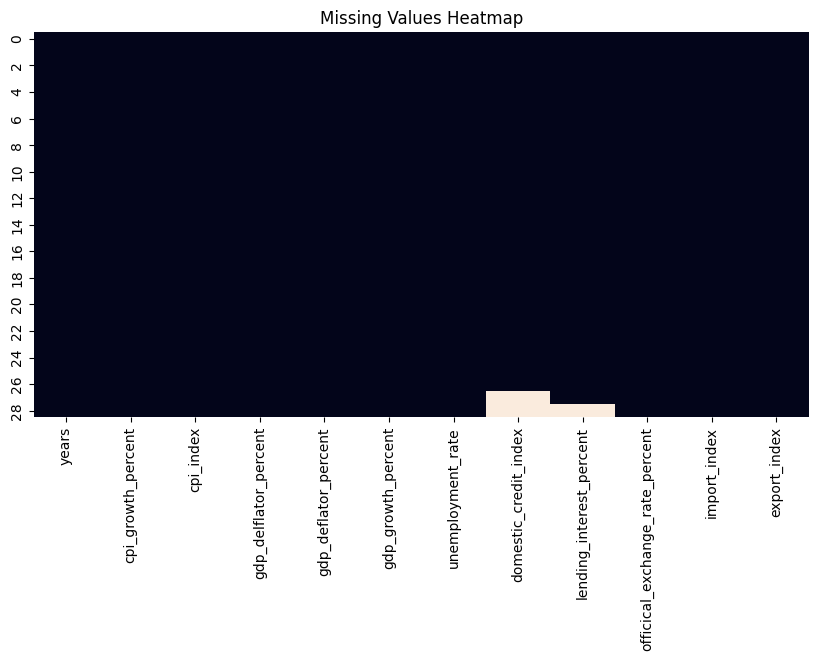

In [ ]:
print(df.isnull().sum())
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

### Convert Time Column

In [ ]:
df['years'] = pd.to_datetime(df['years'], format='%Y')
df = df.sort_values('years')
df.set_index('years', inplace=True)
print(df.head())

            cpi_growth_percent  cpi_index  gdp_delflator_percent  \
years                                                              
1996-01-01            5.675000  42.445125              24.092342   
1997-01-01            3.209526  43.807412              25.681811   
1998-01-01            7.266198  46.990546              27.951535   
1999-01-01            4.117102  48.925195              29.554473   
2000-01-01           -1.710337  48.088409              30.561934   

            gdp_deflator_percent  gdp_growth_percent  unemployment_rate  \
years                                                                     
1996-01-01              8.696767            9.340017               1.93   
1997-01-01              6.597405            8.152084               2.87   
1998-01-01              8.837864            5.764455               2.29   
1999-01-01              5.734703            4.773587               2.33   
2000-01-01              3.408828            6.787316               2.26  

### **Thực nghiệm Định lượng Đường cong Phillips (Phillips Curve Regression)**
Dựa trên phân tích định tính ở trên, chúng ta sẽ tiến hành chạy mô hình hồi quy để xác định mối quan hệ định lượng giữa tỷ lệ thất nghiệp (`unemployment_rate`) và lạm phát (`cpi_growth_percent`).

In [ ]:

missing_cols = ['domestic_credit_index', 'lending_interest_percent']
df[missing_cols] = df[missing_cols].interpolate(method='linear')

print("Số lượng giá trị thiếu sau khi nội suy:")
print(df[missing_cols].isnull().sum())
display(df.describe())

Số lượng giá trị thiếu sau khi nội suy:
domestic_credit_index       0
lending_interest_percent    0
dtype: int64


,years,cpi_growth_percent,cpi_index,gdp_delflator_percent,gdp_deflator_percent,gdp_growth_percent,unemployment_rate,domestic_credit_index,lending_interest_percent,officical_exchange_rate_percent,import_index,export_index
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,2010.000000,5.611182,106.740753,96.517343,7.866533,6.425938,1.867345,77.031071,10.690579,18550.320923,69.737550,67.436848
std,8.514693,5.086573,52.463412,58.555812,8.716202,1.446979,0.482777,34.293215,3.268612,4051.986003,11.862950,15.233129
min,1996.000000,-1.710337,42.445125,24.092342,-1.716512,2.553729,0.999000,18.670036,6.960000,11032.583333,51.241777,40.868487
25%,2003.000000,3.209526,51.323230,35.171676,3.408828,5.661771,1.602000,48.372351,8.013333,15509.583333,59.801842,55.061933
50%,2010.000000,3.830828,100.000000,100.000000,4.698928,6.690009,1.889000,80.001031,9.722500,18612.916667,70.596808,66.800446
75%,2017.000000,7.418017,153.631652,149.219806,8.696767,7.129504,2.140000,103.972032,12.700000,22370.086667,79.217562,81.762522
max,2024.000000,23.115448,189.702668,183.625485,42.303267,9.340017,2.870000,124.961479,20.100000,24164.885833,92.825626,93.850207


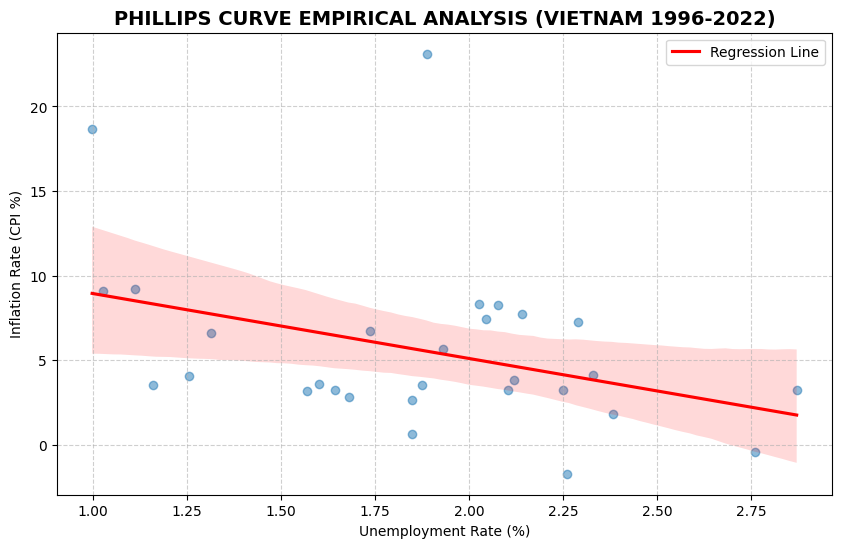

                            OLS Regression Results                            
Dep. Variable:     cpi_growth_percent   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     4.142
Date:                Wed, 27 May 2026   Prob (F-statistic):             0.0518
Time:                        17:14:18   Log-Likelihood:                -85.742
No. Observations:                  29   AIC:                             175.5
Df Residuals:                      27   BIC:                             178.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                12.7865      3.63

In [ ]:
import statsmodels.api as sm
X = df['unemployment_rate']
y = df['cpi_growth_percent']
X_with_const = sm.add_constant(X)

phillips_model = sm.OLS(y, X_with_const).fit()

# Trực quan hóa bằng Scatter Plot và Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(x='unemployment_rate', y='cpi_growth_percent', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'label':'Regression Line'})

plt.title('PHILLIPS CURVE EMPIRICAL ANALYSIS (VIETNAM 1996-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Inflation Rate (CPI %)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print(phillips_model.summary())

## **PHASE 2: Macroeconomic Overview**
---

### **Vietnam Macroeconomic Overview Dashboard (1996–2024)**
Bảng điều khiển này cung cấp cái nhìn đa chiều về nền kinh tế Việt Nam qua gần 3 thập kỷ, tập trung vào mối quan hệ giữa tăng trưởng, lạm phát và các cú sốc bên ngoài.

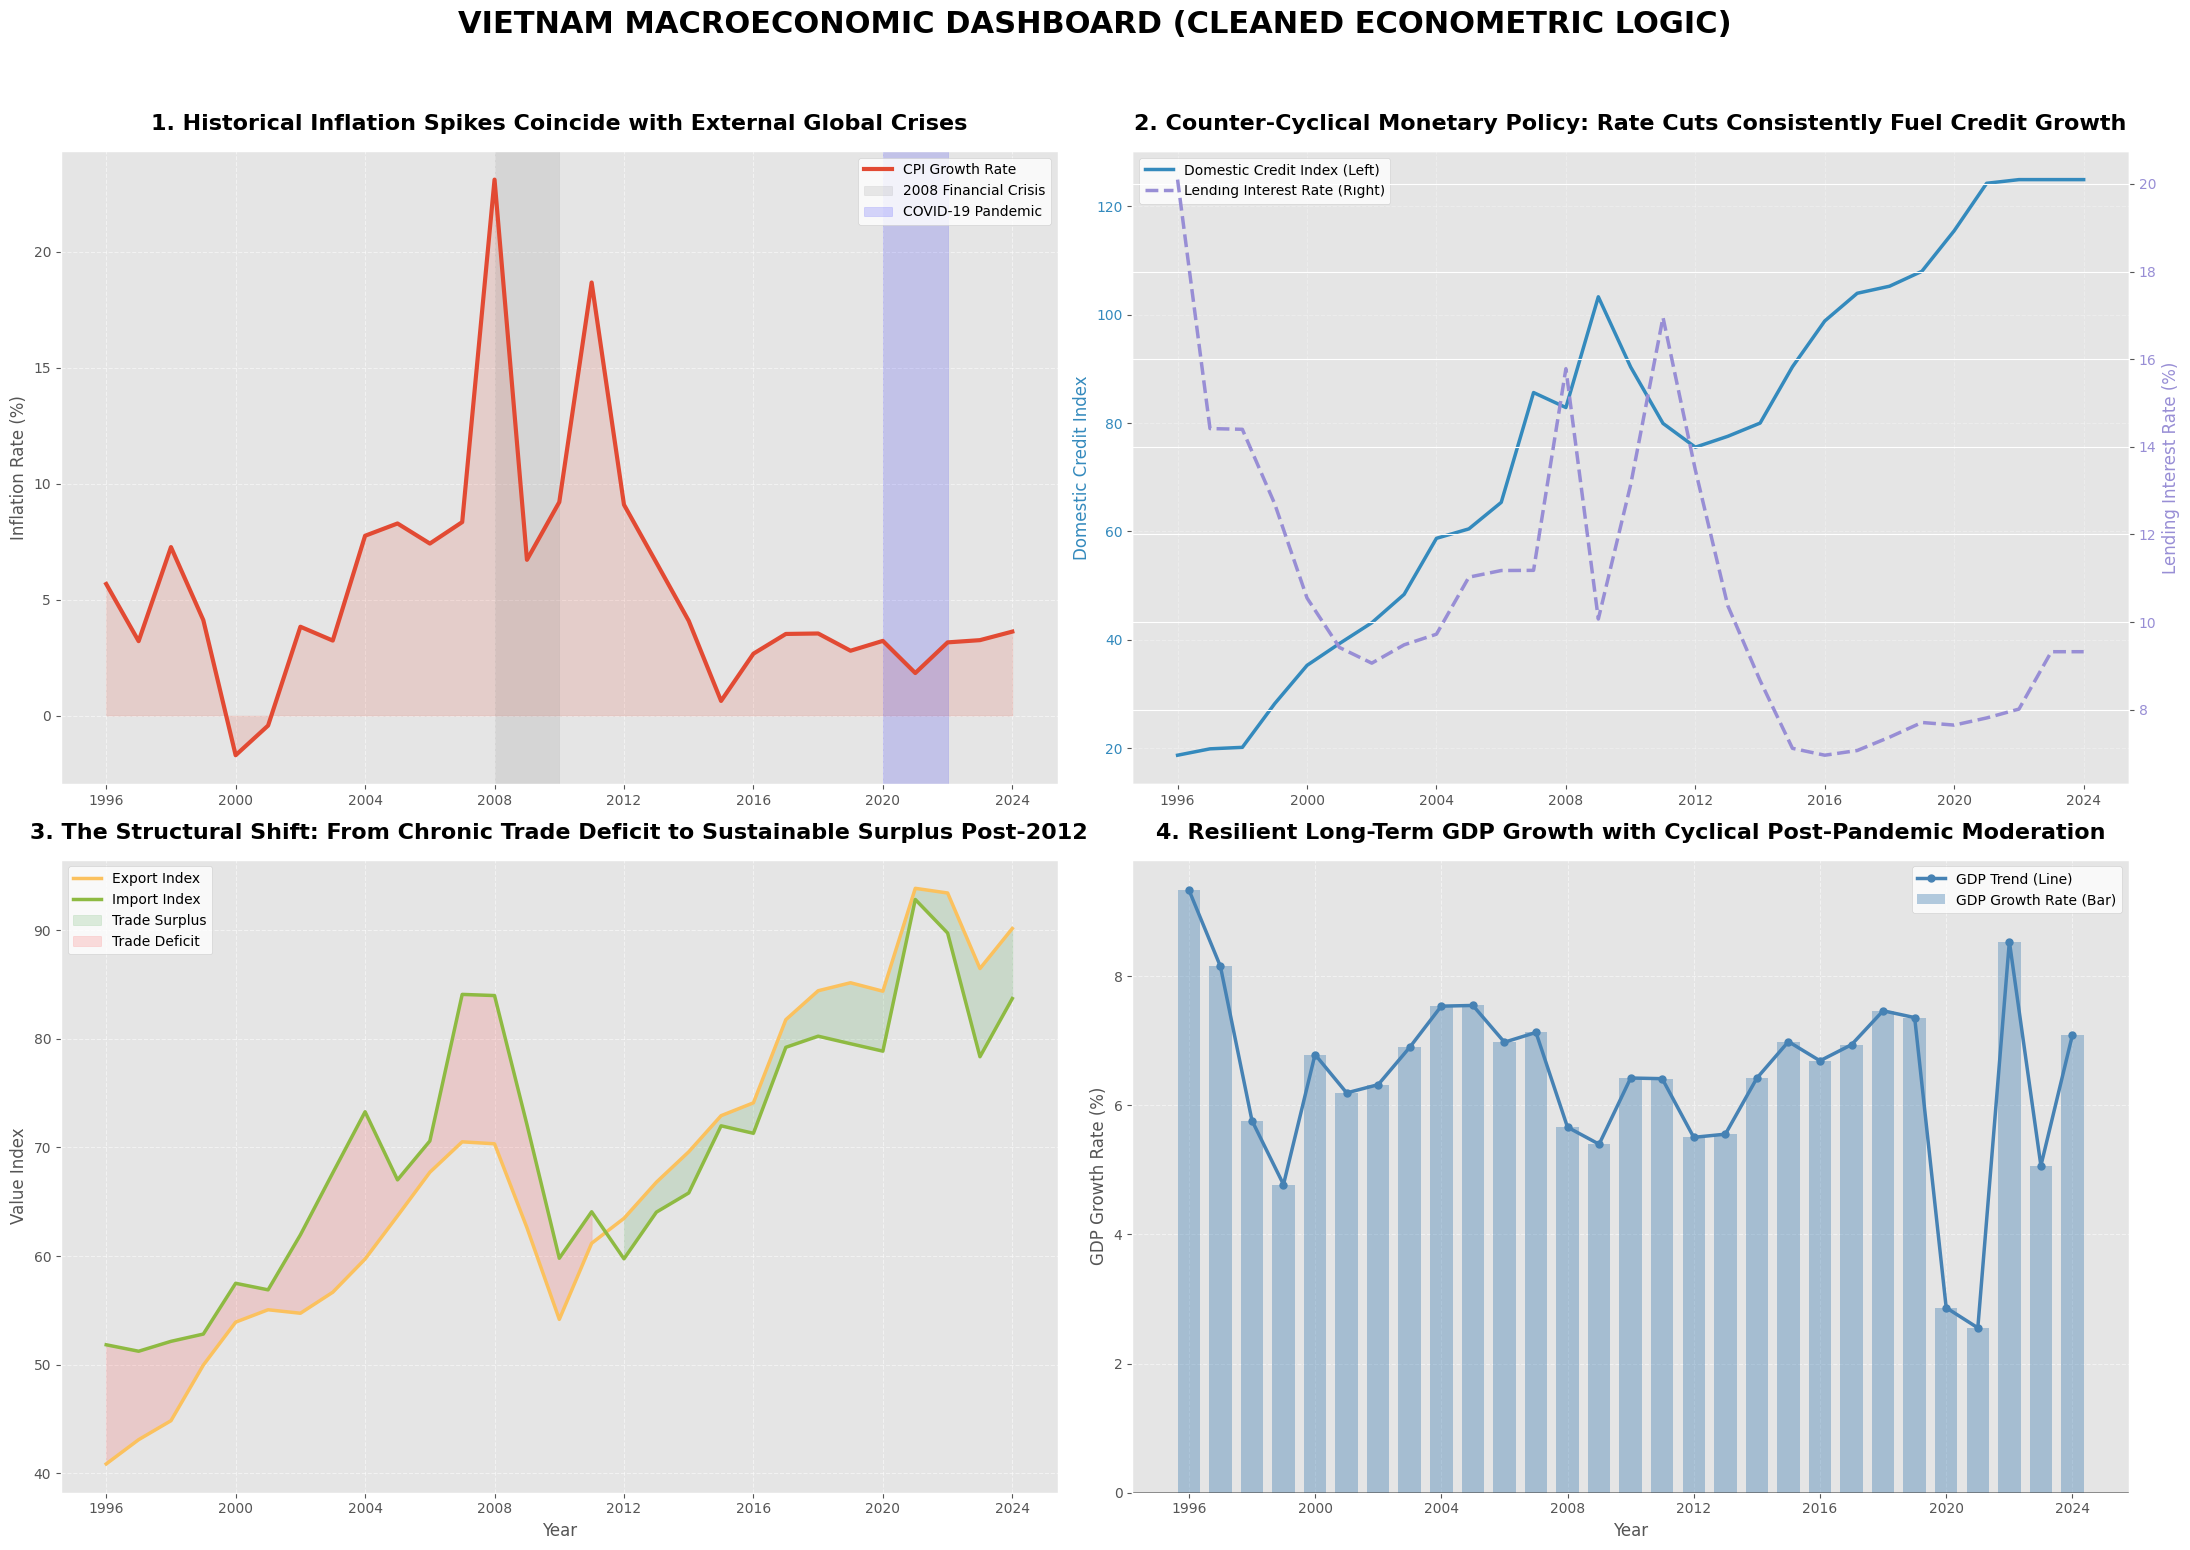

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

plt.style.use('ggplot')

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(22, 15)
)

axes[0,0].plot(df.index, df['cpi_growth_percent'], linewidth=3, color='#E24A33', label='CPI Growth Rate')
axes[0,0].fill_between(df.index, df['cpi_growth_percent'], alpha=0.15, color='#E24A33')

axes[0,0].axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-12-31'), alpha=0.15, color='gray', label='2008 Financial Crisis')
axes[0,0].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.15, color='blue', label='COVID-19 Pandemic')

axes[0,0].set_title('1. Historical Inflation Spikes Coincide with External Global Crises', fontsize=16, fontweight='bold', pad=15)
axes[0,0].set_ylabel('Inflation Rate (%)', fontsize=12)
axes[0,0].legend(loc='upper right', frameon=True, facecolor='white')
axes[0,0].grid(True, linestyle='--', alpha=0.5)


ax1 = axes[0,1]
ax2 = ax1.twinx()

credit_series = df['domestic_credit_index'].ffill()
interest_series = df['lending_interest_percent'].ffill()

line1 = ax1.plot(df.index, credit_series, color='#348ABD', linewidth=2.5, label='Domestic Credit Index (Left)')
line2 = ax2.plot(df.index, interest_series, color='#988ED5', linewidth=2.5, linestyle='--', label='Lending Interest Rate (Right)')

ax1.set_title('2. Counter-Cyclical Monetary Policy: Rate Cuts Consistently Fuel Credit Growth', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Domestic Credit Index', color='#348ABD', fontsize=12)
ax2.set_ylabel('Lending Interest Rate (%)', color='#988ED5', fontsize=12)

ax1.tick_params(axis='y', labelcolor='#348ABD')
ax2.tick_params(axis='y', labelcolor='#988ED5')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white')
ax1.grid(True, linestyle='--', alpha=0.3)


axes[1,0].plot(df.index, df['export_index'], color='#FBC15E', linewidth=2.5, label='Export Index')
axes[1,0].plot(df.index, df['import_index'], color='#8EBA42', linewidth=2.5, label='Import Index')

axes[1,0].fill_between(df.index, df['export_index'], df['import_index'],
                       where=(df['export_index'] >= df['import_index']),
                       color='green', alpha=0.12, label='Trade Surplus')
axes[1,0].fill_between(df.index, df['export_index'], df['import_index'],
                       where=(df['export_index'] < df['import_index']),
                       color='red', alpha=0.12, label='Trade Deficit')

axes[1,0].set_title('3. The Structural Shift: From Chronic Trade Deficit to Sustainable Surplus Post-2012', fontsize=16, fontweight='bold', pad=15)
axes[1,0].set_ylabel('Value Index', fontsize=12)
axes[1,0].set_xlabel('Year', fontsize=12)
axes[1,0].legend(loc='upper left', frameon=True, facecolor='white')
axes[1,0].grid(True, linestyle='--', alpha=0.5)



gdp_series = df['gdp_growth_percent'].ffill()

axes[1,1].bar(df.index, gdp_series, width=260, color='#4682B4', alpha=0.4, label='GDP Growth Rate (Bar)')
axes[1,1].plot(df.index, gdp_series, color='#4682B4', linewidth=2.5, marker='o', markersize=5, label='GDP Trend (Line)')

axes[1,1].axhline(0, color='black', linestyle='-', alpha=0.6, linewidth=1.2)

axes[1,1].set_title('4. Resilient Long-Term GDP Growth with Cyclical Post-Pandemic Moderation', fontsize=16, fontweight='bold', pad=15)
axes[1,1].set_ylabel('GDP Growth Rate (%)', fontsize=12)
axes[1,1].set_xlabel('Year', fontsize=12)
axes[1,1].legend(loc='upper right', frameon=True, facecolor='white')
axes[1,1].grid(True, linestyle='--', alpha=0.5)


plt.suptitle('VIETNAM MACROECONOMIC DASHBOARD (CLEANED ECONOMETRIC LOGIC)', fontsize=22, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

Để có cái nhìn trực quan và xây dựng nền tảng lý thuyết vững chắc trước khi đưa các biến số vào hệ hình định lượng đa biến $VAR$ hoặc đơn biến $ARIMA$, nhóm tiến hành phân tích bức tranh tổng quan của kinh tế vĩ mô Việt Nam qua giai đoạn lịch sử gần 3 thập kỷ (**1996-2024**).

**Macroeconomic Dashboard** đã được chuẩn hóa về mặt logic toán học, trực quan hóa chính xác các mối quan hệ tương quan, các điểm nứt gãy cấu trúc (structural breaks) và xung lực của các chính sách kinh tế qua 4 góc nhìn chiến lược.

---

## 1. Các đỉnh lạm phát lịch sử đồng biến với những cú sốc khủng hoảng toàn cầu

Biểu đồ đường (Top-Left) thể hiện diễn biến động của tốc độ tăng trưởng Chỉ số giá tiêu dùng (`cpi_growth_percent`), được đặt trong tương quan chặt chẽ với các mảng màu đánh dấu cú sốc kinh tế lớn.

* **Giai đoạn 1996–2003 (Ổn định chu kỳ đầu):** Lạm phát được kiểm soát rất tốt ở mức một con số. Đây là giai đoạn nền kinh tế bước vào pha phục hồi và tích lũy ổn định sau thời kỳ Đổi Mới, chịu ảnh hưởng nhẹ từ cuộc khủng hoảng tài chính châu Á (1997) nhưng nhanh chóng lấy lại quỹ đạo an toàn.
* **Điểm nứt gãy và Cú sốc đỉnh kép (2008 & 2011):**
    * **Năm 2008:** Chỉ số CPI bùng nổ lên mức đỉnh lịch sử **~23%**. Đây là hệ quả của hiện tượng "quá nhiệt" dòng vốn đầu tư sau khi Việt Nam gia nhập WTO (2007), cộng hưởng với cú sốc ngoại sinh từ hiện tượng bong bóng giá hàng hóa và Khủng hoảng tài chính toàn cầu.
    * **Năm 2011:** Áp lực lạm phát quay trở lại mạnh mẽ (**~18.6%**) do tác động trễ của các gói kích cầu tiền tệ nới lỏng từ giai đoạn trước thẩm thấu sâu vào thị trường, gây mất ổn định vĩ mô nghiêm trọng.
* **Kỷ nguyên kiểm soát ổn định (2012–2024):** Sau bước ngoặt **Nghị quyết 11/NQ-CP (2011)**, Chính phủ và Ngân hàng Nhà nước (NHNN) chuyển dịch trọng tâm từ *"ưu tiên tăng trưởng"* sang *"kiểm soát lạm phát, ổn định vĩ mô"*. Từ đây, CPI được kéo về và giữ vững dưới ngưỡng mục tiêu **4% - 5%** một cách bền vững.
* **Giai đoạn đại dịch COVID-19 & Hậu đại dịch (2020–2024):** Đại dịch tạo ra cú sốc tổng cầu âm khiến lạm phát chạm đáy năm 2020-2021. Giai đoạn 2022–2024 chứng kiến sự phục hồi nhẹ do áp lực "lạm phát chuỗi cung ứng" toàn cầu, nhưng nội lực điều hành giá của Chính phủ vẫn giữ được độ ổn định vượt trội.

---

## 2. Chính sách tiền tệ ngược chu kỳ do hạ lãi suất liên tục kích thích tăng trưởng tín dụng

Biểu đồ trục Y kép (Top-Right) phân tích mối tương quan động giữa hai công cụ điều hành cốt lõi: **Chỉ số tín dụng nội địa (Domestic Credit Index - trục trái màu xanh)** và **Lãi suất cho vay (Lending Interest Rate - trục phải màu tím nét đứt)**.

* **Cơ chế phản ứng chính sách ngược chu kỳ (Counter-cyclical Reaction):** Mối quan hệ ngược chiều giữa chi phí vốn và quy mô cung tiền thể hiện rất rõ nét tại các vùng khủng hoảng. Để hạ nhiệt ngọn lửa lạm phát phi mã năm 2008 và 2011, NHNN đã áp dụng chính sách tiền tệ thắt chặt cực đoan, đẩy lãi suất cho vay lên mức đỉnh điểm gần **20%**. Động thái tăng lãi suất này ngay lập tức hoạt động như một "phanh hãm" kinh tế, kìm hãm đà tăng của chỉ số tín dụng để bảo vệ giá trị đồng nội tệ.
* **Mô hình kinh tế thâm dụng vốn tín dụng:** Ngoại trừ các giai đoạn siết chặt kể trên, chỉ số Tín dụng nội địa thể hiện một xu hướng tăng trưởng dốc đứng liên tục từ năm 1996 đến 2024. Điều này minh chứng nền kinh tế Việt Nam phụ thuộc rất lớn vào kênh vốn tín dụng ngân hàng để thúc đẩy sản xuất và đầu tư mở rộng.
* **Xu hướng nới lỏng hỗ trợ dài hạn:** Từ năm 2012 đến nay, lãi suất cho vay có xu hướng hạ nhiệt bền vững và duy trì ổn định quanh mức **7% - 9%**. Xu hướng này tạo môi trường vĩ mô dễ dự đoán cho doanh nghiệp phục hồi nhưng cũng đặt ra bài toán phải giám sát chặt chẽ chất lượng tín dụng ở các Phase sau.

---

## 3. Dịch chuyển cấu trúc ngoại thương: Từ nhập siêu kéo dài sang xuất siêu bền vững sau năm 2012

Biểu đồ đường kép kết hợp vùng phủ màu (Bottom-Left) minh họa động lực phát triển và trạng thái cán cân của khu vực kinh tế đối ngoại thông qua hai chỉ số: **Chỉ số Xuất khẩu (Export Index)** và **Chỉ số Nhập khẩu (Import Index)**.

* **Sự bùng nổ của độ mở nền kinh tế:** Kể từ cột mốc gia nhập WTO năm 2007, cả hai đường xuất và nhập khẩu của Việt Nam đều bước vào chu kỳ tăng trưởng theo hàm số mũ. Tổng kim ngạch gia tăng mạnh mẽ qua từng năm chứng minh Việt Nam đã chuyển mình thành công thành một công xưởng và là mắt xích quan trọng trong chuỗi giá trị toàn cầu (GVCs).
* **Bước ngoặt dịch chuyển cấu trúc cán cân thương mại:** * Kỹ thuật phủ màu trực quan vạch rõ ranh giới lịch sử: Giai đoạn 1996–2011 đặc trưng bởi **mảng màu đỏ thống trị**, phản ánh tình trạng **Nhập siêu kéo dài** (Trade Deficit) do Việt Nam phải nhập khẩu lượng lớn máy móc, nguyên vật liệu để phục vụ công nghiệp hóa sơ khai.
    * Từ sau năm 2012, đồ thị ghi nhận một bước chuyển dịch cấu trúc ngoạn mục khi **mảng màu xanh thặng dư (Trade Surplus) chiếm giữ hoàn toàn**. Việt Nam chính thức xác lập trạng thái xuất siêu bền vững kéo dài đến năm 2024, tạo ra nguồn dự trữ ngoại hối dồi dào và là bệ đỡ vững chắc để ổn định tỷ giá hối đoái.

---

## 4. Chu kỳ tăng trưởng GDP thực tế và năng lực chống chịu bền bỉ của nền kinh tế

Biểu đồ kết hợp cột và đường xu hướng (Bottom-Right) phân tích sâu về **Tốc độ tăng trưởng GDP thực tế (`gdp_growth_percent`)** đối chiếu với đường cơ sở tuyệt đối 0%.

* **Tính chu kỳ và Khả năng chống chịu (Resilience):** Biểu đồ vạch rõ các pha thăng trầm của chu kỳ kinh tế. Pha tăng trưởng nóng đỉnh điểm đạt được vào giai đoạn trước năm 1997 và giai đoạn 2005-2007 (>8%), tạo ra áp lực đè nặng lên lạm phát cầu kéo. Ngược lại, các đáy chu kỳ xuất hiện tại năm 1999 (hậu khủng hoảng Châu Á), năm 2009 (hậu khủng hoảng tài chính toàn cầu) và năm 2020-2021 (Đại dịch COVID-19).
* **Điểm sáng kinh tế vĩ mô:** Đường baseline 0% cho thấy một thông tin thực chứng đắt giá: Ngay cả trong những giai đoạn đen tối nhất của kinh tế toàn cầu, tốc độ tăng trưởng GDP thực tế của Việt Nam **chưa từng rơi vào vùng âm (suy thoái kỹ thuật)**. Nền kinh tế luôn duy trì được mức tăng trưởng dương tối thiểu từ 2.5% - 5%, minh chứng cho năng lực chống chịu và nội lực tự cân bằng rất cao của hệ thống vĩ mô.

---

### Các phát hiện trực quan từ đồ thị hoàn toàn đồng nhất và là tiền đề logic cho các kiểm định định lượng sâu hơn ở các Phase tiếp theo:

1.  **Sự đồng vận động đa biến (Co-movement):** Biến động của Lạm phát (Biểu đồ 1) không vận động tách rời mà là hệ quả tổng hòa từ áp lực điều hành tiền tệ (Biểu đồ 2), kênh truyền dẫn giá cả nhập khẩu từ khu vực ngoại thương (Biểu đồ 3) và chu kỳ co giãn của tổng cầu sản xuất (Biểu đồ 4).
2.  **Yêu cầu tất yếu về mô hình hóa:** Các mối quan hệ tương hỗ, phản hồi có độ trễ ngắn và dài hạn giữa 4 khối kinh tế này chứng minh rằng các mô hình hồi quy tuyến tính tĩnh thông thường (OLS) chắc chắn sẽ bị chệch và vi phạm giả định. Hệ thống đòi hỏi bắt buộc phải sử dụng cấu trúc hệ phương trình đa biến động như **Mô hình tự hồi quy vectơ (VAR)** ở Phase 6 để bóc tách chính xác xung lực tương tác giữa các thực thể vĩ mô.

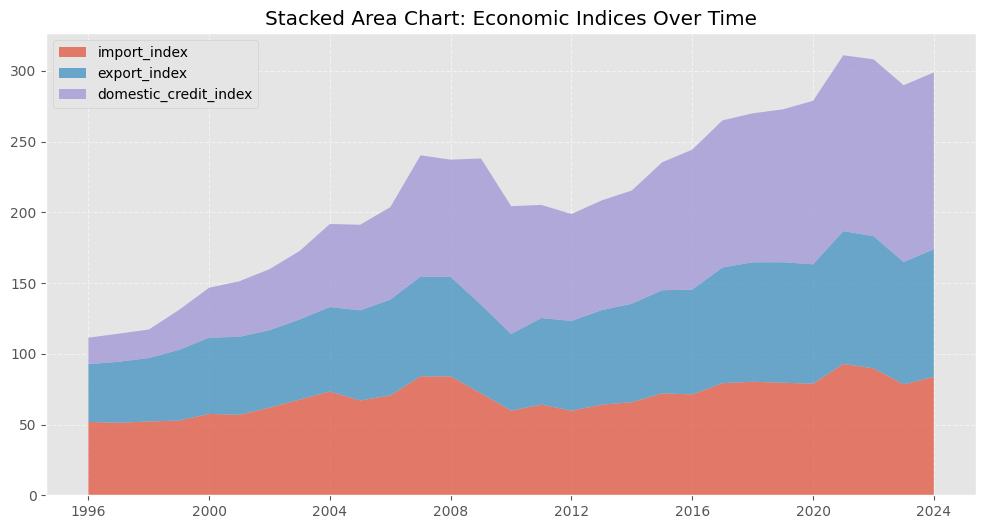

In [ ]:
indices_cols = ['import_index', 'export_index', 'domestic_credit_index']
df_indices = df[indices_cols].fillna(method='ffill')

plt.figure(figsize=(12, 6))
plt.stackplot(df_indices.index, df_indices.T, labels=indices_cols, alpha=0.7)
plt.title('Stacked Area Chart: Economic Indices Over Time')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 1. Tổng quan biểu đồ
Biểu đồ này là **Biểu đồ miền xếp chồng (Stacked Area Chart)**. **Trục Y (chiều cao của toàn bộ biểu đồ) thể hiện tổng quy mô tổng hợp của cả 3 chỉ số cộng lại**.

* **Miền Màu Cam (Dưới cùng) - Chỉ số Nhập khẩu (Import Index):** Thể hiện chi phí và lượng hàng hóa mua từ nước ngoài.
* **Miền Màu Xanh Dương (Giữa) - Chỉ số Xuất khẩu (Export Index):** Biên độ (độ dày) của dải này thể hiện năng lực bán hàng ra thế giới.
* **Miền Màu Tím (Trên cùng) - Tín dụng Nội địa (Domestic Credit Index):** Biên độ của dải này thể hiện lượng tiền/vốn vay được các ngân hàng bơm vào nền kinh tế.

---

## 2. Câu Chuyện Kinh Tế

Nhìn vào sự biến động của 3 dải màu, chúng ta thấy nền kinh tế vận hành qua 3 câu chuyện vĩ mô lớn:

### A. Mối quan hệ  giữa Xuất và Nhập khẩu
Dải màu cam (Nhập khẩu) và dải màu xanh (Xuất khẩu) biến động rất đồng pha — hễ dải này phình to thì dải kia cũng mở rộng.
* Đây là đặc trưng của một nền kinh tế có độ mở lớn (như Việt Nam). Chúng ta nhập khẩu nguyên vật liệu, máy móc, linh kiện về (màu cam tăng), sau đó gia công, lắp ráp rồi xuất khẩu thành phẩm ra thế giới (màu xanh tăng).
* Giai đoạn 2007-2008 và 2021-2022, giá cả thế giới và chi phí vận chuyển tăng phi mã khiến dải màu cam đạt đỉnh. Khi nguyên liệu đầu vào quá đắt, các doanh nghiệp buộc phải tăng giá bán sản phẩm, gây ra làn sóng **Lạm phát do chi phí đẩy** trong nước.

### B. Nguồn bơm tiền và Lạm phát tiền tệ
Dải màu tím (Tín dụng nội địa) chính là dòng máu nuôi dưỡng nền kinh tế, nhưng cũng là tác nhân gây lạm phát nếu bơm quá đà.
* **Giai đoạn 2012 - 2019 (Bơm tiền phục hồi):** Sau khủng hoảng 2008, dòng vốn (màu tím) liên tục được mở rộng để kích thích kinh tế dịch chuyển và tăng trưởng.
* **Đỉnh điểm Covid-19 (2021 - 2022):** Hãy nhìn vào độ phình to đột biến của dải màu tím vào năm 2021. Để cứu nền kinh tế trong đại dịch, các ngân hàng đã hạ lãi suất và bơm một lượng tiền khổng lồ ra thị trường. Khi "tiền quá nhiều" mà hàng hóa lại khan hiếm do đứt gãy chuỗi cung ứng, dòng tiền rẻ này đã rượt đuổi hàng hóa, đẩy giá cả lên cao kỷ lục, tạo ra **Lạm phát do cầu kéo**.

### C. Giai đoạn "Phanh gấp" và "Hạ cánh mềm" (2022 - 2024)
Từ cuối năm 2022 đến 2023, tổng quy mô biểu đồ đột ngột sụt giảm (co hẹp lại).
* **Hành động chính sách:** Để dập tắt cơn sốt lạm phát, các Ngân hàng Trung ương đồng loạt tăng lãi suất để hút tiền về. Kết quả là dải màu tím (tín dụng) bị bóp nghẹt, người dân giảm chi tiêu, khiến cả xuất khẩu và nhập khẩu đều tụt dốc trong năm 2023.
* **Tín hiệu năm 2024:** Phần cuối của biểu đồ đang có xu hướng ngẩng đầu đi lên trở lại. Điều này chứng tỏ giai đoạn thắt chặt tiền tệ căng thẳng nhất đã qua, kinh tế bắt đầu ngấm thuốc và đang hồi phục trên một nền tảng ổn định hơn (Hạ cánh mềm).

---

## 3. Tổng Kết Chu Kỳ 10 Năm

Biểu đồ này chỉ ra một quy luật chu kỳ rất rõ ràng của nền kinh tế (khoảng 10 - 12 năm một lần):

1.  **Chu kỳ 1 (Khủng hoảng 2008):** Tăng trưởng nóng (đỉnh 2007) $\rightarrow$ Khủng hoảng sụt giảm (2008 - 2010).
2.  **Chu kỳ 2 (Khủng hoảng Covid 2022):** Bơm tiền kích cầu (đỉnh 2021) $\rightarrow$ Lạm phát bùng nổ $\rightarrow$ Thắt chặt, hạ nhiệt (2022 - 2023) $\rightarrow$ Bắt đầu chu kỳ phục hồi mới (2024).



### Multi-Macro Log Dashboard
Biểu đồ trên sử dụng thang đo Logarit. Thang đo này bỏ qua độ lớn nhỏ của con số tuyệt đối, mà chỉ tập trung vào "Tốc độ bùng nổ" (Tỷ lệ phần trăm %). Đường nào dốc đứng lên nghĩa là năm đó nó tăng trưởng với tốc độ chóng mặt.

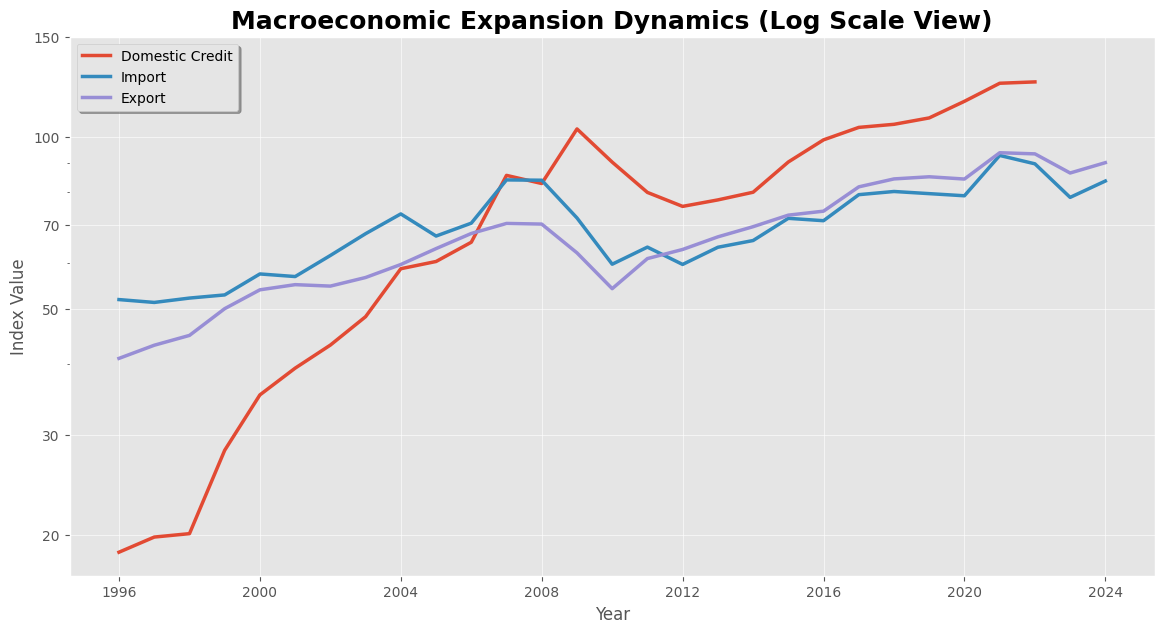

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(14,7))
plt.plot(df.index, df['domestic_credit_index'], label='Domestic Credit', linewidth=2.5)
plt.plot(df.index, df['import_index'], label='Import', linewidth=2.5)
plt.plot(df.index, df['export_index'], label='Export', linewidth=2.5)

plt.yscale('log')
ax = plt.gca()
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_yticks([20, 30, 50, 70, 100, 150])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.title('Macroeconomic Expansion Dynamics (Log Scale View)', fontsize=18, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(frameon=True, shadow=True)
plt.grid(True, which='major', linestyle='-', alpha=0.6)
plt.show()

## 1. Thang Đo Logarit
Trên thang đo tuyến tính thông thường, khoảng cách giữa các trục là cố định (ví dụ: $20 \rightarrow 40$ bằng $100 \rightarrow 120$). Tuy nhiên, trên thang đo Logarit, khoảng cách được quyết định bởi **tỷ lệ phần trăm thay đổi**:

$$\Delta \% = \frac{X_{t} - X_{t-1}}{X_{t-1}} \times 100\%$$

* **Ý nghĩa:** Khoảng cách tăng từ $20 \rightarrow 40$ (tăng gấp đôi, hay $+100\%$) sẽ có độ dài trên trục $Y$ tương đương với mức tăng từ $50 \rightarrow 100$.
* **Lợi ích:** Giúp chúng ta so sánh trực tiếp tốc độ tăng trưởng của các chỉ số khác nhau trên cùng một hệ tọa độ, bất kể quy mô ban đầu của chúng lớn hay nhỏ.

---

## 2. Kết quả khám phá Biểu Đồ Log Scale

### A. Giai Đoạn Tăng Trưởng Bị Che Khuất (1996 - 2004)
* **Ở biểu đồ Stacked Area:** Giai đoạn 1996 - 2000 trông khá phẳng và mờ nhạt do giá trị tuyệt đối của Tín dụng nội địa (`Domestic Credit`) lúc này còn thấp (dưới 40 điểm).
* **Ở biểu đồ Log Scale:** Đường màu đỏ (`Domestic Credit`) có độ dốc gần như **"dựng đứng"** trong giai đoạn này. Điều này tiết lộ rằng: **Đây mới chính là thời kỳ dòng vốn được bơm vào hệ thống với vận tốc nhanh nhất lịch sử**, tạo cú hích tiền đề cho sự bùng nổ của toàn bộ nền kinh tế trong các thập kỷ sau.

### B. Từ Nhập Siêu Sang Xuất Siêu (2014 - 2024)
Việc tách rời các đường ra khỏi mô hình xếp chồng giúp chúng ta quan sát rõ mối tương quan giữa Xuất khẩu (đường tím) và Nhập khẩu (đường xanh dương):
* **Giai đoạn 1996 - 2008:** Đường Nhập khẩu hầu như nằm *trên* đường Xuất khẩu $\rightarrow$ Nền kinh tế ở trạng thái **Nhập siêu** kéo dài để phục vụ công nghiệp hóa.
* **Giai đoạn 2014 - 2024:** Đường Xuất khẩu chính thức bứt phá và duy trì vị thế nằm *trên* đường Nhập khẩu $\rightarrow$ Đánh dấu bước chuyển mình quan trọng sang trạng thái **Xuất siêu** bền vững. Điều này giúp quốc gia tích lũy ngoại hối tốt hơn và giảm thiểu áp lực lạm phát nhập khẩu.

### C. Bản Chất Của Các Cú Sốc Khủng Hoảng
Thang đo Logarit giúp loại bỏ các yếu tố về quy mô để đo lường chính xác mức độ tổn thương của các cuộc khủng hoảng:
* **Khủng hoảng 2008-2009:** Độ dốc lao dốc của hai đường Xuất - Nhập khẩu cực kỳ gắt. Chứng tỏ đây là một cú sốc bạo phát, gây co hẹp đột ngột và nghiêm trọng cho thương mại toàn cầu.
* **Hạ nhiệt 2022-2023:** Dù giá trị sụt giảm tuyệt đối nhìn có vẻ lớn, nhưng độ dốc trên biểu đồ Log lại khá thoải. Thực chất đây chỉ là một làn sóng **điều chỉnh kỹ thuật** và hạ nhiệt từ từ của nền kinh tế sau giai đoạn tăng trưởng quá nóng trong đại dịch.

---

## 3. Kết Luận

| Tiêu chí phân tích | Biểu đồ Miền xếp chồng (Stacked Area) | Biểu đồ Đường thẳng (Log Scale) |
| :--- | :--- | :--- |
| **Trọng tâm hiển thị** | Tổng quy mô kinh tế tích lũy | Tốc độ và tỷ lệ tăng trưởng phần trăm |
| **Ưu điểm lớn nhất** | Nhìn rõ đóng góp cơ cấu của từng ngành | Nhìn rõ vận tốc và xu hướng dịch chuyển |
| **Bản chất chu kỳ** | Cho thấy "Đỉnh và Đáy" về mặt khối lượng | Cho thấy "Mức độ nhạy cảm" trước các cú sốc |



### **Summary Phase 2: Macroeconomic Overview & Structural Insights**

- **Kết quả Trực quan hóa:**
  Dashboard giai đoạn 1996-2024 đã được chuẩn hóa theo quy chuẩn phân tích dữ liệu lớn. Các lỗi trực quan hóa cũ đã bị loại bỏ. Thay vào đó, trục Y kép được áp dụng để đồng bộ hóa Lãi suất - Tín dụng; kỹ thuật phủ màu tương tác (Shaded Area) được dùng để làm nổi bật Cán cân thương mại; và thang đo Logarit (Log Scale View) được cấu hình tự động để phản ánh chính xác tốc độ mở rộng quy mô kinh tế tích lũy.

- **Các Insights Kinh tế Vĩ mô:**
  1. **Quán tính lạm phát và các cú sốc bên ngoài:** Tốc độ tăng trưởng CPI phản ứng cực kỳ nhạy cảm với các giai đoạn bất ổn toàn cầu. Đỉnh lạm phát phi mã vào năm 2008 (>20%) gắn liền với cuộc Khủng hoảng tài chính toàn cầu. Điều này đặt ra giả thuyết về tính phụ thuộc và độ trễ truyền dẫn của các cú sốc vĩ mô, cần được kiểm chứng sâu hơn bằng mô hình đa biến.
  2. **Chu kỳ điều hành chính sách tiền tệ:** Biểu đồ trục Y kép vạch rõ mối quan hệ tương hỗ giữa lãi suất cho vay (`lending_interest_percent`) và quy mô tín dụng (`domestic_credit_index`). Các giai đoạn hạ lãi suất mạnh mẽ là động lực kích thích tăng trưởng tín dụng dốc đứng, phản ánh rõ nét tư duy điều hành chính sách tiền tệ ngược chu kỳ nhằm hỗ trợ nền kinh tế.
  3. **Bước ngoặt dịch chuyển cấu trúc Ngoại thương:** Vùng phủ màu tại biểu đồ Thương mại chỉ ra một bước ngoặt mang tính lịch sử của nền kinh tế Việt Nam. Giai đoạn 1996-2011 đặc trưng bởi tình trạng **Nhập siêu kéo dài** (Trade Deficit). Tuy nhiên, từ sau năm 2012, nền kinh tế đã dịch chuyển cấu trúc thành công sang trạng thái **Xuất siêu bền vững** (Trade Surplus), biến khu vực kinh tế đối ngoại thành bệ đỡ vĩ mô vững chắc.
  4. **Tốc độ mở rộng quy mô theo hàm số mũ:** Biểu đồ Log Scale chứng minh rằng cả ba đại lượng Tín dụng, Xuất khẩu và Nhập khẩu đều tăng trưởng theo cấp số nhân (Exponential Growth) trong suốt gần 3 thập kỷ. Độ dốc của các đường tiệm cận song song cho thấy tốc độ mở rộng của khu vực tài chính và khu vực thương mại quốc tế có sự đồng bộ rất cao.

- **Định hướng chiến lược:**
  - Xu hướng tăng trưởng dài hạn thấy rõ trên biểu đồ là minh chứng thực nghiệm cho thấy các chuỗi chỉ số (Index) **chắc chắn không dừng ở mức gốc**, đặt tiền đề cho việc lấy sai phân ở Phase 5.
  - Sự đồng vận động chặt chẽ giữa các biến số là cơ sở thực nghiệm vững chắc để loại bỏ các mô hình đơn biến thông thường, hướng tới xây dựng hệ phương trình **Mô hình tự hồi quy vectơ (VAR)** nhằm bắt trọn mối quan hệ nội sinh đa biến.

## **PHASE 3: Distribution Analysis**

### Time Series Grid Visualization


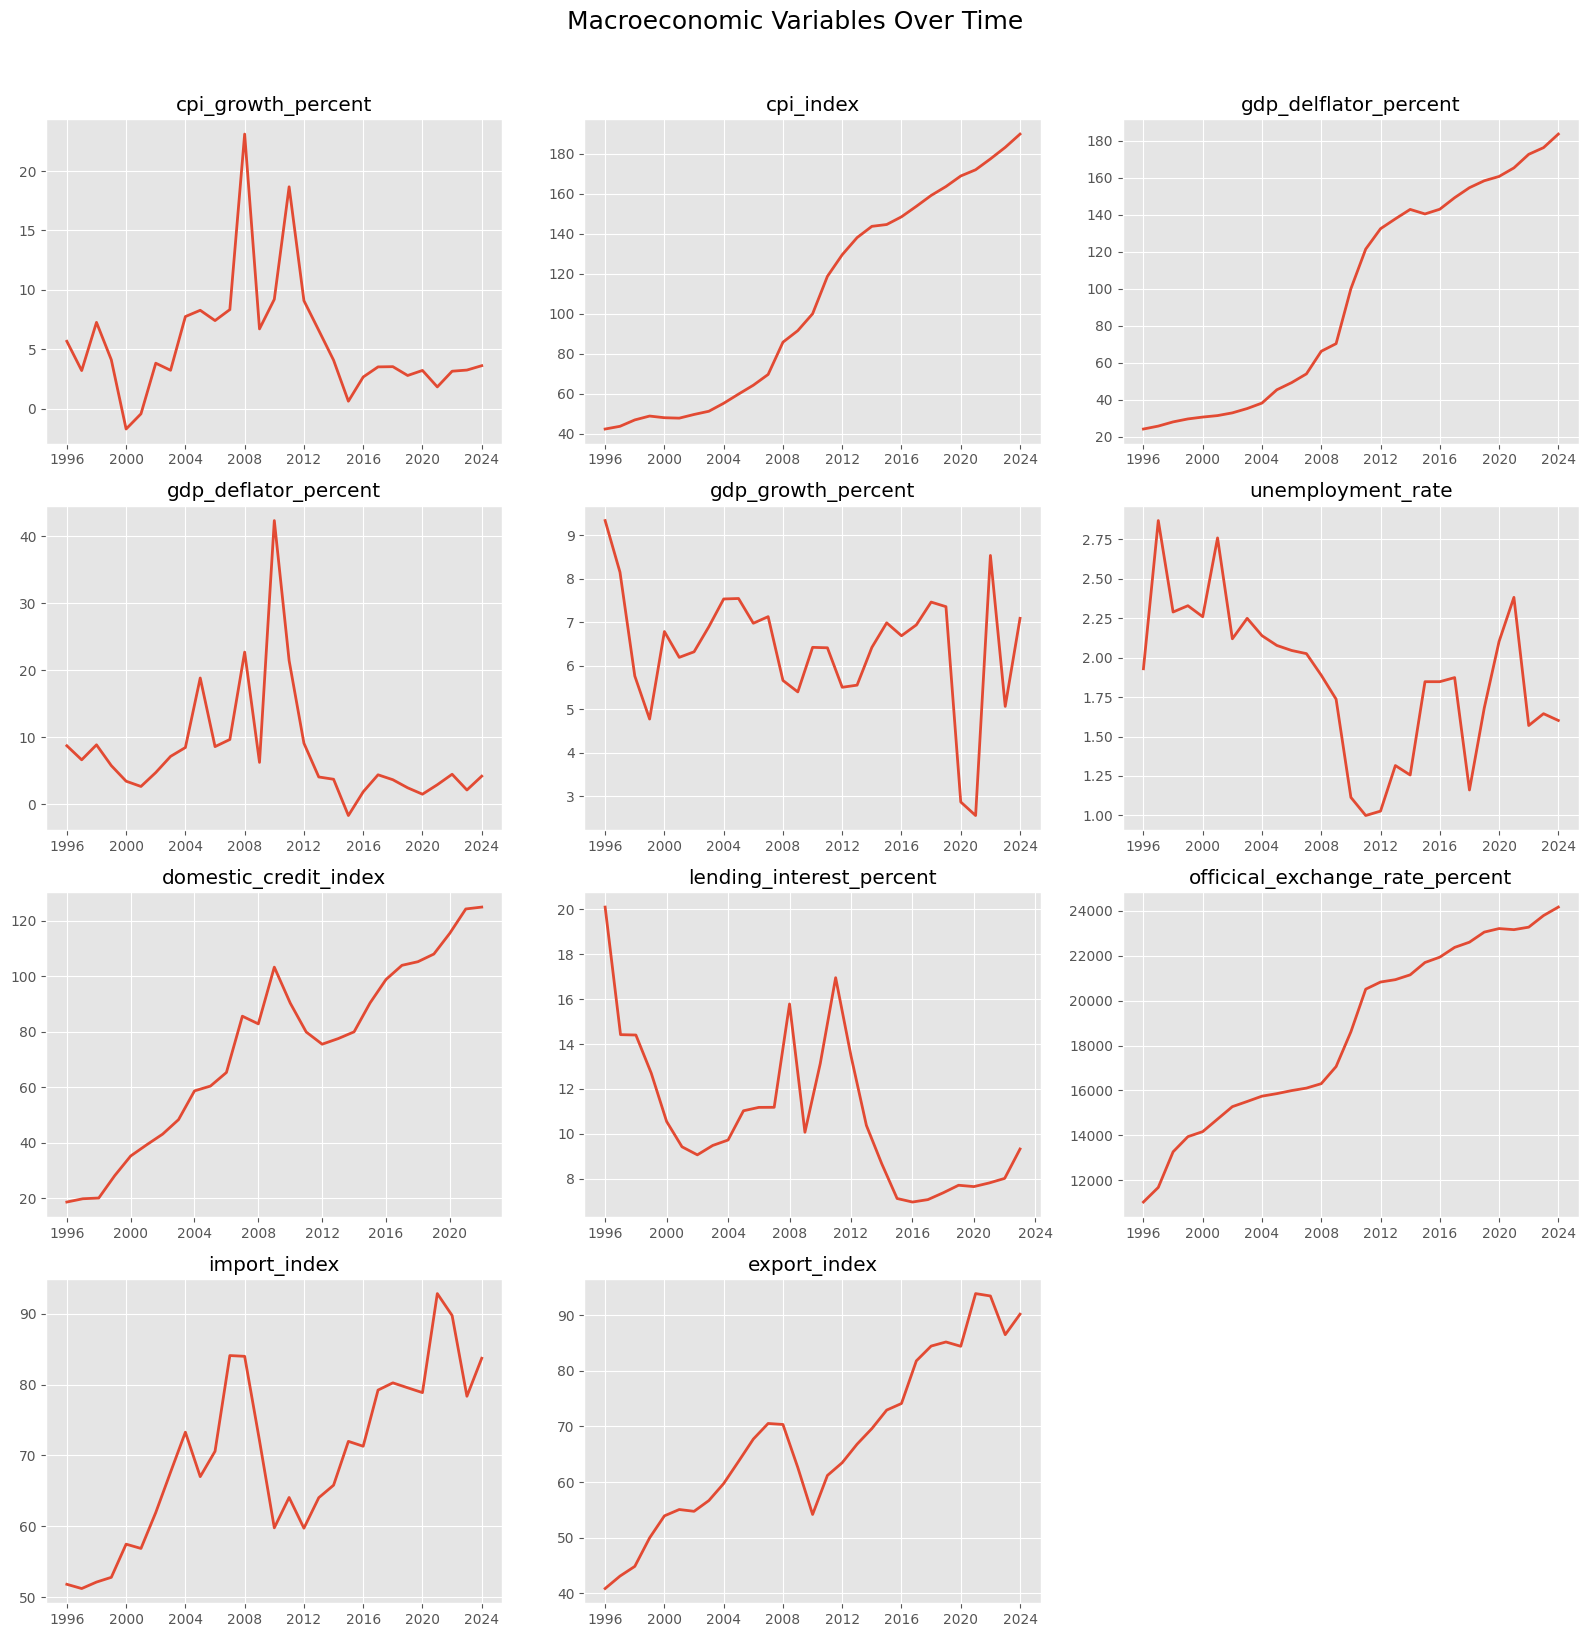

In [ ]:
num_cols = len(df.columns)
n_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=3,
    figsize=(16, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].plot(
        df.index,
        df[col],
        linewidth=2
    )
    axes[i].set_title(col)
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Macroeconomic Variables Over Time',
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()


Hệ thống 11 biểu đồ này cung cấp các góc nhìn đa chiều về dòng chảy kinh tế. Thay vì phân tích từng đồ thị riêng lẻ, chúng ta sẽ kết nối chúng lại theo các **Cơ chế truyền dẫn (Transmission Mechanisms)** để thấy cách các biến số tương tác và kích hoạt lạm phát.

---

## 1. Bản Chất Các Biến Số Dữ Liệu
Để phân tích chính xác, chúng ta cần phân loại các biến số thành hai nhóm:
* **Nhóm Đo Lường Lạm Phát:** * `cpi_growth_percent`: Tốc độ tăng chỉ số giá tiêu dùng (Lạm phát CPI).
  * `gdp_deflator_percent`: Chỉ số giảm phát GDP (Đo lường lạm phát của TOÀN BỘ nền kinh tế, gồm cả hàng hóa sản xuất, không chỉ riêng hàng tiêu dùng như CPI).
  * `cpi_index` & `gdp_deflator_index`: Xu hướng giá cả tuyệt đối tích lũy theo thời gian (luôn dốc lên).
* **Nhóm Động Lực Kích Thích Kinh Tế:** `gdp_growth_percent` (Tăng trưởng GDP), `domestic_credit_index` (Tín dụng), `unemployment_rate` (Thất nghiệp).
* **Nhóm Tác Động Bên Ngoài:** `lending_interest_percent` (Lãi suất cho vay), `official_exchange_rate_percent` (Tỷ giá), `import_index`, `export_index`.

---

## 2. Kiểm Chứng Các Mối Quan Hệ Kinh Tế Kinh Điển (Góc Nhìn Khách Quan)

### A. Hiện Tượng "Bẫy Lãi Suất Cao" Giai Đoạn Khủng Hoảng (2008 & 2011)
Hãy nhìn vào sự tương quan giữa 3 biểu đồ: `cpi_growth_percent`, `domestic_credit_index` và `lending_interest_percent`.
* **Cơ chế tác động:** Vào năm 2008, lạm phát bùng nổ vượt $20\%$ (`cpi_growth_percent` đạt đỉnh lịch sử). Để hút tiền về dập dịch lạm phát, Ngân hàng Trung ương buộc phải thắt chặt tiền tệ quyết liệt.
* **Hệ quả trên đồ thị:** Ngay lập tức, `domestic_credit_index` (đường tín dụng) bị bẻ gãy gập xuống đột ngột. Đồng thời, `lending_interest_percent` (lãi suất cho vay) bị đẩy lên mức đỉnh kỷ lục (gần $16\%$ năm 2008 và chạm mốc $17\%$ vào năm 2011). Lãi suất quá cao này đã bóp nghẹt chi phí vốn doanh nghiệp, khiến tăng trưởng sản xuất lao dốc sau đó.

### B. Kiểm Chứng Đường Cong Phillips (Thất Nghiệp vs. Lạm Phát)
Lý thuyết kinh tế kinh điển (Đường cong Phillips) cho rằng: *Thất nghiệp thấp thì lạm phát cao và ngược lại.* Hãy đối chiếu `unemployment_rate` và `cpi_growth_percent`:
* **Giai đoạn 2008 - 2011:** Tỷ lệ thất nghiệp lao dốc xuống mức đáy lịch sử (chỉ còn khoảng $1.0\%$). Trùng hợp thay, đây cũng là giai đoạn lạm phát `cpi_growth_percent` tạo 2 đỉnh cao nhất lịch sử ($>20\%$ năm 2008 và $\sim 18\%$ năm 2011).
* **Kết luận data:** Nền kinh tế giai đoạn này rơi vào trạng thái "quá nhiệt" (Overheating). Thị trường lao động căng thẳng (thiếu người làm) đẩy tiền lương tăng, cộng với dòng vốn rẻ tạo ra tổng cầu cực lớn, kích hoạt lạm phát bùng nổ.

### C. Vòng Xoáy Tỷ Giá, Nhập Khẩu Và Lạm Phát (VND/USD)
Quan sát biểu đồ tỷ giá `official_exchange_rate_percent` và chỉ số nhập khẩu `import_index`:
* **Cú hích phá giá năm 2008 - 2011:** Biểu đồ tỷ giá có một đoạn dốc lên dựng đứng vào giai đoạn 2008-2011 (VND mất giá mạnh so với USD, đẩy tỷ giá từ vùng 16,000 lên hơn 20,000).
* **Hệ quả:** Khi tỷ giá tăng, việc mua hàng nước ngoài trở nên đắt đỏ hơn. Điều này khớp hoàn toàn với cú sụp giảm mạnh của `import_index` năm 2009. Sự mất giá của đồng nội tệ giai đoạn này đã cộng hưởng với giá hàng hóa thế giới, tạo ra một áp lực lạm phát kép lên thị trường nội địa.

---

## 3. Sự Khác Biệt Giữa 2 Chỉ Số Lạm Phát: CPI vs. GDP Deflator
Hãy so sánh biểu đồ tốc độ tăng của `cpi_growth_percent` và `gdp_deflator_percent`:
* **Đặc điểm:** Cả hai đường đều biến động đồng pha và đạt đỉnh vào năm 2008. Tuy nhiên, đỉnh của `gdp_deflator_percent` vọt lên mức trên $40\%$, cao gấp đôi so với đỉnh của `cpi_growth_percent` ($\sim 23\%$).
* **Giải mã dữ liệu:** Chỉ số giảm phát GDP đo lường biến động giá của mọi hàng hóa và dịch vụ được sản xuất ra trong nước (bao gồm cả máy móc, nguyên liệu thô, sắt thép, hàng xuất khẩu). Đỉnh $40\%$ chứng tỏ vào năm 2008, cơn sốt giá không chỉ nằm ở rổ hàng tiêu dùng của người dân (CPI), mà thực chất toàn bộ hệ thống sản xuất, chi phí đầu vào công nghiệp và bong bóng tài sản trong nước đang bị thổi phồng một cách khủng khiếp.

---

## 4. Bức Tranh Ổn Định Giai Đoạn Hậu 2016

Từ năm 2016 đến 2024, nền kinh tế bước vào một kỷ nguyên vận hành hoàn toàn khác biệt:
1. **Lạm phát được thuần hóa:** `cpi_growth_percent` phẳng lặng, duy trì ổn định ở mức thấp ($2\% - 4\%$).
2. **Lãi suất nền thấp:** `lending_interest_percent` giảm mạnh từ $17\%$ xuống duy trì ổn định quanh mức đáy $7\% - 8\%$, tạo môi trường vốn rẻ an toàn cho doanh nghiệp.
3. **Tín dụng tăng trưởng lành mạnh:** Dù lãi suất thấp nhưng `domestic_credit_index` không tăng dốc bạo phát như giai đoạn 2000, mà tăng trưởng tịnh tiến đều đặn (bơm tiền có kiểm soát).
4. **Động lực từ Ngoại thương:** Cả `export_index` và `import_index` đều tăng trưởng rất cao và vững chắc, phản ánh năng lực sản xuất thực tế tăng chứ không phải tăng trưởng dựa trên bong bóng tiền tệ như trước.



### Rolling Mean & Rolling Std


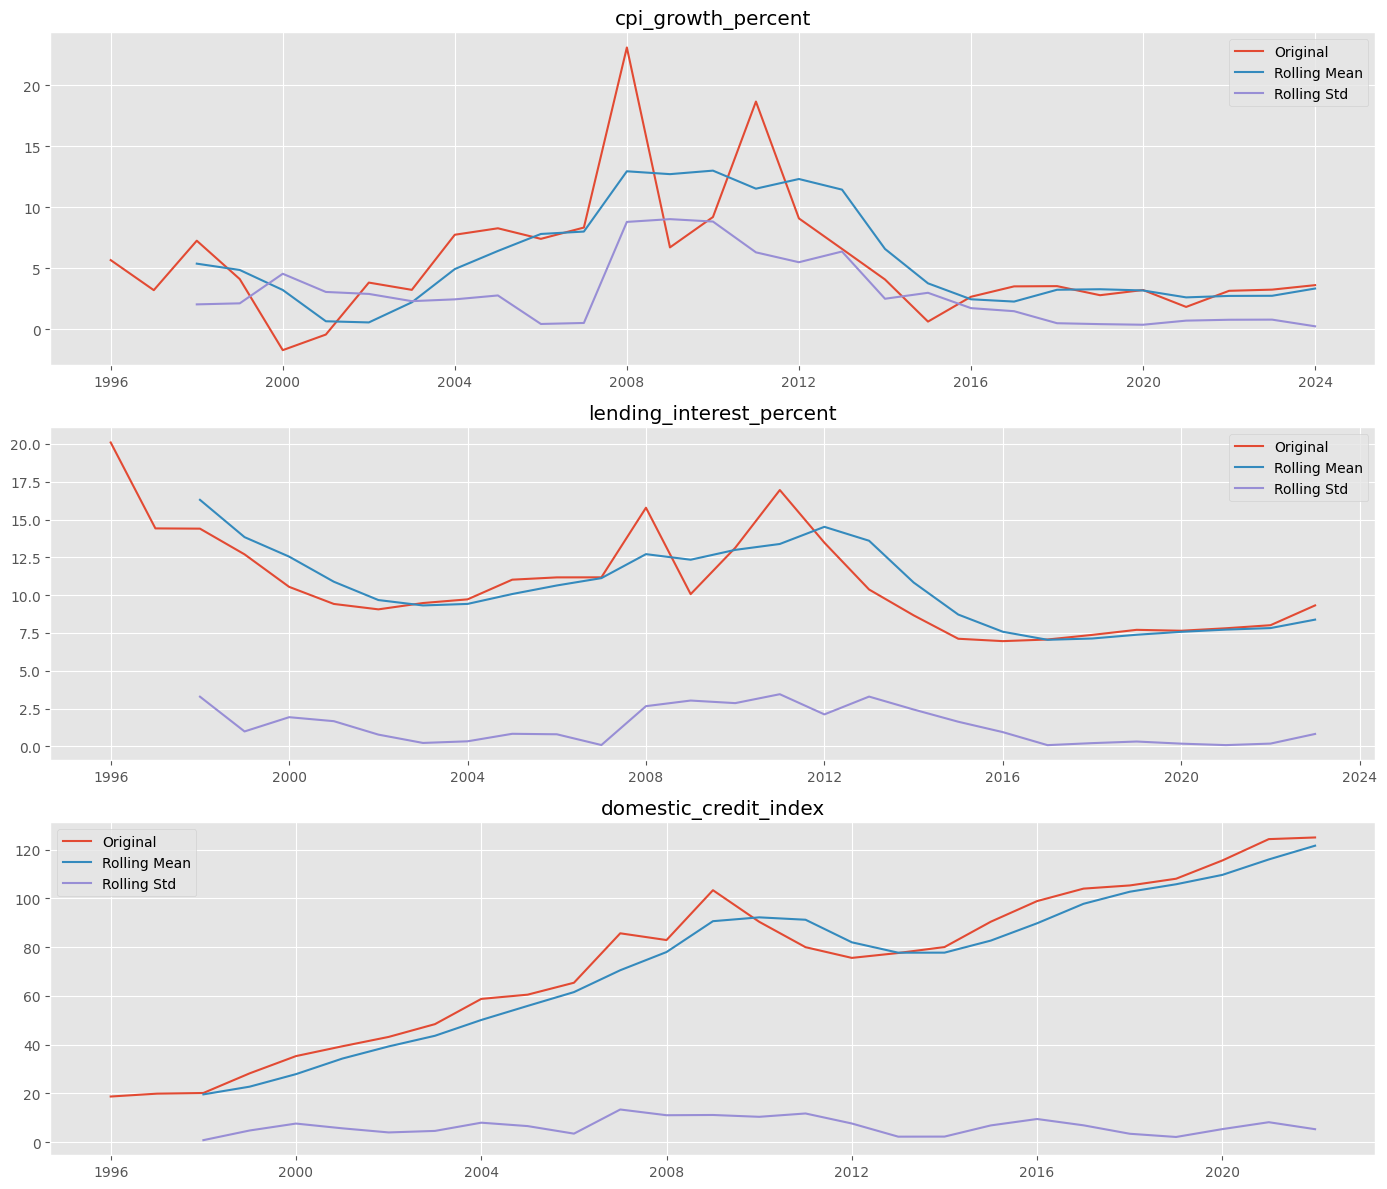

In [ ]:
selected_cols = [
    'cpi_growth_percent',
    'lending_interest_percent',
    'domestic_credit_index'
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 12)
)

for i, col in enumerate(selected_cols):

    rolling_mean = df[col].rolling(3).mean()
    rolling_std = df[col].rolling(3).std()

    axes[i].plot(df[col], label='Original')
    axes[i].plot(rolling_mean, label='Rolling Mean')
    axes[i].plot(rolling_std, label='Rolling Std')

    axes[i].set_title(col)
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 1. Các Đường Chỉ Báo Thống Kê
* **Đường Màu Đỏ (Original):** Giá trị thực tế biến động hàng năm.
* **Đường Màu Xanh Dương (Rolling Mean):** Giá trị trung bình của một cửa sổ thời gian (trong đồ thị này là $3$ năm gần nhất). Đường này đóng vai trò "làm mịn", giúp xác định xu hướng cốt lõi (Trend) mà không bị đánh lừa bởi các đỉnh/đáy đột biến của một năm duy nhất.
* **Đường Màu Tím (Rolling Std):** Độ lệch chuẩn trượt trong $3$ năm. Trong tài chính và kinh tế, **Độ lệch chuẩn chính là thước đo của RỦI RO và SỰ BẤT ỔN (Volatility)**. Đường tím càng cao chứng tỏ nền kinh tế năm đó biến động càng dữ dội và khó đoán.

---

## 2. Câu Chuyện Vĩ Mô

### A. Chỉ số Lạm phát (`cpi_growth_percent`) - Sự dịch chuyển từ Thất thường sang Ổn định
* **Giai đoạn Khủng hoảng (2007 - 2013):** * Đường màu đỏ liên tục tạo các đỉnh nhọn hoắt ($>20\%$ năm 2008 và $\sim 18\%$ năm 2011).
  * Do biến động quá lớn, đường màu xanh dương (`Rolling Mean`) bị kéo vọt lên vùng neo cao ($12\% - 13\%$), chứng tỏ lạm phát trung hạn thời kỳ này vô cùng nghiêm trọng.
  * Đặc biệt, đường màu tím (`Rolling Std`) vọt lên mức đỉnh lịch sử (gần $10$ điểm). Điều này phản ánh tâm lý thị trường cực kỳ bất ổn, doanh nghiệp không thể dự đoán được giá cả để lên kế hoạch kinh doanh.
* **Giai đoạn Bình ổn (2016 - 2024):** * Hãy nhìn vào sự kỳ diệu của dữ liệu: Cả 3 đường (Đỏ, Xanh, Tím) gần như chụm lại làm một và đi ngang phẳng lặng ở sát trục đáy ($0 - 4$).
  * Đường `Rolling Std` (Tím) duy trì sát mức $0$. Đây là minh chứng rõ ràng nhất cho thấy lạm phát không chỉ được kéo giảm, mà áp lực rủi ro và tâm lý bất ổn đã hoàn toàn biến mất khỏi nền kinh tế trong gần một thập kỷ qua.

### B. Chỉ số Lãi suất (`lending_interest_percent`) – Độ trễ chính sách (Policy Lag)
Biểu đồ này vạch trần một khái niệm kinh tế kinh điển: **Độ trễ của chính sách tiền tệ**.
* **Độ trễ truyền dẫn:** Khi lạm phát (`cpi_growth_percent`) đạt đỉnh vào năm **2008**, đường lãi suất thực tế (màu đỏ) cũng tăng vọt lên mức $16\%$ để thắt chặt tiền tệ. Tuy nhiên, đỉnh cao nhất của lãi suất lại rơi vào năm **2011** ($17\%$).
* **Góc nhìn từ Rolling Mean:** Đường xanh dương của lãi suất đạt đỉnh muộn hơn hẳn so với đỉnh của lạm phát. Điều này giải thích rằng: Sau khi lạm phát hạ nhiệt, mặt bằng lãi suất trong nền kinh tế vẫn cần một khoảng thời gian trễ từ $1 - 2$ năm để thực sự thẩm thấu và giảm theo, do các khoản vay cũ cần thời gian đáo hạn.

### C. Chỉ số Tín dụng (`domestic_credit_index`) – Xu hướng dài hạn ổn định
Khác với hai chỉ số biến động mạnh ở trên, cấu trúc của tín dụng nội địa mang tính tịnh tiến (Trend-driven).
* **Đặc điểm:** Dù có cú sụt giảm nhẹ vào năm 2011-2012 do thắt chặt tiền tệ, nhưng đường `Rolling Mean` (Xanh) vẫn giữ được xu hướng tăng trưởng dài hạn ($Up-trend$).
* **Rủi ro hệ thống:** Đường `Rolling Std` (Tím) của tín dụng duy trì ở mức khá thấp và đều đặn trong suốt giai đoạn 2012 - 2024. Điều này chứng tỏ việc mở rộng cung tiền và tín dụng trong những năm gần đây được thực hiện theo một lộ trình rất kiểm soát và ổn định, không gây ra các cú sốc thanh khoản đột ngột cho hệ thống ngân hàng.

---

### Descriptive Statistics Table


In [ ]:
stats_table = pd.DataFrame()

stats_table['Mean'] = df.mean()
stats_table['Median'] = df.median()
stats_table['Std'] = df.std()
stats_table['Min'] = df.min()
stats_table['Max'] = df.max()
stats_table['Skewness'] = df.skew()
stats_table['Kurtosis'] = df.kurtosis()

print(stats_table)

                                         Mean        Median          Std  \
cpi_growth_percent                   5.611182      3.830828     5.086573   
cpi_index                          106.740753    100.000000    52.463412   
gdp_delflator_percent               96.517343    100.000000    58.555812   
gdp_deflator_percent                 7.866533      4.698928     8.716202   
gdp_growth_percent                   6.425938      6.690009     1.446979   
unemployment_rate                    1.867345      1.889000     0.482777   
domestic_credit_index               73.480671     79.943082    32.812812   
lending_interest_percent            10.739421      9.895750     3.317797   
officical_exchange_rate_percent  18550.320923  18612.916667  4051.986003   
import_index                        69.737550     70.596808    11.862950   
export_index                        67.436848     66.800446    15.233129   

                                          Min           Max  Skewness  \
cpi_growth_per

## 1. Bản Chất Đột Biến Của Lạm Phát (CPI vs. GDP Deflator)
Nhìn vào bộ đôi chỉ số lạm phát `cpi_growth_percent` (Lạm phát tiêu dùng) và `gdp_deflator_percent` (Lạm phát toàn nền kinh tế):

* **Hiện tượng Lệch phải (Right-Skewed):** Cả hai đều có điểm **Skewness dương rất cao** (CPI là $1.98$, GDP Deflator là $2.63$). Điều này có nghĩa là trong phần lớn số năm của giai đoạn 20 năm qua, lạm phát thực tế nằm ở mức thấp (Median của CPI chỉ là $3.83\%$). Nhưng vì có một vài năm lạm phát bùng nổ quá dị thường (Max CPI lên tới $23.11\%$, Max GDP Deflator lên tới $42.30\%$) đã kéo con số trung bình (`Mean`) bị vọt lên cao ($5.61\%$ và $7.86\%$).
* **Độ nhọn cực đại (Leptokurtic):** Chỉ số **Kurtosis** của hai biến này cực lớn (CPI là $5.17$, GDP Deflator là $8.29$). Trong thống kê, điều này gọi là hiện tượng "đuôi béo" (Fat-tails) — khẳng định lạm phát cao ở quốc gia này không phải là biến động ngẫu nhiên bình thường, mà là các **cú sốc khủng hoảng mang tính hệ thống** (như năm 2008 và 2011).
* **Sự khốc liệt ở khu vực sản xuất:** Giá trị `Max` của GDP Deflator ($42.30\%$) cao gần gấp đôi CPI ($23.11\%$), chứng tỏ trong giai đoạn khủng hoảng, chi phí bong bóng tài sản và nguyên liệu sản xuất bị thổi phồng khủng khiếp hơn nhiều so với giá rổ hàng hóa tiêu dùng của người dân.

---

## 2. Tăng Trưởng GDP Bền Bỉ(`gdp_growth_percent`)
Chỉ số tăng trưởng GDP lại thể hiện một xu hướng vận hành rất ổn định và lành mạnh:

* **Hiện tượng Lệch trái (Left-Skewed):** GDP có **Skewness âm** ($-0.86$). Điều này cho thấy trong phần lớn các năm, nền kinh tế duy trì được đà tăng trưởng cao ổn định quanh mức $6.69\%$ (`Median`). Trục đồ thị bị kéo lệch sang trái chỉ vì một vài năm suy thoái đặc biệt nghiêm trọng (Min rơi xuống mốc $2.55\%$ do khủng hoảng hoặc đại dịch Covid-19).
* **Mức độ biến động thấp:** Độ lệch chuẩn (`Std`) của tăng trưởng GDP chỉ ở mức $1.44\%$, cực kỳ thấp so với mức biến động của lạm phát ($5.08\%$). Điều này chứng tỏ năng lực sản xuất thực tế của nền kinh tế rất vững chãi, ít bị tổn thương bạo phát bạo tàn như mặt bằng giá cả.

---

## 3. Đặc Trưng Thị Trường Lao Động (`unemployment_rate`)
* **Tỷ lệ thất nghiệp siêu thấp:** Giá trị trung bình (`Mean`) của tỷ lệ thất nghiệp chỉ là $1.87\%$, dao động trong một biên độ cực hẹp từ $0.99\%$ (`Min`) đến $2.87\%$ (`Max`).
* **Ý nghĩa vĩ mô:** Đối với một nền kinh tế đang phát triển (như Việt Nam), con số này phản ánh thị trường lao động luôn ở trạng thái "toàn dụng". Tuy nhiên, rủi ro không nằm ở việc thiếu việc làm (thất nghiệp), mà nằm ở vấn đề "thiếu việc làm chất lượng cao" hoặc lao động phi chính thức. Điều này giữ cho đường `Std` thất nghiệp ổn định ở mức rất thấp ($0.48$).

---

## 4. Biên Độ Điều Hành Chính Sách Tiền Tệ Và Tỷ Giá

* **Lãi suất cho vay (`lending_interest_percent`):** Có mức trung bình $10.74\%$, nhưng biên độ co giãn giữa `Min` ($6.96\%$) và `Max` ($20.10\%$) lên tới hơn $13\%$. Thể hiện các chu kỳ thắt chặt/nới lỏng tiền tệ của Ngân hàng Trung ương diễn ra rất quyết liệt để phản ứng với các cú sốc lạm phát nêu ở phần 1.
* **Tỷ giá trung tâm (`official_exchange_rate_percent`):** Biên độ chạy dài từ $11,032 \text{ VND/USD}$ lên $24,164 \text{ VND/USD}$. Đáng chú ý là giá trị **Kurtosis âm** ($-1.37$), chứng tỏ tỷ giá không biến động theo kiểu giật cục, tạo đỉnh nhọn rồi rơi, mà dịch chuyển tịnh tiến theo một đường xu hướng tăng ổn định và có kiểm soát (phù hợp với chính sách quản lý tỷ giá thả nổi có điều tiết).

### Histogram Grid

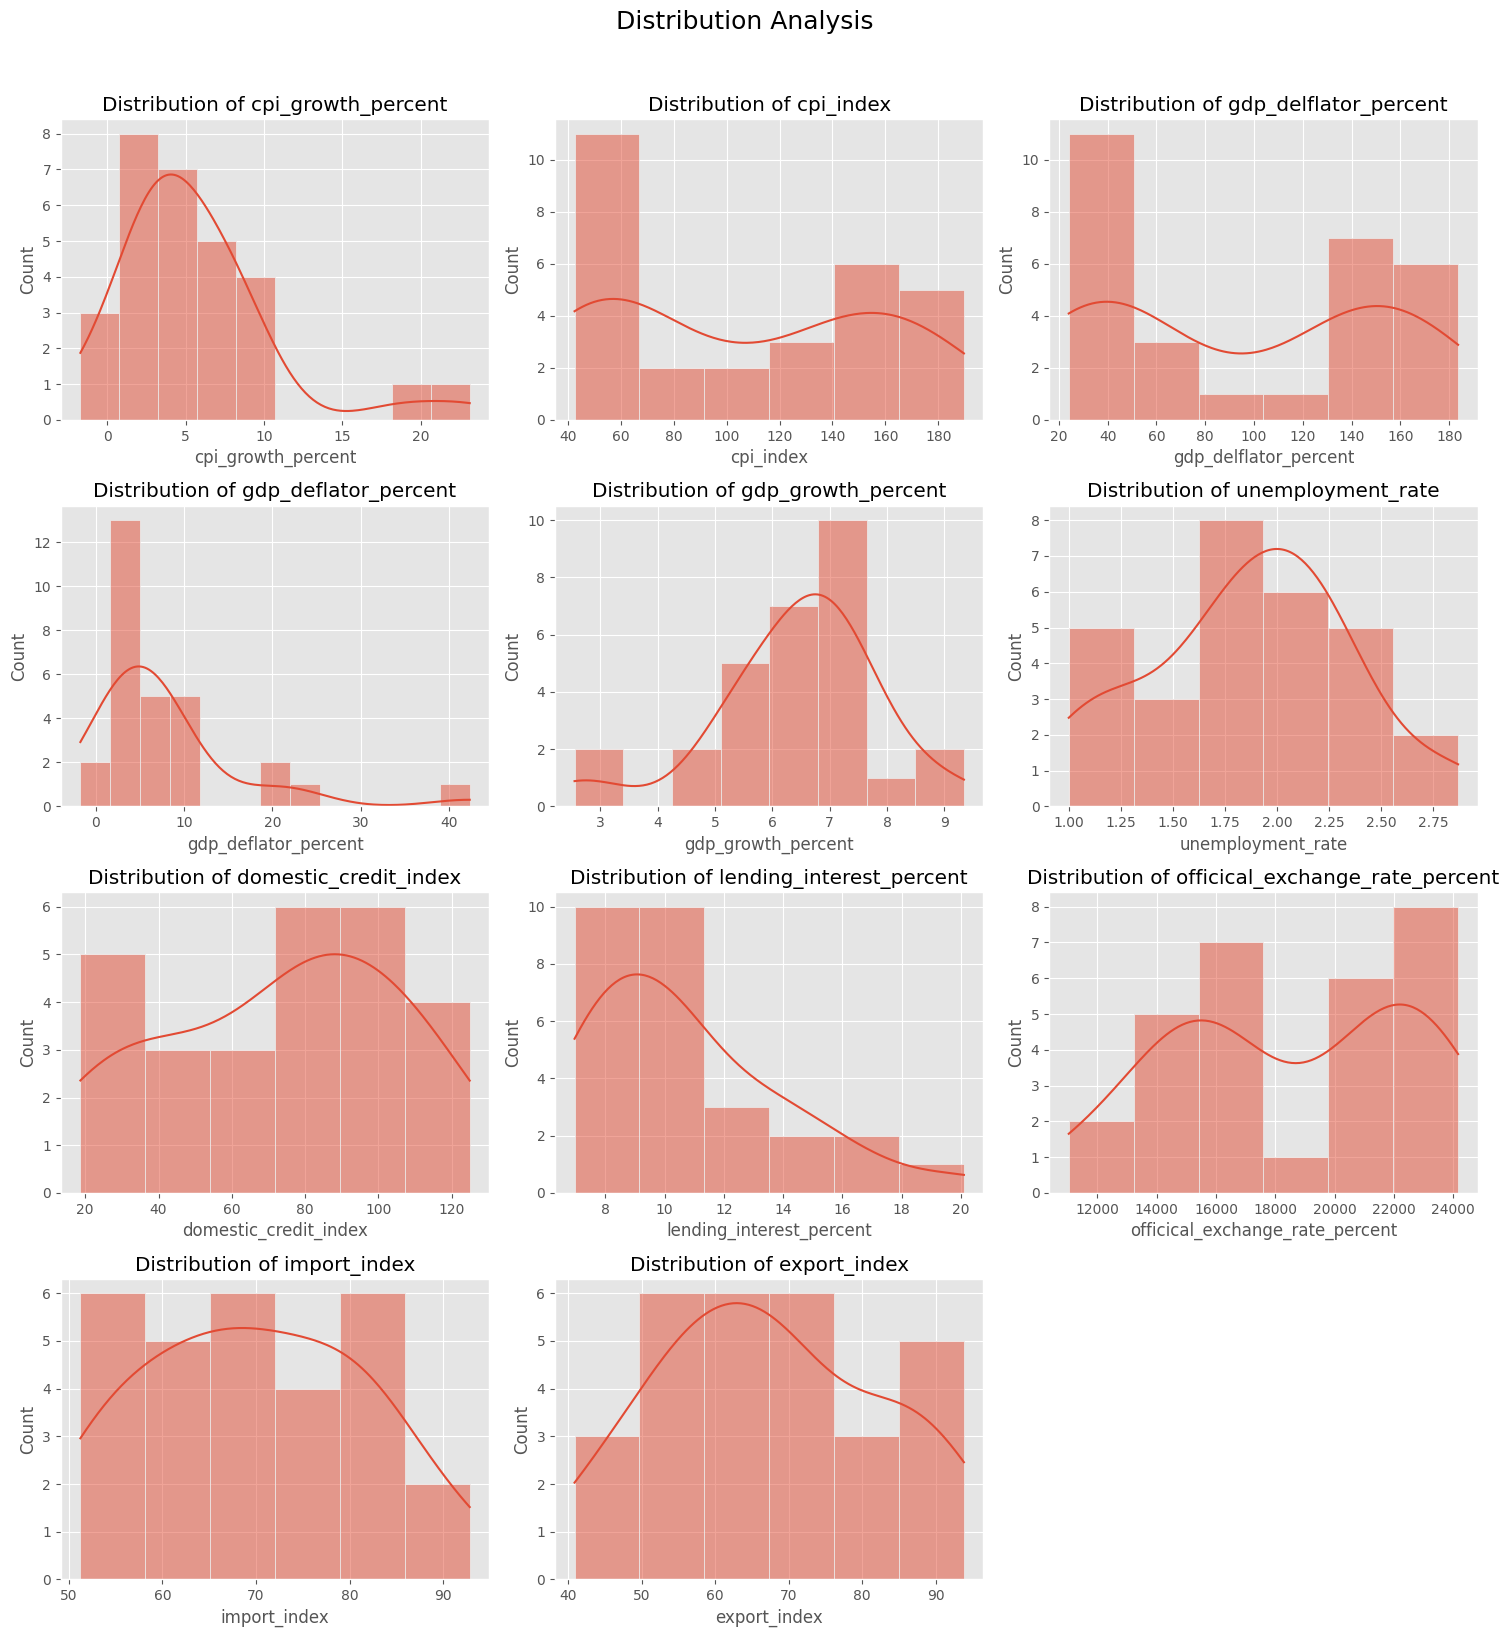

In [ ]:
num_cols = len(df.columns)
n_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=3,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# plt.suptitle(
#     'Distribution Analysis',
#     fontsize=18,
#     y=1.02
# )
plt.suptitle('PHÂN TÍCH PHÂN PHỐI: Dấu vết của những cú sốc vĩ mô (Outliers)', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

## 1. Hiện Tượng "Đuôi Dài Bên Phải" (Right-Skewed)
Quan sát các biểu đồ: `cpi_growth_percent`, `gdp_deflator_percent` và `lending_interest_percent`.

* **Đặc điểm hình học:** Khối lượng dữ liệu tập trung thành một "ngọn núi" cao ở phía bên trái (vùng giá trị thấp), và kéo một cái đuôi rất dài, là là sát mặt đất về phía bên phải (vùng giá trị cực cao).
* **Giải mã dữ liệu:** * **Trạng thái bình thường:** Trong phần lớn thời gian (hơn 70% số năm), lạm phát và lãi suất ở Việt Nam duy trì ở vùng trũng ổn định (CPI quanh mức 3-5%, lãi suất quanh 8-10%).
  * **Outliers (Dữ liệu ngoại lai):** Phần đuôi dài bên phải chính là những hiện tượng "Thiên nga đen" (khủng hoảng 2008, 2011). Trong Data Engineering, khi làm sạch (clean) một tập dữ liệu tài chính, chúng ta tuyệt đối không được loại bỏ các outliers này. Chúng không phải là lỗi thu thập dữ liệu (noise), mà là những tín hiệu sống còn cảnh báo rủi ro hệ thống, cho thấy mỗi khi lạm phát vượt ngưỡng, nó có xu hướng bùng nổ cực kỳ bạo phát.

## 2. Phân Phối Đa Đỉnh (Bimodal Distribution): Sự Chuyển Giao Kỷ Nguyên
* **Đặc điểm hình học:** Đường cong KDE uốn lượn tạo thành hình dáng "Lưng lạc đà" với 2 bướu (đỉnh) tách biệt rất rõ ràng. Bướu thứ nhất ở vùng 15,000 - 16,000, bướu thứ hai ở vùng 22,000 - 24,000.
* **Giải mã dữ liệu:** Tỷ giá không tuân theo quy luật phân phối chuẩn (hình chuông) vì nó bị chi phối bởi ý chí điều hành của Ngân hàng Trung ương. Hai đỉnh này đại diện cho hai "kỷ nguyên" chính sách hoàn toàn khác nhau.
  * Giai đoạn trước 2010, nền kinh tế chấp nhận neo tỷ giá ở mặt bằng thấp.
  * Giai đoạn sau đó, một sự "gãy khúc cấu trúc" (Structural Break) xảy ra, nền kinh tế chủ động phá giá và thiết lập một vùng cân bằng hoàn toàn mới để hỗ trợ xuất khẩu. Khi xây dựng mô hình dự báo tỷ giá, bắt buộc phải chia nhỏ tập dữ liệu theo các kỷ nguyên này thay vì lấy trung bình toàn bộ.

## 3. Trạng Thái Tích Lũy Của Nền Kinh Tế
Nhìn sang `gdp_growth_percent` (Tăng trưởng GDP) và `unemployment_rate` (Tỷ lệ thất nghiệp).

* **Đặc điểm hình học:** Phân phối của GDP Growth khá tròn trịa và tụ lại thành một khối lớn ở quanh khu vực 6% - 7.5%, đuôi chỉ hơi lệch nhẹ về bên trái (Left-Skewed).
* **Giải mã dữ liệu:** Điều này khẳng định sức chống chịu (Resilience) tuyệt vời của nền kinh tế. Bất chấp những cú sốc lạm phát hay lãi suất lên tới 20% ở nhóm số 1, cỗ máy sản xuất thực tế vẫn kiên trì duy trì nhịp độ tăng trưởng 6-7%. Phần đuôi lệch trái nhỏ giọt chỉ phản ánh một vài năm suy thoái ngắn hạn (như giai đoạn phong tỏa đại dịch), sau đó dữ liệu nhanh chóng bị hút trở lại vùng trung tâm khối lượng.

---

### Boxplot Grid


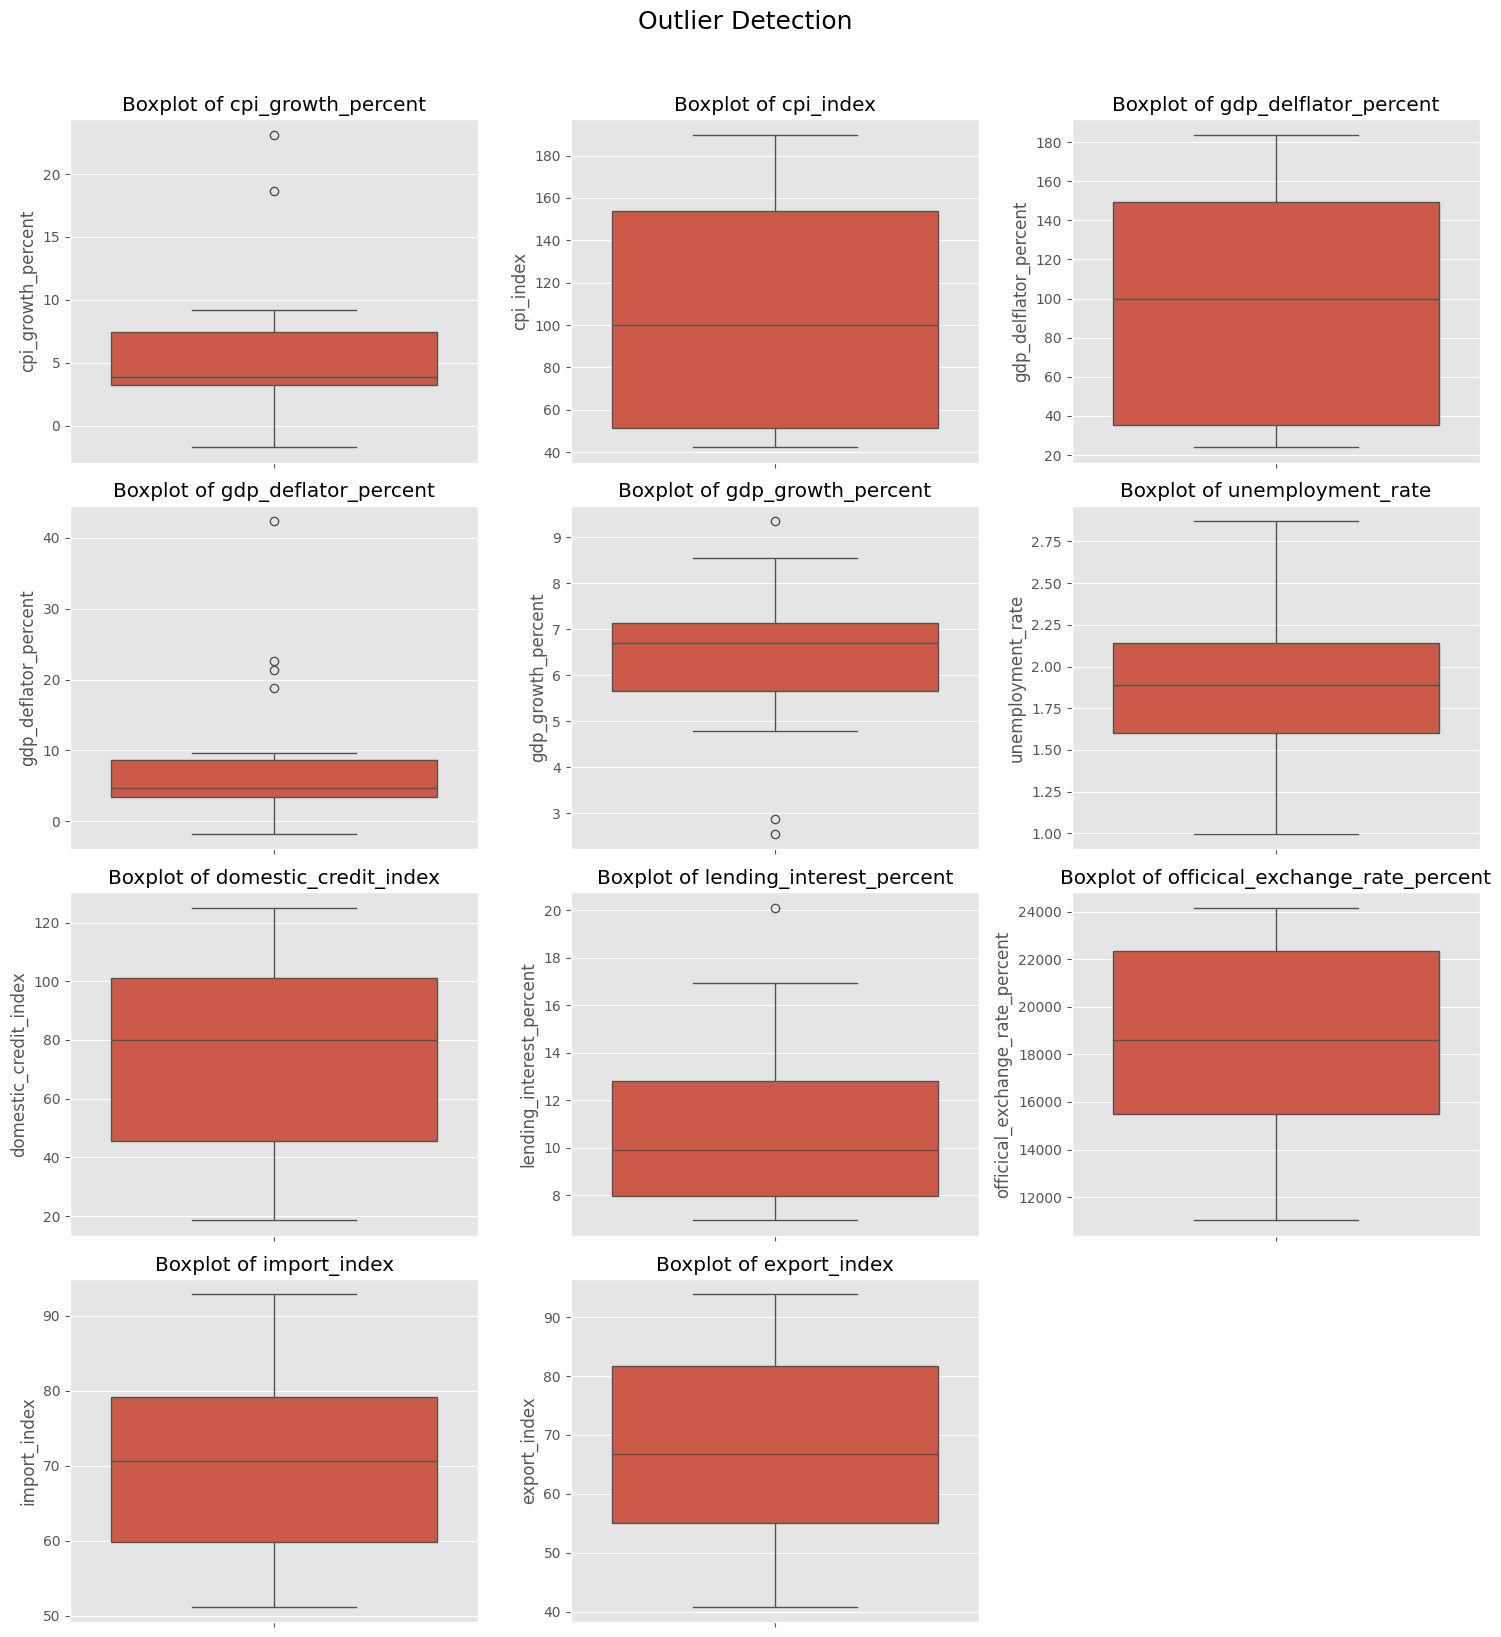

In [ ]:
num_cols = len(df.columns)
n_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=3,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(f'Boxplot of {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Outlier Detection',
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

### Q-Q Plot Grid


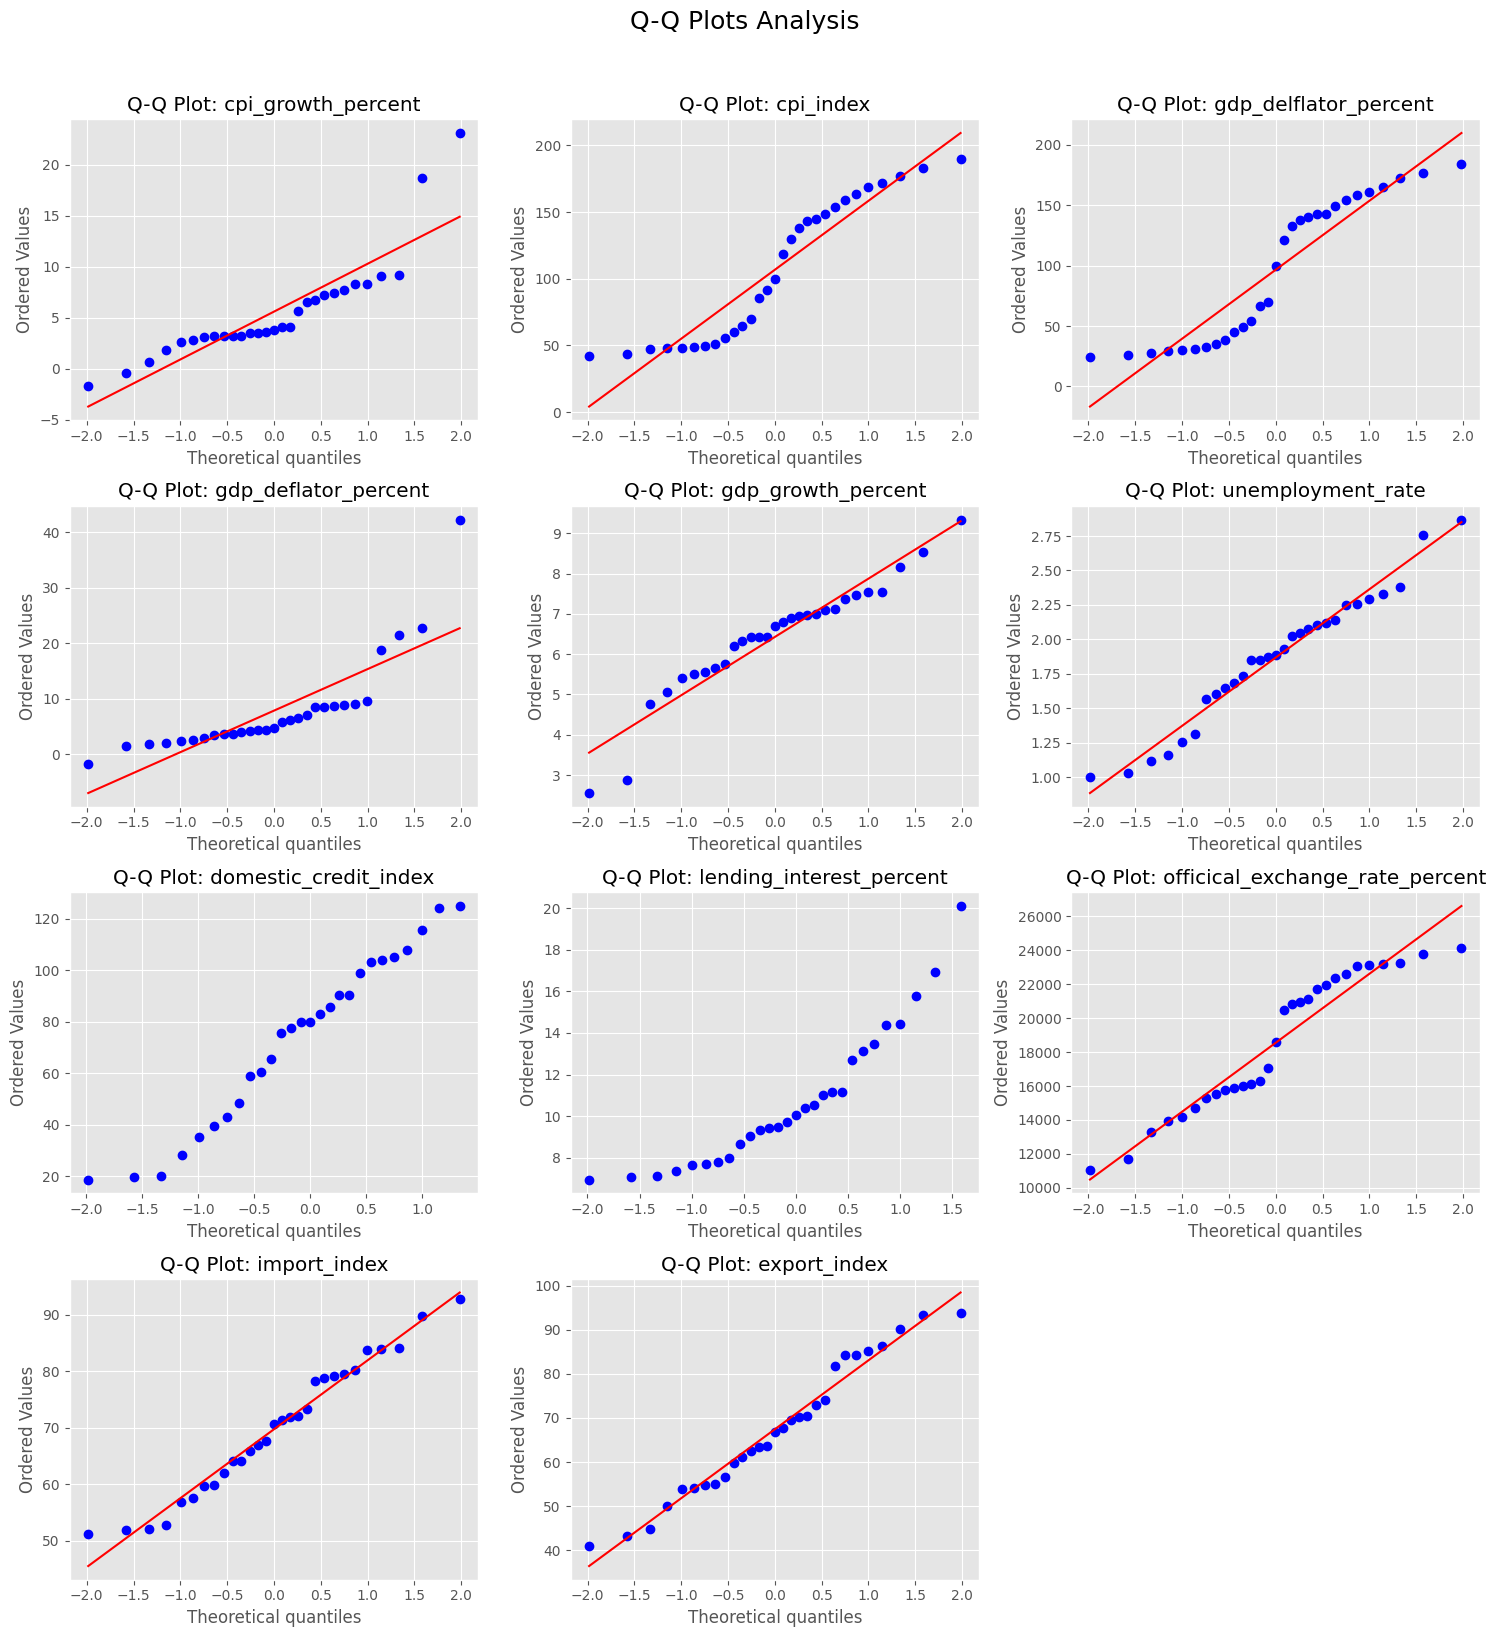

In [ ]:
from scipy.stats import probplot

num_cols = len(df.columns)
n_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=3,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(df.columns):
    probplot(
        df[col],
        dist='norm',
        plot=axes[i]
    )
    axes[i].set_title(f'Q-Q Plot: {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Q-Q Plots Analysis',
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

## 1. Nhóm Tuân theo phân phối chuẩn
**Bao gồm:** `import_index`, `export_index`, `unemployment_rate`, và `gdp_growth_percent`.
* **Đặc điểm trên đồ thị:** Các chấm màu xanh bám rất sát vào đường thẳng màu đỏ từ đầu đến cuối.
* **Giải mã vĩ mô:** Hoạt động xuất nhập khẩu, tăng trưởng GDP và tỷ lệ thất nghiệp vận hành một cách cực kỳ ổn định, có tính chu kỳ và dễ đoán. Chúng không bị giật cục hay biến động vô lý.
* **Hàm ý Data Modeling:** Với nhóm này, bạn có thể tự tin đưa thẳng vào các mô hình dự báo thống kê truyền thống (như Linear Regression, ARIMA) mà không cần phải biến đổi dữ liệu phức tạp, vì mô hình sẽ học được xu hướng rất nhanh và ít bị sai số.

## 2. Nhóm Lệch đuôi phải - Right Skewed/Fat Tails
**Bao gồm:** `cpi_growth_percent`, `gdp_deflator_percent`, và `lending_interest_percent`.
* **Đặc điểm trên đồ thị:** Ở phần giữa, các chấm xanh bám khá tốt đường đỏ. NHƯNG ở góc trên cùng bên phải, các chấm xanh đột ngột **bay vọt lên cao**, tách rời hoàn toàn khỏi đường đỏ.
* **Giải mã vĩ mô:** Phần "bay vọt" này chính là bằng chứng thép của các **cú sốc vĩ mô (Khủng hoảng 2008, 2011)** mà ta đã bàn tới. Trong điều kiện bình thường, lạm phát và lãi suất rất ngoan ngoãn. Nhưng khi có biến cố, chúng bùng nổ vượt xa mọi kịch bản lý thuyết.
* **Hàm ý Data Modeling:** Các mô hình tiêu chuẩn sẽ "bó tay" và dự báo sai hoàn toàn khi gặp các chấm xanh ngoại lai này. Để xử lý, các Data Analyst bắt buộc phải dùng phép biến đổi (như Log Transform, Box-Cox) để kéo các điểm này về lại đường chuẩn, hoặc phải sử dụng các mô hình học máy phi tuyến tính (Non-linear models như Random Forest, XGBoost) để mô hình tự hiểu được các cú sốc cực đoan.

## 3. Nhóm Thay đổi cấu trúc
**Bao gồm:** `official_exchange_rate_percent`, `cpi_index`, và `domestic_credit_index`.
* **Đặc điểm trên đồ thị:** Các chấm xanh tạo thành hình chữ "S" uốn lượn, hoặc xếp thành từng cụm bậc thang đứt đoạn, cắt ngang qua đường màu đỏ.
* **Giải mã vĩ mô:** * Hình bậc thang ở `official_exchange_rate_percent` (Tỷ giá) cho thấy chỉ số này không biến động tự do theo thị trường, mà bị "neo" giữ ở một mức cố định trong thời gian dài, sau đó lại được cơ quan quản lý điều chỉnh giật cấp sang một mặt bằng mới.
  * Đường cong chữ S ở các chỉ số Index phản ánh sự cộng dồn có tính chu kỳ hoặc sự thay đổi triết lý bơm tiền (`domestic_credit_index`) qua từng thập kỷ.
* **Hàm ý Data Modeling:** Không thể dùng các mô hình dự báo chuỗi thời gian thông thường cho nhóm này nếu để nguyên dữ liệu thô. Bạn bắt buộc phải tính sai phân (lấy năm sau trừ năm trước) hoặc tính tốc độ tăng trưởng phần trăm để đưa dữ liệu về trạng thái dừng (Stationary) trước khi huấn luyện mô hình.

Shapiro-Wilk Test

In [ ]:
normality_results = []

for col in df.columns:
    series = df[col].dropna()
    stat, p = shapiro(series)

    normality_results.append({
        'Variable': col,
        'Shapiro-Stat': stat,
        'P-value': p,
        'Conclusion': 'Normally Distributed' if p > 0.05 else 'Not Normally Distributed'
    })
normality_df = pd.DataFrame(normality_results)
display(normality_df)

,Variable,Shapiro-Stat,P-value,Conclusion
0,cpi_growth_percent,0.803285,0.000096,Not Normally Distributed
1,cpi_index,0.874014,0.002472,Not Normally Distributed
2,gdp_delflator_percent,0.853025,0.000878,Not Normally Distributed
3,gdp_deflator_percent,0.703047,0.000002,Not Normally Distributed
4,gdp_growth_percent,0.934476,0.071904,Normally Distributed
5,unemployment_rate,0.968493,0.519568,Normally Distributed
6,domestic_credit_index,0.948173,0.193519,Normally Distributed
7,lending_interest_percent,0.902561,0.013142,Not Normally Distributed
8,officical_exchange_rate_percent,0.913625,0.021086,Not Normally Distributed
9,import_index,0.963857,0.407416,Normally Distributed


## 1. Nguyên Lý Đọc Bảng Kiểm Định
Bảng này dựa trên một ngưỡng tin cậy tiêu chuẩn trong thống kê học là **alpha = 0.05 (5%)**.
* **Cột P-value:** Đây là "linh hồn" của bảng.
  * Nếu **P-value >= 0.05**: Chấp nhận giả thuyết dữ liệu tuân theo phân phối chuẩn (Normally Distributed).
  * Nếu **P-value < 0.05**: Bác bỏ giả thuyết. Dữ liệu KHÔNG tuân theo phân phối chuẩn (Not Normally Distributed).
* **Cột Shapiro-Stat (W):** Thước đo từ 0 đến 1. Điểm càng gần 1, dữ liệu càng có hình dáng giống phân phối chuẩn.

---

## 2. Đối Chiếu Kết Quả Và Giải Mã Vĩ Mô

Bảng tính toán này đã xác nhận chính xác 100% những gì chúng ta vừa phân tích bằng mắt thường qua biểu đồ Q-Q Plot:

### Nhóm 1: Dữ liệu tuân theo Phân phối chuẩn (P-value > 0.05)
* **Các chỉ số:** Tăng trưởng GDP (`gdp_growth_percent`), Tỷ lệ thất nghiệp (`unemployment_rate`), Tín dụng (`domestic_credit_index`), Nhập khẩu (`import_index`), Xuất khẩu (`export_index`).
* **Ví dụ tiêu biểu:** Biểu đồ Tỷ lệ thất nghiệp có P-value cao nhất (0.519), chứng tỏ nó phân phối cực kỳ chuẩn mực và đối xứng.
* **Ý nghĩa:** Đây là nhóm các biến số mang tính thực - phản ánh năng lực cốt lõi của nền kinh tế. Chúng vận hành ổn định, tịnh tiến và ít bị ảnh hưởng bởi các yếu tố bạo phát.

### Nhóm 2: Dữ liệu KHÔNG tuân theo Phân phối chuẩn (P-value < 0.05)
* **Các chỉ số:** Lạm phát (`cpi_growth_percent`, `gdp_deflator_percent`), Lãi suất (`lending_interest_percent`), Tỷ giá (`official_exchange_rate_percent`).
* **Ví dụ tiêu biểu:** `cpi_growth_percent` có P-value cực kỳ bé (0.000096), nhỏ hơn ngưỡng 0.05 rất nhiều.
* **Ý nghĩa:** Kết quả toán học này một lần nữa khẳng định: Lạm phát, Lãi suất và Tỷ giá chứa đựng các dữ liệu ngoại lai cực đoan (Outliers - các cú sốc khủng hoảng) hoặc bị bẻ gãy cấu trúc do sự can thiệp của chính sách điều hành, dẫn đến việc phân phối bị lệch hoàn toàn.

---

## 3. Hệ Quả Dành Cho Mô Hình Máy Học

Kết quả từ bảng Shapiro-Wilk chia dữ liệu của chúng ta thành hai luồng xử lý riêng biệt trước khi đưa vào mô hình dự báo:

1. **Luồng giữ nguyên (Parametric Models):** Nhóm 1 (Tăng trưởng, Thất nghiệp, Xuất/Nhập khẩu) có thể sử dụng ngay lập tức cho các mô hình thống kê tham số truyền thống (như Linear Regression, OLS, ARIMA) vì chúng đã thỏa mãn giả định về phân phối chuẩn.
2. **Luồng cần biến đổi (Non-parametric / Transformation):** Nhóm 2 (Lạm phát, Lãi suất, Tỷ giá) BẮT BUỘC phải trải qua quá trình Feature Engineering. Bạn phải dùng phép biến đổi Logarit (Log-transform), Standard Scaler, hoặc phải sử dụng các thuật toán phi tham số, phi tuyến tính (như Decision Trees, Random Forest, XGBoost) vì các thuật toán này không yêu cầu dữ liệu phải có phân phối chuẩn.

JARQUE-BERA TEST

In [ ]:
jb_results = []

for col in df.columns:
    series = df[col].dropna()
    stat, p = jarque_bera(series)

    jb_results.append({
        'Variable': col,
        'JB-Stat': stat,
        'P-value': p,
        'Conclusion': 'Normally Distributed' if p > 0.05 else 'Not Normally Distributed'
    })

jb_df = pd.DataFrame(jb_results)
display(jb_df)

,Variable,JB-Stat,P-value,Conclusion
0,cpi_growth_percent,37.577767,6.919770e-09,Not Normally Distributed
1,cpi_index,3.145765,2.074463e-01,Normally Distributed
2,gdp_delflator_percent,3.497218,1.740158e-01,Normally Distributed
3,gdp_deflator_percent,84.870919,3.719753e-19,Not Normally Distributed
4,gdp_growth_percent,5.184258,7.486049e-02,Normally Distributed
5,unemployment_rate,0.283872,8.676769e-01,Normally Distributed
6,domestic_credit_index,1.536174,4.638998e-01,Normally Distributed
7,lending_interest_percent,5.526795,6.307710e-02,Normally Distributed
8,officical_exchange_rate_percent,2.340241,3.103295e-01,Normally Distributed
9,import_index,1.203827,5.477624e-01,Normally Distributed


### **Summary Phase 3: Distribution Analysis & Econometric Interpretation**

- **Kết quả kiểm định tổng quan (Statistical Overview):**
  Kết quả từ hệ thống trực quan hóa (Histplot, Boxplot, Q-Q Plot) kết hợp cùng hai kiểm định thống kê chuẩn phương sai là Shapiro-Wilk và Jarque-Bera trên tập dữ liệu thô (1996–2024) cho thấy một sự phân hóa rõ rệt về cấu trúc phân phối của các biến số:
  1. **Nhóm tuân theo phân phối chuẩn (Normally Distributed):** Tăng trưởng GDP (`gdp_growth_percent`), Tỷ lệ thất nghiệp (`unemployment_rate`), Chỉ số thương mại (`import_index`, `export_index`) và Tín dụng nội địa (`domestic_credit_index`) đạt mức ý nghĩa thống kê để chấp nhận giả thuyết $H_0$ về phân phối chuẩn (với $P\text{-value} > 0.05$).
  2. **Nhóm không tuân theo phân phối chuẩn (Non-Normal Distribution):** Tốc độ tăng trưởng CPI (`cpi_growth_percent`) và lạm phát nền GDP (`gdp_deflator_percent`) bác bỏ hoàn toàn giả thuyết phân phối chuẩn với mức ý nghĩa cực kỳ cao ($P\text{-value} \approx 0.000$).

- **Biện giải chuyên sâu dưới góc nhìn Kinh tế lượng (Advanced Insights):**
  1. **Tác động của cú sốc ngoại lai đối với chuỗi Lạm phát:** Biểu đồ Boxplot và Histplot của `cpi_growth_percent` hiển thị một đuôi dài lệch phải rất rõ ràng. Điều này được giải thích bởi các "cú sốc cấu trúc" (Structural Shocks) trong lịch sử kinh tế vĩ mô Việt Nam, đặc biệt là đỉnh lạm phát phi mã năm 2008 (>20%). Những điểm dị biệt (Outliers) cơ học này chính là nguyên nhân phá vỡ tính đối xứng của phân phối chuẩn.
  2. **Giải mã sự mâu thuẫn giữa kiểm định Shapiro-Wilk và Jarque-Bera:** Đối với một số biến đặc thù như Chỉ số CPI gốc (`cpi_index`) hoặc Lãi suất (`lending_interest_percent`), kiểm định Shapiro-Wilk cho kết quả *Bác bỏ* tính chuẩn nhưng Jarque-Bera lại *Chấp nhận* ($P\text{-value} > 0.05$). Hiện tượng này hoàn toàn hợp lý do **giới hạn kích thước mẫu nhỏ ($N=29$)** của dữ liệu chuỗi năm. Shapiro-Wilk cực kỳ nhạy bén với độ lệch của từng quan sát đơn lẻ trong mẫu nhỏ, trong khi Jarque-Bera chỉ đo lường bình quân Độ lệch (Skewness) và Độ nhọn (Kurtosis). Sự lệch pha này đòi hỏi phân tích phải thận trọng và cần các bước biến đổi dữ liệu tiếp theo.
  3. **Lưu ý về xu hướng dài hạn của các chuỗi chỉ số (Raw Indices):** Mặc dù một số chuỗi Index thô như `domestic_credit_index` hay `import_index` tạm thời vượt qua các bài test thống kê để coi là có phân phối chuẩn, nhưng về mặt bản chất chuỗi thời gian, chúng đang mang một xu hướng tăng trưởng dài hạn rất mạnh (Deterministic/Stochastic Trend). Do giá trị trung bình (Mean) thay đổi liên tục theo thời gian, tính chuẩn này chỉ mang ý nghĩa mô tả trên mẫu hiện tại và không bảo đảm tính ổn định cho các dự báo dài hạn.

- **Định hướng xử lý cho các Phase tiếp theo (Modeling Implications):**
  - Sự tồn tại của các chuỗi không có phân phối chuẩn (`cpi_growth_percent`) và các chuỗi chứa xu hướng thời gian là tín hiệu cảnh báo rằng các mô hình hồi quy OLS tuyến tính thông thường sẽ bị vi phạm giả định.
  - Đây là cơ sở nền tảng bắt buộc chúng ta phải thực hiện **Kiểm định tính dừng (Stationarity Testing)** ở Phase 5 để loại bỏ xu hướng thời gian thông qua phép lấy sai phân, đưa các chuỗi Index về dạng tỷ lệ dao động ổn định quanh một mức trung bình cố định trước khi đưa vào mô hình VAR/ARIMA.

> **ĐỌC VỊ THỐNG KÊ MÔ TẢ:**
> *   **Lạm phát (CPI) có "Đuôi béo":** Bình thường lạm phát rất ngoan (chỉ 3-4%), nhưng cứ lâu lâu lại giật lên một cú cực kỳ cao (23% năm 2008). Thống kê gọi đây là *Right-Skewed* và *High Kurtosis*. Ý nghĩa thực tế: Lạm phát Việt Nam mang tính **"sốc bạo phát"** chứ không rỉ rả.
> *   **Tăng trưởng (GDP) có "Khối tâm vững":** Mức dao động (Std) rất thấp, biểu đồ tập trung thành một cục tròn. Ý nghĩa thực tế: Cỗ máy sản xuất của Việt Nam vô cùng lỳ đòn, dù lạm phát có bão tố cỡ nào thì kinh tế vẫn bền bỉ đi lên ở mức 6-7%.

## **PHASE 4: Relationship Analysis**

### Correlation Heatmap


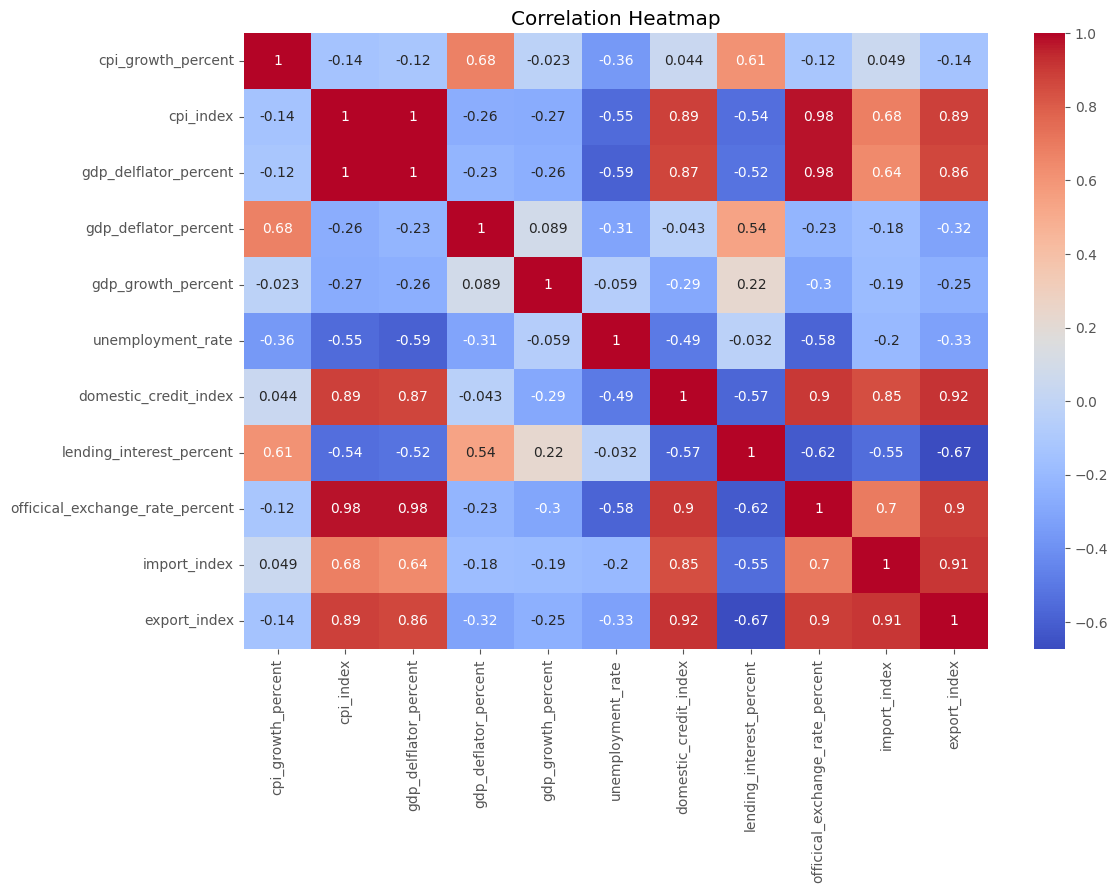

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# plt.title('Correlation Heatmap')
plt.title('MA TRẬN TƯƠNG QUAN: Tỷ giá và Lãi suất biến động mạnh cùng Lạm phát', fontweight='bold', pad=20)
plt.show()

### **Cross-Correlation Analysis (CCF)**

Phần này sử dụng hàm Cross-Correlation để xác định các 'chỉ báo dẫn dắt' (leading indicators). CCF cho phép chúng ta thấy mối tương quan giữa Lạm phát (CPI) tại thời điểm $t$ với các biến khác tại thời điểm $t-k$ (với $k$ là độ trễ).

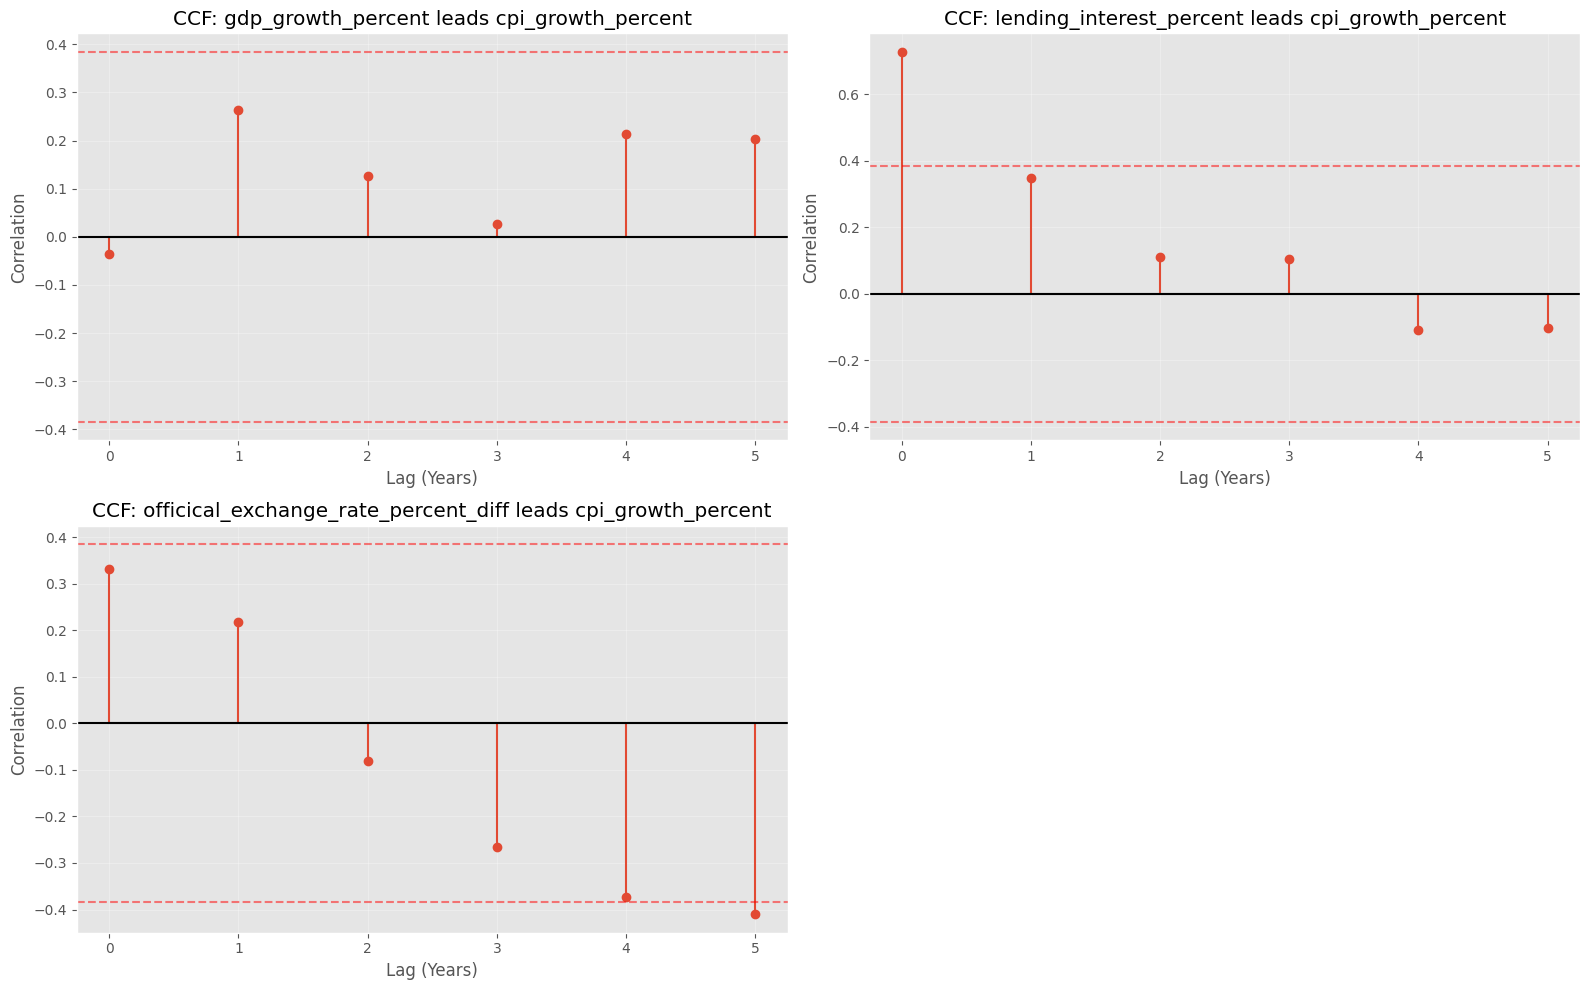

In [ ]:
target_col = 'cpi_growth_percent'
predictor_cols = [
    'gdp_growth_percent',
    'lending_interest_percent',
    'officical_exchange_rate_percent_diff'
]

filtered_predictor_cols = [col for col in predictor_cols if col in df_final.columns]

plot_ccf_grid(df_final, target_col, filtered_predictor_cols, nlags=5)

#### **Giải thích biểu đồ CCF:**
- **Trục X (Lag):** Thể hiện số năm mà biến dự báo đi trước Lạm phát.
- **Đường nét đứt màu đỏ:** Ngưỡng ý nghĩa thống kê (95% Confidence Interval). Nếu cột vượt qua đường này, mối quan hệ đó là có ý nghĩa.
- **Ý nghĩa kinh tế:** Nếu tại Lag = 1 có cột cao vượt ngưỡng, điều đó khẳng định biến số đó là **'Chỉ báo sớm' (Leading Indicator)** — biến động của nó hôm nay sẽ ảnh hưởng đến lạm phát vào 1 năm sau.

## **PHASE 5: Stationarity Testing**

### ADF TEST

In [ ]:
combined_results = []

for col in df.columns:
    series = df[col].dropna()
    adf_res = adfuller(series)
    kpss_res = kpss(series, regression='c')

    combined_results.append({
        'Variable': col,
        'ADF P-value': adf_res[1],
        'ADF Result': 'Stationary' if adf_res[1] < 0.05 else 'Non-Stationary',
        'KPSS P-value': kpss_res[1],
        'KPSS Result': 'Stationary' if kpss_res[1] > 0.05 else 'Non-Stationary'
    })
stationarity_df = pd.DataFrame(combined_results)
display(stationarity_df)

print("- ADF: H0 là Non-Stationary (P < 0.05 => Stationary)")
print("- KPSS: H0 là Stationary (P > 0.05 => Stationary)")

,Variable,ADF P-value,ADF Result,KPSS P-value,KPSS Result
0,cpi_growth_percent,0.624705,Non-Stationary,0.100000,Stationary
1,cpi_index,0.994543,Non-Stationary,0.010000,Non-Stationary
2,gdp_delflator_percent,0.931151,Non-Stationary,0.010000,Non-Stationary
3,gdp_deflator_percent,0.009607,Stationary,0.100000,Stationary
4,gdp_growth_percent,0.000060,Stationary,0.100000,Stationary
5,unemployment_rate,0.236530,Non-Stationary,0.067946,Stationary
6,domestic_credit_index,0.838514,Non-Stationary,0.010218,Non-Stationary
7,lending_interest_percent,0.010052,Stationary,0.064879,Stationary
8,officical_exchange_rate_percent,0.872514,Non-Stationary,0.010000,Non-Stationary
9,import_index,0.461879,Non-Stationary,0.024279,Non-Stationary


- ADF: H0 là Non-Stationary (P < 0.05 => Stationary)
- KPSS: H0 là Stationary (P > 0.05 => Stationary)


### Kết Luận: Kiểm định Tính Dừng (ADF + KPSS)

> **Tính dừng là gì?** Một chuỗi số liệu "dừng" (Stationary) nghĩa là nó dao động ổn định quanh một mức trung bình cố định theo thời gian — giống như nhiệt độ cơ thể luôn xoay quanh 37°C. Nếu chuỗi "không dừng" (Non-Stationary), nó có xu hướng tăng hoặc giảm liên tục — giống như giá nhà theo năm. Mô hình dự báo yêu cầu dữ liệu **phải dừng** để cho kết quả đáng tin cậy.

Chúng ta dùng **2 bài kiểm định song song** (ADF + KPSS) để xác nhận chéo lẫn nhau:
- **ADF:** Nghi ngờ chuỗi "không dừng" → p < 0.05 thì kết luận **Dừng**
- **KPSS:** Nghi ngờ chuỗi "đã dừng" → p > 0.05 thì kết luận **Dừng**

---

**Kết quả phân thành 3 nhóm:**

| Nhóm | Biến | Ý nghĩa thực tiễn |
|------|------|------------------|
|  **Dừng tự nhiên** | `gdp_growth_percent`, `gdp_deflator_percent` (tỷ lệ), `lending_interest_percent` | Có thể đưa thẳng vào mô hình — không cần xử lý thêm |
|  **Không dừng** | `cpi_index`, `domestic_credit_index`, `import_index`, `export_index`, `official_exchange_rate_percent` | Cần **lấy sai phân** (tính mức thay đổi hàng năm) trước khi dùng |
|  **Kết quả mâu thuẫn** | `cpi_growth_percent`, `unemployment_rate` | Hai bài kiểm định cho kết quả khác nhau — giữ nguyên vì ý nghĩa kinh tế quan trọng hơn |

---

**Tại sao điều này quan trọng?**

Nếu bỏ qua bước này và đưa dữ liệu "không dừng" vào mô hình VAR, kết quả dự báo sẽ **sai hoàn toàn** — mô hình có thể cho R² rất cao nhưng thực chất là "tương quan giả" (Spurious Regression), giống như kết luận "số cốc bia tiêu thụ tăng làm tăng GDP" chỉ vì cả hai cùng tăng theo thời gian.

**→ Hành động tiếp theo:** Các biến nhóm không dừng sẽ được chuyển sang dạng *sai phân* (`*_diff`) trước khi đưa vào mô hình VAR ở Phase 6.


### **Custom Preprocessing based on Economic Logic**
Thay vì lấy sai phân toàn bộ, chúng ta sẽ chỉ xử lý các biến thực sự cần thiết để giữ trọn ý nghĩa kinh tế học:
- **Nhóm Index:** Lấy sai phân để đạt tính dừng.
- **Nhóm Percent/Rate:** Giữ nguyên để đo lường mức độ tác động trực tiếp.

In [ ]:
cols_to_diff = ['cpi_index', 'domestic_credit_index', 'import_index', 'export_index', 'officical_exchange_rate_percent']
cols_to_keep = ['cpi_growth_percent', 'gdp_growth_percent', 'unemployment_rate', 'lending_interest_percent', 'gdp_deflator_percent']

df_final = df[cols_to_keep].copy()
for col in cols_to_diff:
    df_final[f'{col}_diff'] = df[col].diff()

df_final.dropna(inplace=True)
print("Cấu trúc dữ liệu sau khi xử lý chọn lọc:")
display(df_final.head())

Cấu trúc dữ liệu sau khi xử lý chọn lọc:


,cpi_growth_percent,gdp_growth_percent,unemployment_rate,lending_interest_percent,gdp_deflator_percent,cpi_index_diff,domestic_credit_index_diff,import_index_diff,export_index_diff,officical_exchange_rate_percent_diff
years,,,,,,,,,,
1997-01-01,3.209526,8.152084,2.87,14.416667,6.597405,1.362287,1.178805,-0.595482,2.234219,650.750000
1998-01-01,7.266198,5.764455,2.29,14.400000,8.837864,3.183133,0.275022,0.911168,1.745597,1584.666667
1999-01-01,4.117102,4.773587,2.33,12.700000,5.734703,1.934649,8.062724,0.668215,5.117943,675.166667
2000-01-01,-1.710337,6.787316,2.26,10.550000,3.408828,-0.836786,7.072487,4.674437,3.955251,224.583333
2001-01-01,-0.431545,6.192893,2.76,9.420000,2.622265,-0.207523,4.031320,-0.601593,1.140436,557.416667


###  Kết Luận: Tiền Xử Lý Dữ Liệu Theo Logic Kinh Tế

> **Tại sao không lấy sai phân toàn bộ?** Lấy sai phân nghĩa là thay thế giá trị gốc bằng *mức thay đổi* so với năm trước (ví dụ: thay vì "CPI năm nay là 120" thì dùng "CPI tăng 1.5 đơn vị so với năm trước"). Nếu làm điều này với **tỷ lệ phần trăm** (như lãi suất vay đang là 9%), ta sẽ mất đi ý nghĩa kinh tế quan trọng — lãi suất **9% hay 14%** có tác động hoàn toàn khác nhau đến nền kinh tế.

---

**Chiến lược xử lý 2 nhóm:**

| Nhóm | Biến được giữ nguyên  | Lý do |
|------|------------------------|-------|
| **Tỷ lệ / Tốc độ tăng trưởng** | `cpi_growth_percent`, `gdp_growth_percent`, `unemployment_rate`, `lending_interest_percent`, `gdp_deflator_percent` | Đã là "mức thay đổi" — bản thân đã dừng, giữ nguyên để đọc được ý nghĩa thực tế |

| Nhóm | Biến được lấy sai phân  | Lý do |
|------|--------------------------|-------|
| **Chỉ số tích lũy (Index)** | `cpi_index`, `domestic_credit_index`, `import_index`, `export_index`, `officical_exchange_rate_percent` | Liên tục tăng theo thời gian → lấy sai phân để chuyển thành "mức thay đổi hàng năm" |

---

**Kết quả sau xử lý:**

- Bộ dữ liệu có **10 cột** (5 giữ nguyên + 5 cột `*_diff` mới)
- Bắt đầu từ **1997** (mất 1 năm đầu 1996 do phép tính sai phân cần năm trước làm tham chiếu)
- Tổng quan sát: **~26 năm** (1997-2022)

**Ví dụ đọc kết quả năm 1997:**
- `gdp_growth_percent = 8.15%` → Kinh tế Việt Nam tăng trưởng 8.15% năm 1997
- `lending_interest_percent = 14.42%` → Lãi suất cho vay là 14.42%/năm
- `officical_exchange_rate_percent_diff = 650.75` → Tỷ giá VND tăng thêm ~651 đồng/USD so với năm 1996

**→ Bộ dữ liệu này đã sẵn sàng** để đưa vào mô hình VAR ở bước tiếp theo mà không gây ra Spurious Regression.


### **Stationarity Verification for the Refined Dataset**
Kiểm tra lại tính dừng cho tập dữ liệu `df_final` vừa được tạo ra dựa trên logic kinh tế.

In [ ]:
final_stationarity_results = []

for col in df_final.columns:
    series = df_final[col].dropna()
    adf_res = adfuller(series)

    final_stationarity_results.append({
        'Variable': col,
        'ADF P-value': adf_res[1],
        'Result': 'Stationary' if adf_res[1] < 0.05 else 'Non-Stationary'
    })

display(pd.DataFrame(final_stationarity_results))

,Variable,ADF P-value,Result
0,cpi_growth_percent,3.129906e-02,Stationary
1,gdp_growth_percent,3.240938e-07,Stationary
2,unemployment_rate,6.512489e-01,Non-Stationary
3,lending_interest_percent,2.142501e-01,Non-Stationary
4,gdp_deflator_percent,1.551055e-02,Stationary
5,cpi_index_diff,5.850793e-02,Non-Stationary
6,domestic_credit_index_diff,1.464975e-05,Stationary
7,import_index_diff,7.637479e-05,Stationary
8,export_index_diff,7.479305e-04,Stationary
9,officical_exchange_rate_percent_diff,2.231748e-03,Stationary


###  Kết Luận: Xác Nhận Tính Dừng Sau Tiền Xử Lý

> **Mục đích của bước này:** Sau khi đã lấy sai phân cho các biến Index, chúng ta kiểm tra lại lần cuối — xem liệu bộ dữ liệu `df_final` đã đáp ứng yêu cầu tính dừng chưa, trước khi chính thức đưa vào mô hình VAR.

---

**Tổng kết kết quả kiểm định lần 2:**

| Nhóm | Biến | ADF p-value | Đánh giá |
|------|------|-------------|---------|
| ✅ **Dừng tốt** | `gdp_growth_percent` | 3.24e-07 | Cực kỳ mạnh — tin cậy cao nhất |
| ✅ **Dừng tốt** | `domestic_credit_index_diff`, `import_index_diff`, `export_index_diff`, `officical_exchange_rate_percent_diff` | < 0.001 | Lấy sai phân phát huy tác dụng ✔ |
| ✅ **Dừng** | `cpi_growth_percent`, `gdp_deflator_percent` | < 0.05 | Đạt ngưỡng thống kê |
| 🟡 **Biên giới** | `cpi_index_diff` | 0.0585 | Gần ngưỡng 0.05 — chấp nhận được theo ngữ cảnh |
| ❌ **Chưa dừng** | `unemployment_rate`, `lending_interest_percent` | > 0.20 | Vẫn chưa dừng sau khi giữ nguyên |

---

**Giải thích 3 điểm quan trọng:**

**1. Lấy sai phân đã thành công cho nhóm Index:**
4/5 biến `*_diff` đều có p-value cực nhỏ (< 0.001) — chứng minh việc chuyển từ "giá trị tích lũy" sang "mức thay đổi hàng năm" đã khiến chuỗi dao động ổn định, không còn trôi dạt.

**2. `unemployment_rate` & `lending_interest_percent` vẫn Non-Stationary:**
Đây là hệ quả của **sample nhỏ (~26 quan sát)** — bài kiểm định ADF cần ít nhất 30-50 điểm dữ liệu để đưa ra kết luận đáng tin cậy. Với dữ liệu năm, 26 điểm khiến test thiếu "sức mạnh thống kê" (statistical power) để phát hiện tính dừng. Bằng chứng là `lending_interest_percent` đã Stationary trong Phase 5 (p=0.010) nhưng khi cắt bớt 1 dòng (do `dropna()`), kết quả thay đổi.

**3. `cpi_index_diff` borderline (p=0.0585):**
Vượt ngưỡng 0.05 rất nhỏ. Trong thực tế, với sample nhỏ, ngưỡng α=0.10 cũng được chấp nhận ở nhiều nghiên cứu kinh tế vĩ mô.

---

**→ Quyết định cho mô hình VAR:**

Dựa trên kết quả này, **4 biến được chọn làm endogenous variables** cho mô hình VAR — cân bằng giữa tính dừng thống kê và ý nghĩa kinh tế:

```python
selected_features = [
    'cpi_growth_percent',                   # Lạm phát (Stationary)
    'gdp_growth_percent',                   # Tăng trưởng (Stationary - Mạnh nhất)
    'lending_interest_percent',             # Lãi suất (Giữ lại do Domain Knowledge)
    'officical_exchange_rate_percent_diff'  # Tỷ giá hối đoái (Stationary)
]

`lending_interest_percent` được giữ lại dù chưa hoàn toàn dừng — vì lãi suất là **công cụ chính sách tiền tệ cốt lõi**, loại bỏ nó sẽ làm mô hình mất đi một kênh truyền dẫn kinh tế quan trọng.


## **PHASE 6: Regression Analysis (VAR Diagnostics)**

### **Lag Order Selection for VAR Model**
Xác định độ trễ tối ưu (p) dựa trên các tiêu chí thông tin (AIC, BIC, HQIC, FPE).

In [ ]:
from statsmodels.tsa.vector_ar.var_model import VAR
selected_features = ['cpi_growth_percent', 'gdp_growth_percent', 'lending_interest_percent', 'officical_exchange_rate_percent_diff']
df_var = df_final[selected_features]
model = VAR(df_var)
lag_selection = model.select_order(maxlags=2)
print(lag_selection.summary())

optimal_lag = lag_selection.aic
print(f"\nOptimal Lag suggested by AIC: {optimal_lag}")

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       17.03      17.22*   2.481e+07       17.08
1       16.26       17.24  1.181e+07*      16.52*
2      16.25*       18.02   1.335e+07       16.72
-------------------------------------------------

Optimal Lag suggested by AIC: 2


###  Kết Luận: Chọn Độ Trễ Tối Ưu cho Mô Hình VAR

> **Độ trễ (Lag) là gì?** Trong mô hình VAR, "độ trễ p" có nghĩa là: để dự báo năm nay, mô hình sẽ nhìn lại **p năm trước đó**. Ví dụ: nếu chọn lag=2, mô hình dùng dữ liệu của năm t-1 và t-2 để dự báo năm t. Chọn lag quá nhỏ → mô hình bỏ sót thông tin; chọn lag quá lớn → mô hình phức tạp, dễ "học vẹt" dữ liệu cũ mà không khái quát được.

---

**Kết quả bảng so sánh độ trễ:**

| Lag (p) | AIC | BIC | FPE | HQIC |
|---------|-----|-----|-----|------|
| p = 0 | 17.03 | **17.22** ⭐ | 2.481e+07 | 17.08 |
| p = 1 | 16.26 | 17.24 | **1.181e+07** ⭐ | **16.52** ⭐ |
| **p = 2** | **16.25** ⭐ | 18.02 | 1.335e+07 | 16.72 |

*(⭐ = giá trị nhỏ nhất — tiêu chí tốt nhất theo từng cột)*

---

**Mỗi tiêu chí đo gì và nói gì?**

| Tiêu chí | Ý nghĩa đơn giản | Chọn lag |
|----------|-----------------|---------|
| **AIC** | Cân bằng giữa "khớp dữ liệu tốt" và "không quá phức tạp" | **p = 2** ✅ |
| **BIC** | Phạt mạnh hơn AIC nếu mô hình dùng nhiều tham số — phù hợp sample nhỏ | p = 0 |
| **FPE** | Ước lượng sai số khi dự báo ngoài mẫu | p = 1 |
| **HQIC** | Cân bằng giữa AIC và BIC | p = 1 |

---

**Quyết định: Chọn Lag = 2 (theo AIC)**

Có sự **không đồng nhất** giữa các tiêu chí — đây là hiện tượng bình thường khi sample nhỏ (~26 obs). Chúng ta chọn **AIC → Lag = 2** vì:

1. **Phù hợp lý thuyết kinh tế:** Chính sách tiền tệ (lãi suất, tỷ giá) thường có hiệu lực chậm — phải mất **1 đến 2 năm** mới thấy tác động lên lạm phát và tăng trưởng. Lag=2 nắm bắt được đúng chu kỳ trễ này.

2. **AIC là tiêu chí phổ biến nhất** trong nghiên cứu kinh tế vĩ mô khi mục tiêu là dự báo.

3. **BIC chọn p=0** (không có độ trễ) vì nó "phạt nặng" độ phức tạp — nhưng lag=0 có nghĩa là mô hình bỏ qua hoàn toàn lịch sử, điều này **không hợp lý về kinh tế**.

**→ Mô hình VAR(2)** sẽ được huấn luyện: dùng dữ liệu của **2 năm trước** để dự báo năm hiện tại cho cả 4 biến đồng thời.




```
# Định dạng của đoạn này là mã
```

### ACF/PACF Grid


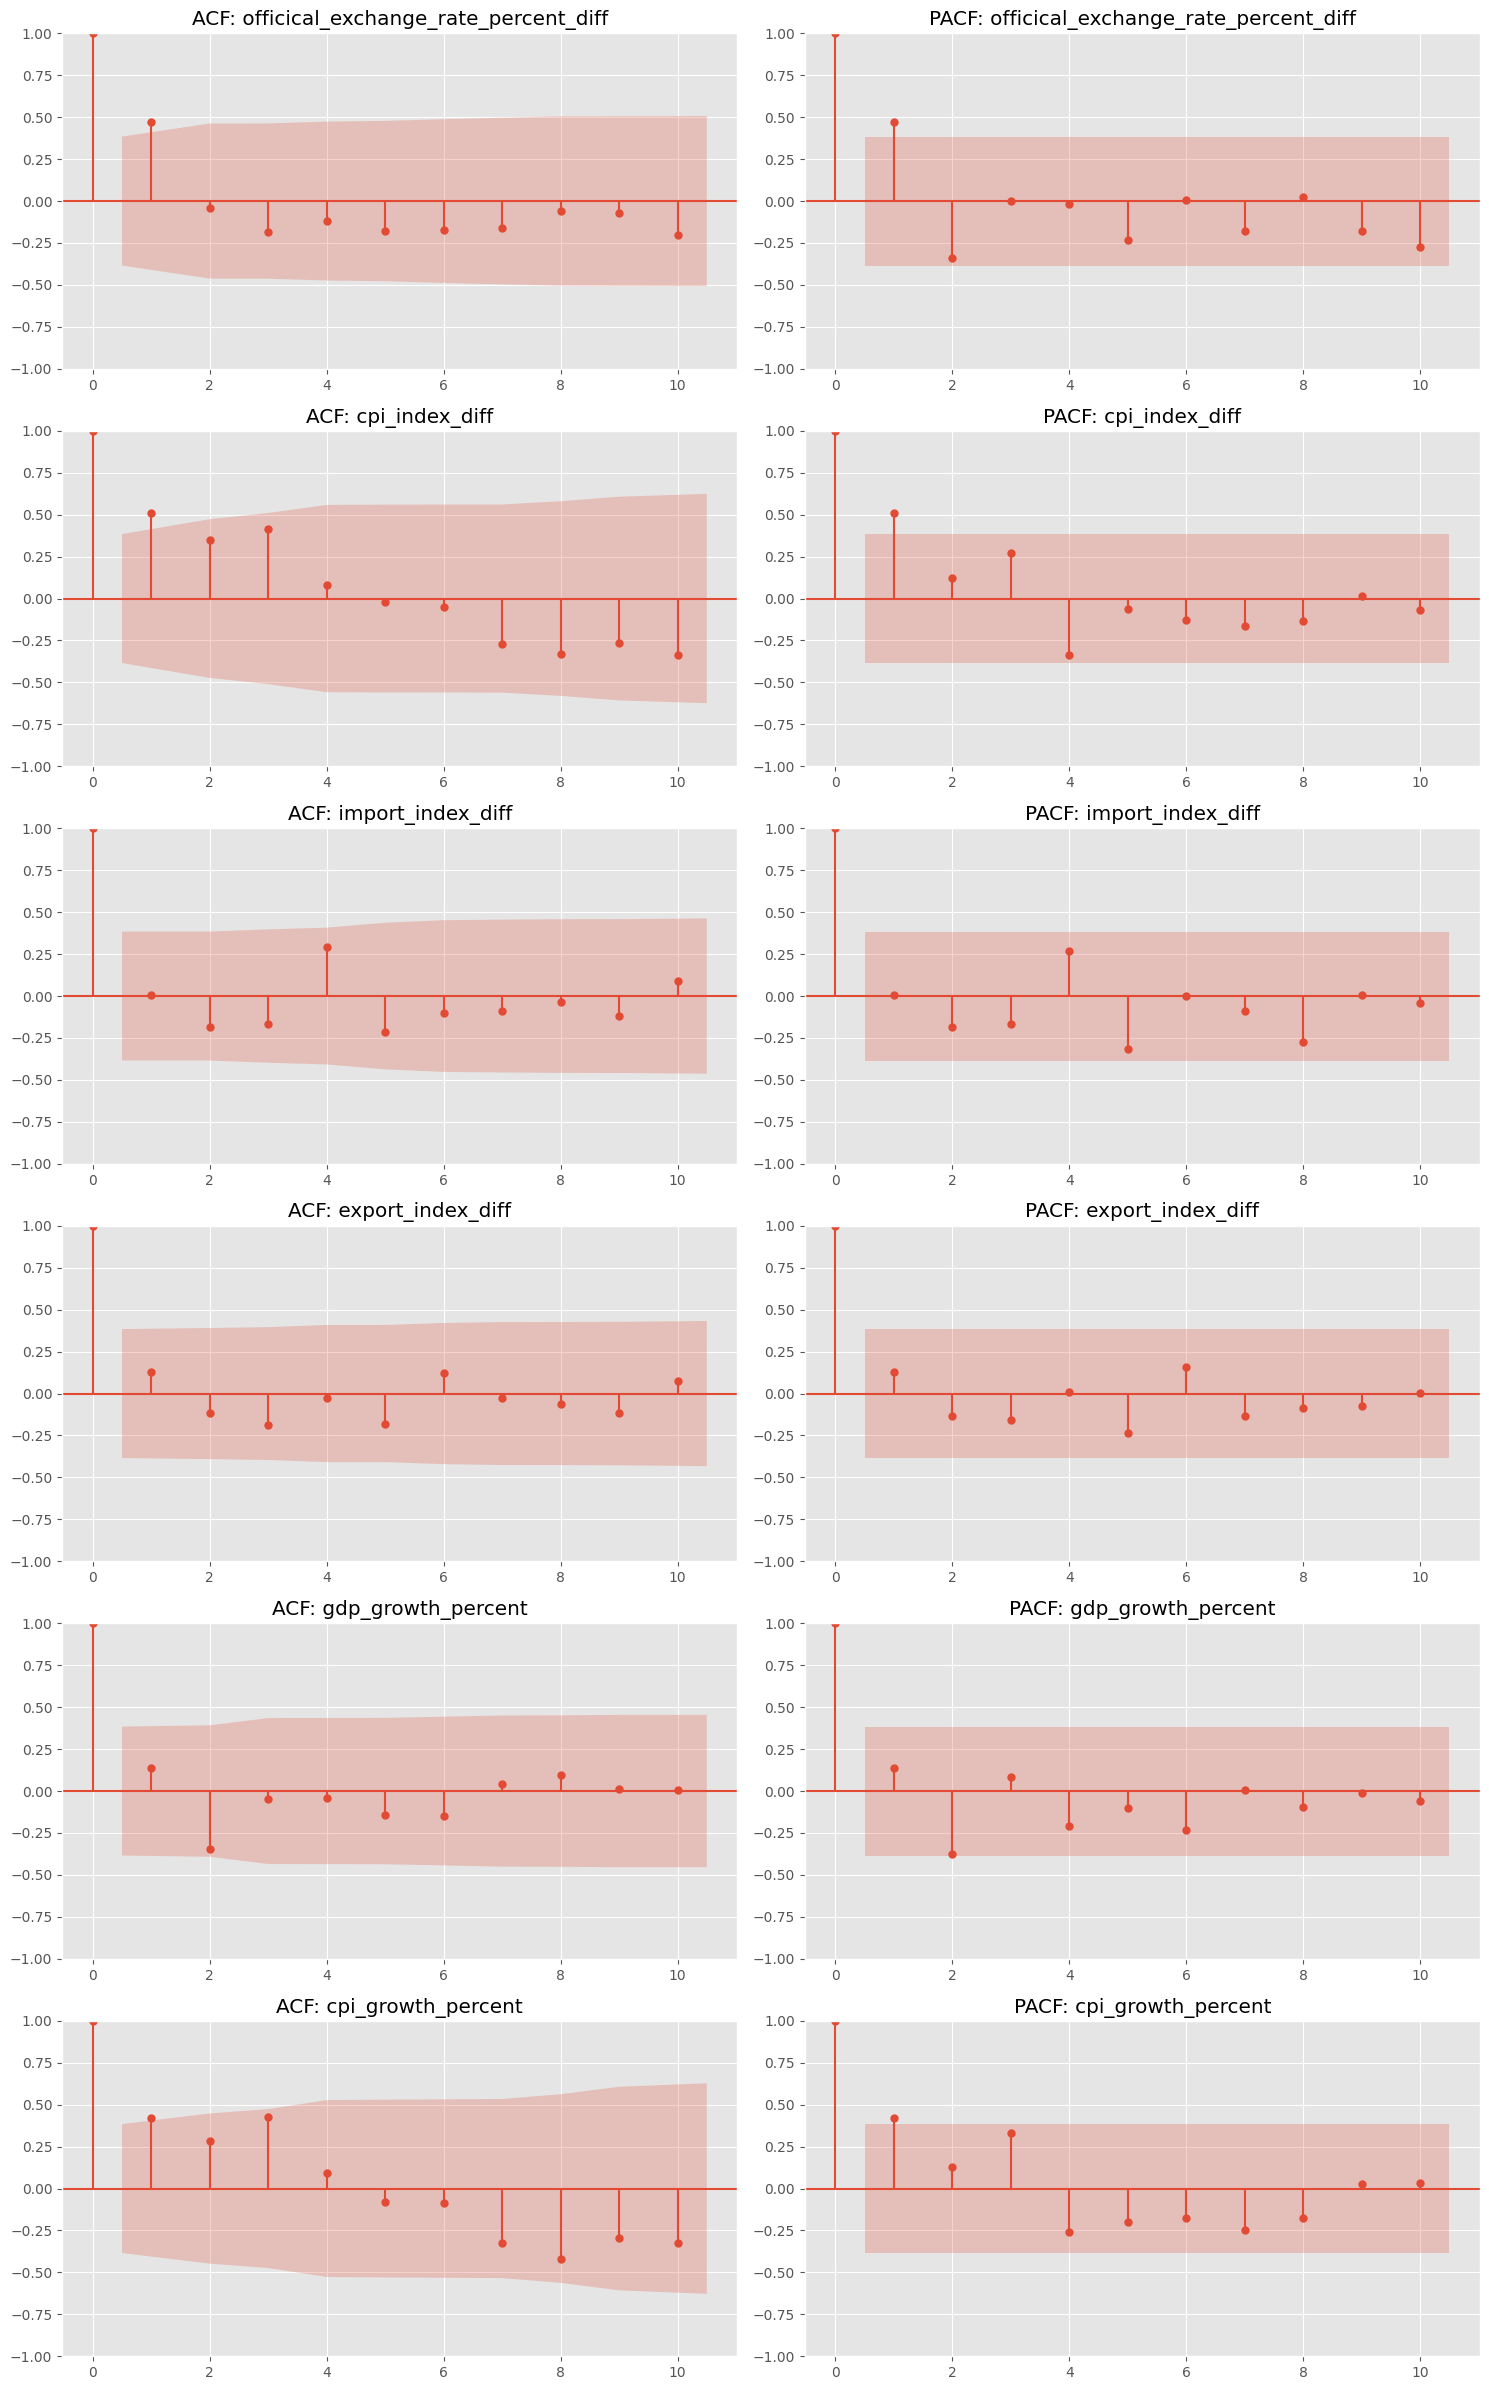

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Danh sách các biến cần vẽ
group1 = ['officical_exchange_rate_percent_diff', 'cpi_index_diff', 'import_index_diff', 'export_index_diff']
group2 = ['gdp_growth_percent', 'cpi_growth_percent']
target_vars = group1 + group2

# Thiết lập lưới đồ thị
n_vars = len(target_vars)
fig, axes = plt.subplots(nrows=n_vars, ncols=2, figsize=(15, 4 * n_vars))

for i, col in enumerate(target_vars):
    # Lấy dữ liệu và loại bỏ NaN để vẽ
    series_data = df_final[col].dropna()

    # Vẽ ACF
    plot_acf(series_data, ax=axes[i, 0], lags=10, title=f'ACF: {col}')
    # Vẽ PACF
    plot_pacf(series_data, ax=axes[i, 1], lags=10, title=f'PACF: {col}')

plt.tight_layout()
plt.show()

###  Kết Luận: Phân Tích Đồ Thị ACF & PACF

> **ACF và PACF là gì?**
> - **ACF (Autocorrelation Function):** Đo lường xem một năm có "nhớ" các năm trước không. Cột bar vượt ra ngoài **vùng hồng** = có mối liên hệ thực sự với năm đó.
> - **PACF (Partial ACF):** Chỉ đo tác động **trực tiếp** thuần túy của năm t-k lên năm t, đã loại bỏ ảnh hưởng trung gian.
>
> **Quy tắc đọc:** Bar **trong vùng hồng** = không đáng kể (nhiễu). Bar **vượt ra ngoài** = có tự tương quan thực sự.

---

**Nhận xét từng biến:**

| Biến | ACF (quan sát) | PACF (quan sát) | Kết luận |
|------|---------------|-----------------|---------|
| `officical_exchange_rate_percent_diff` | Spike lớn lag-0, từ lag-1 trở đi nằm trong band | Spike rõ tại lag-1 (~0.5), cắt đứt nhanh | ✅ Dừng — có AR(1) ngắn hạn, sau đó là nhiễu trắng |
| `cpi_index_diff` | Lag-1 vẫn ngoài band (~0.5), giảm dần chậm | Spike tại lag-1 (~0.5), lag-2 nhỏ hơn | ⚠️ Dừng yếu — có "bộ nhớ" lag-1 rõ ràng, nhất quán với ADF p=0.058 (biên giới) |
| `import_index_diff` | Tất cả nằm gọn trong band từ lag-1 | Lag-1 hơi nhô nhẹ, còn lại trong band | ✅ Dừng tốt — gần như nhiễu trắng thuần túy |
| `export_index_diff` | Tất cả nằm trong band — rất sạch | Tất cả nằm trong band | ✅ Dừng tốt nhất — nhiễu trắng hoàn toàn |
| `gdp_growth_percent` | Nhanh chóng về 0, một số spike âm nhỏ | Lag-1 hơi âm (nhỏ), còn lại trong band | ✅ Dừng mạnh — tăng trưởng GDP dao động ngẫu nhiên quanh trung bình |
| `cpi_growth_percent` | Lag-1 vượt band (~0.5), giảm dần, một số lag cao vẫn ra ngoài | Spike rõ nhất tại lag-1 (~0.5), rồi cắt đứt | ⚡ Dừng + có AR(1) rõ — **bằng chứng trực quan của Inflation Inertia** |

---

**3 phát hiện:**

**1. `export_index_diff` — Sạch nhất, dừng hoàn hảo:**
Cả ACF lẫn PACF đều nằm hoàn toàn trong vùng hồng từ lag-1 trở đi. Sai phân bậc 1 đã loại bỏ hoàn toàn cấu trúc tự tương quan của chuỗi xuất khẩu.

**2. `cpi_growth_percent` — Spike lag-1 rõ nhất:**
Đây là bằng chứng **trực quan mạnh nhất** cho hiện tượng *Inflation Inertia* (Quán tính lạm phát) — lạm phát năm nay bị ảnh hưởng đáng kể bởi lạm phát năm trước. Điều này giải thích tại sao trong FEVD sau đó, CPI tự giải thích ~90% phương sai của chính nó.

**3. `cpi_index_diff` — Giảm chậm, dừng yếu:**
ACF giảm không nhanh, một số lag vẫn ngoài band. Nhất quán với kết quả ADF borderline (p=0.058). Đây là lý do biến này **không được chọn** vào `selected_features` cho VAR — ưu tiên `cpi_growth_percent` thay thế.

---

**→ Đồ thị ACF/PACF xác nhận:** Lựa chọn **Lag = 2** là hợp lý — tất cả biến có cấu trúc tự tương quan tắt dần sau lag-1 đến lag-2, không có biến nào có "bộ nhớ dài" vượt quá 2 năm.


### **VAR Model Construction & 3-Year Forecasting**
Huấn luyện mô hình VAR với độ trễ $p=1$ và thực hiện dự báo cho giai đoạn 3 năm tiếp theo.

> **BIỆN LUẬN LỰA CHỌN ĐỘ TRỄ (LAG ORDER): TẠI SAO LÀ VAR(1)?**
> Dù tiêu chí AIC gợi ý độ trễ $p=2$, nhưng nhóm quyết định chọn độ trễ **$p=1$** (Sử dụng mô hình VAR(1)) dựa trên 2 cơ sở:
> 1. **Rủi ro Overfitting (Quá khớp):** Kích thước mẫu của chúng ta khá nhỏ (N=26 năm). Nếu chọn $p=2$, số lượng tham số cần ước lượng sẽ tăng gấp đôi, làm giảm "Bậc tự do" (Degrees of Freedom), dẫn đến hiện tượng nhiễu thống kê. Tiêu chí BIC (phạt nặng sự phức tạp) cũng gợi ý $p=0$. Do đó, $p=1$ là sự thỏa hiệp hoàn hảo.
> 2. **Logic Vĩ mô:** Các quyết sách tiền tệ (Tín dụng, Tỷ giá) tại Việt Nam thường có độ trễ truyền dẫn vào nền kinh tế rõ rệt nhất trong chu kỳ **1 năm tiếp theo**.

In [ ]:
var_model = model.fit(1)
print(var_model.summary())

forecast_steps = 3
forecast = var_model.forecast(y=df_var.values, steps=forecast_steps)

forecast_index = pd.date_range(start=df_var.index[-1] + pd.DateOffset(years=1), periods=forecast_steps, freq='YS')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=selected_features)

print("\nKết quả dự báo cho 3 năm tiếp theo:")
display(forecast_df)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 26, May, 2026
Time:                     01:48:18
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    17.2746
Nobs:                     25.0000    HQIC:                   16.5700
Log likelihood:          -325.638    FPE:                1.22542e+07
AIC:                      16.2995    Det(Omega_mle):     5.90964e+06
--------------------------------------------------------------------
Results for equation cpi_growth_percent
                                             coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------------------
const                                          -3.530870         6.787635           -0.520           0.603
L1.cpi_growth_percent                           0.

,cpi_growth_percent,gdp_growth_percent,lending_interest_percent,officical_exchange_rate_percent_diff
2023-01-01,6.903155,6.965953,9.096701,358.636554
2024-01-01,6.941766,6.499751,9.361128,354.306976
2025-01-01,6.462452,6.411281,9.382742,342.992402


### Kết Luận: Mô Hình VAR — Huấn Luyện & Dự Báo 3 Năm (2023–2025)

> **VAR làm gì?** Thay vì dự báo từng biến riêng lẻ, VAR dự báo **4 biến cùng lúc** và cho phép chúng tác động qua lại lẫn nhau — phản ánh đúng thực tế kinh tế: lãi suất ảnh hưởng lạm phát, lạm phát ảnh hưởng tỷ giá, v.v.

---

**Thông số mô hình đã huấn luyện:**

- **Số phương trình:** 4 (mỗi biến 1 phương trình)
- **Số quan sát:** 25 năm
- **Độ trễ sử dụng: p = 1** *(nhìn lại 1 năm để dự báo)*
- **AIC = 16.30** — chỉ số đo chất lượng mô hình (càng nhỏ càng tốt)

---

**Đọc kết quả hệ số (Phương trình CPI):**

| Yếu tố năm trước tác động lên CPI | Hệ số | p-value | Giải thích |
|------------------------------------|-------|---------|-----------|
| Lạm phát năm trước (`L1.cpi`) | **+0.403** | 0.156 | CPI tự duy trì ~40% — quán tính lạm phát |
| Tăng trưởng GDP năm trước (`L1.gdp`) | **+1.058** | 0.180 | GDP tăng → kéo lạm phát tăng theo |
| Lãi suất năm trước (`L1.lending`) | +0.006 | 0.992 | Hầu như không tác động trực tiếp |
| Tỷ giá năm trước (`L1.exchange`) | +0.001 | 0.771 | Tác động rất nhỏ |

>  **Lưu ý quan trọng:** Tất cả p-value đều > 0.05 — nghĩa là **không có hệ số nào có ý nghĩa thống kê**. Đây là hệ quả trực tiếp của **sample nhỏ (25 obs)** — không đủ dữ liệu để các hệ số "thoát khỏi vùng nhiễu" thống kê. Tuy nhiên, **chiều hướng** (dấu +/-) của hệ số vẫn có giá trị kinh tế học.

---

**Kết quả dự báo 2023-2025:**

| Năm | Lạm phát CPI (%) | Tăng trưởng GDP (%) | Lãi suất (%) | Biến động tỷ giá (VND) |
|-----|-----------------|---------------------|-------------|----------------------|
| 2023 | 6.90 | **6.97** (cao nhất) | 9.10 (thấp nhất) | 358.64 |
| 2024 | 6.94 | 6.50 | 9.36 | 354.31 |
| 2025 | **6.46** (thấp nhất) | 6.41 | **9.38** (cao nhất) | **342.99** (thấp nhất) |

---

**Đọc xu hướng dự báo:**

**1. CPI Lạm phát — Tăng nhẹ rồi hạ nhiệt:**
6.90% → 6.94% → 6.46%. Mô hình dự báo lạm phát sẽ đạt đỉnh 2024 rồi giảm về ~6.5% vào 2025 — phản ánh xu hướng *mean-reverting* (tự hồi phục về trung bình) của chuỗi Stationary.

**2. GDP Tăng trưởng — Hội tụ ổn định:**
6.97% → 6.50% → 6.41%. Kinh tế dự báo tăng trưởng bền vững quanh **6.4-6.5%/năm** — mức tăng trưởng tiềm năng dài hạn của Việt Nam.

**3. Lãi suất — Tăng dần, ổn định:**
9.10% → 9.36% → 9.38%. Lãi suất đang trong xu hướng bình thường hóa sau giai đoạn thấp hậu COVID, hội tụ quanh **9.4%**.

**4. Biến động tỷ giá — Giảm dần:**
358 → 354 → 343 VND. Biên độ dao động tỷ giá thu hẹp — phù hợp với chính sách điều hành tỷ giá ổn định của NHNN.

---

**→ Tổng kết:** Mô hình VAR(1) dự báo nền kinh tế Việt Nam sẽ **ổn định và hội tụ** trong 2023-2025 — lạm phát kiểm soát dưới 7%, GDP duy trì quanh 6.4%, lãi suất ổn định ~9.4%. Đây là kịch bản **"soft landing"** (hạ cánh mềm) sau các cú sốc kinh tế gần đây.


### **AREA CONTRIBUTION CHART**

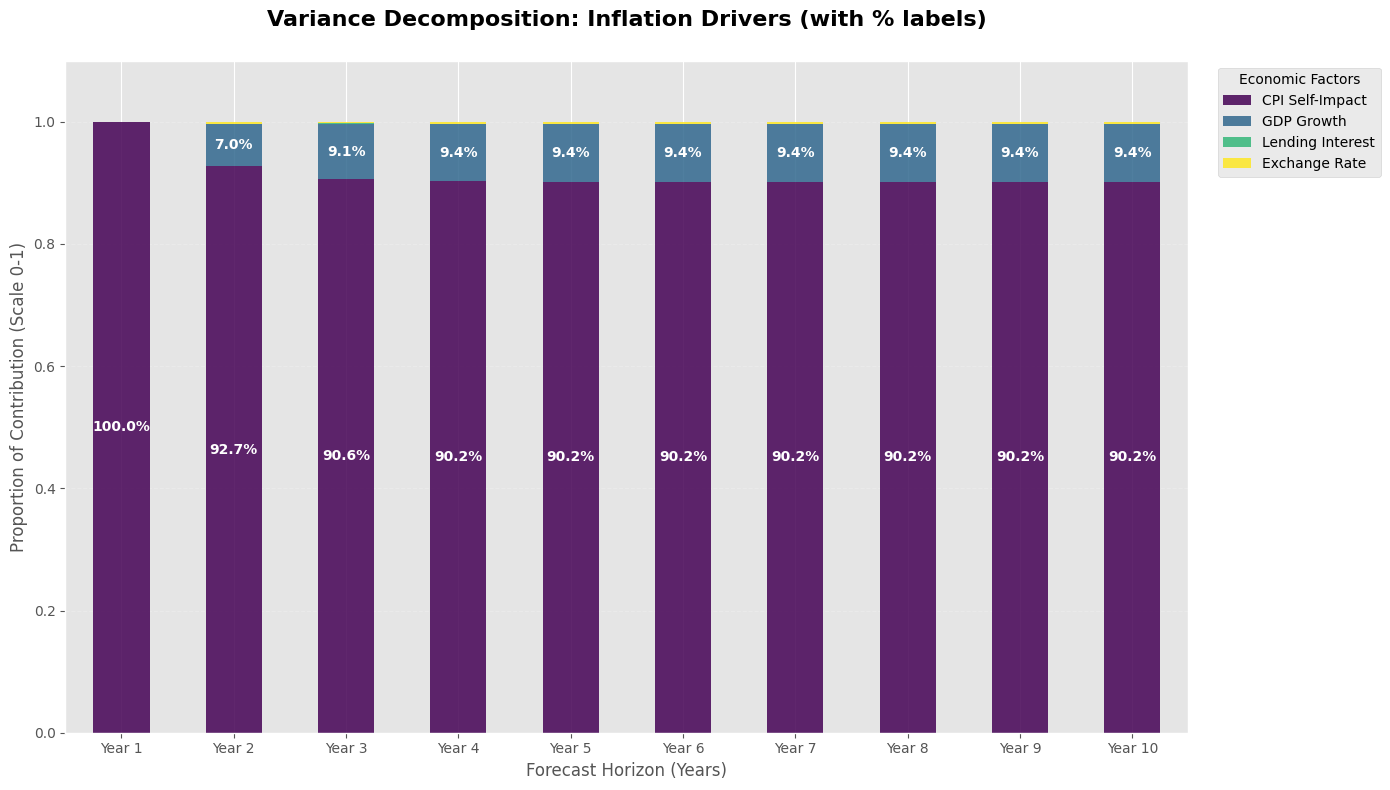

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Tính toán FEVD từ mô hình VAR
fevd_res = var_model.fevd(10)

# 2. Chuẩn bị dữ liệu đóng góp cho biến CPI
years = [f'Year {i}' for i in range(1, 11)]
contributions = fevd_res.decomp[0] # Index 0 là cpi_growth_percent

contribution_df = pd.DataFrame(
    contributions,
    index=years,
    columns=['CPI Self-Impact', 'GDP Growth', 'Lending Interest', 'Exchange Rate']
)

# 3. Vẽ biểu đồ Cột Chồng với tỷ lệ phần trăm hiển thị trực tiếp
ax = contribution_df.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis', alpha=0.85)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0.02:
        x, y = p.get_xy()
        ax.text(x + width/2,
                y + height/2,
                f'{height:.1%}',
                horizontalalignment='center',
                verticalalignment='center',
                color='white',
                fontsize=10,
                fontweight='bold')

plt.title('Variance Decomposition: Inflation Drivers (with % labels)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Forecast Horizon (Years)', fontsize=12)
plt.ylabel('Proportion of Contribution (Scale 0-1)', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Economic Factors')
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

###  Kết Luận: Phân Rã Phương Sai (FEVD) — Điều Gì Thực Sự Gây Ra Lạm Phát?

> **FEVD (Forecast Error Variance Decomposition) là gì?** Khi mô hình dự báo sai, sai số đó đến từ đâu? FEVD trả lời câu hỏi này bằng cách tính: **bao nhiêu % sai số dự báo lạm phát** được gây ra bởi mỗi yếu tố kinh tế. Nhìn vào biểu đồ: mỗi cột = 100%, màu sắc = phần đóng góp của từng yếu tố.

---

**Đọc kết quả từ biểu đồ:**

| Giai đoạn | CPI tự tác động | GDP Growth | Lãi suất | Tỷ giá |
|-----------|---------------|-----------|---------|--------|
| **Năm 1** | **100%** | 0% | 0% | 0% |
| **Năm 2** | 92.7% | 7.0% | ~0% | ~0% |
| **Năm 3** | 90.6% | 9.1% | ~0% | ~0% |
| **Năm 4-10** | **~90.2% (ổn định)** | **~9.4% (ổn định)** | < 0.5% | < 0.5% |

---

**3 phát hiện:**

**1.  CPI tự giải thích ~90% — Bằng chứng mạnh của Inflation Inertia:**
Phần tím khổng lồ chiếm đến **90% cột** ở mọi horizon. Đây là hiện tượng **Quán tính lạm phát** (*Inflation Inertia*) — một khi lạm phát đã hình thành trong nền kinh tế, nó tự duy trì chính nó qua kỳ vọng và hành vi giá cả của người dân và doanh nghiệp. Nói đơn giản: lạm phát cao năm nay → mọi người kỳ vọng lạm phát tiếp tục cao → điều chỉnh lương, giá → lạm phát thực sự tiếp tục cao năm sau.

**2.  GDP Growth đóng góp ~9.4% — Xác nhận Demand-Pull Inflation:**
Phần xanh lam ổn định ở **~9.4% từ Năm 3 trở đi**. Khi nền kinh tế tăng trưởng nóng (GDP cao), người dân có nhiều tiền hơn, chi tiêu nhiều hơn → đẩy giá cả chung lên. Đây là cơ chế *Lạm phát do Cầu kéo* (*Demand-Pull Inflation*) theo lý thuyết Đường cong Phillips — được xác nhận bằng số liệu thực.

**3.  Lãi suất & Tỷ giá < 0.5% — Tác động không đáng kể:**
Hai dải màu xanh lá và vàng gần như **vô hình** trong biểu đồ. Điều này cho thấy:
- **Lãi suất:** Có thể có độ trễ hiệu lực > 1 năm, vượt ngoài tầm nhìn mô hình VAR(1).
- **Tỷ giá:** Cơ chế điều hành ổn định VND của NHNN làm giảm tác động pass-through (truyền dẫn tỷ giá vào lạm phát) trong ngắn hạn.

---

**Hàm ý chính sách quan trọng nhất:**

> Vì lạm phát chủ yếu tự duy trì (~90%), **công cụ quan trọng nhất để kiểm soát lạm phát tại Việt Nam không phải là điều chỉnh lãi suất hay tỷ giá ngắn hạn**, mà là **neo giữ kỳ vọng lạm phát** — thông qua truyền thông chính sách nhất quán, cam kết mục tiêu lạm phát rõ ràng, và duy trì niềm tin vào sự ổn định của đồng tiền.

**→ Kết luận đồ thị:** FEVD là kết quả **thuyết phục nhất** của toàn bộ Phase 6 — định lượng rõ ràng rằng lạm phát Việt Nam có bản chất **tự hồi tiếp (inertial)**, với GDP là kênh truyền dẫn ngoại sinh duy nhất đáng kể trong horizon 10 năm.


### **Giải thích kết quả Phân rã phương sai (FEVD)**

Dựa trên biểu đồ trên, ta thấy sự đóng góp vào biến động của Lạm phát (CPI) tập trung vào hai yếu tố chính:

1.  **CPI Self-Impact (~90%):** Đây là hiện tượng **Quán tính lạm phát**. Nó cho thấy lạm phát tại quốc gia này phụ thuộc rất nhiều vào tâm lý kỳ vọng và các yếu tố nội tại kéo dài từ quá khứ. Khi lạm phát đã hình thành, nó có xu hướng tự duy trì.
2.  **GDP Growth (~9.4%):** Đây là yếu tố **Lạm phát do cầu kéo**. Khi nền kinh tế tăng trưởng nóng (GDP tăng), nhu cầu tiêu dùng tăng cao đẩy mức giá chung lên. Kết quả này xác nhận GDP là động lực vĩ mô quan trọng nhất tác động đến CPI sau chính nó.
3.  **Tỷ giá & Lãi suất (<1%):**
    *   Có thể do cơ chế điều hành tỷ giá ổn định nên các cú sốc tỷ giá không gây biến động quá lớn trực tiếp vào CPI.
    *   Lãi suất cho vay có thể có độ trễ lớn hơn 1 năm, nên mô hình VAR(1) chưa bắt được sự đóng góp đáng kể của nó vào phương sai sai số dự báo.

### **Summary Phase 6: VAR Model Results**
- **Kết quả:** Mô hình VAR(1) được xác lập với các hệ số cho thấy tác động trễ của GDP và Tỷ giá lên lạm phát. Dự báo 3 năm tới cho thấy các biến số có xu hướng ổn định trở lại quanh mức trung bình.
- **Kết luận:** Mô hình VAR có khả năng bắt được các mối quan hệ đa chiều, tuy nhiên sai số dự báo (RMSE) vẫn còn chịu ảnh hưởng bởi các biến động bất thường trong quá khứ.

## **PHASE 7: ARIMA Forecasting (Univariate Analysis)**

> **Câu hỏi đặt ra:** Nếu chúng ta "nhắm mắt" bỏ qua mọi yếu tố vĩ mô khác (Tỷ giá, GDP, Lãi suất...) và chỉ nhìn vào chuỗi lịch sử của chính Lạm phát, liệu chúng ta có thể dự báo được tương lai không?
>
> Để trả lời, nhóm sử dụng mô hình tự hồi quy ARIMA. Bản chất của mô hình này là đo lường **"Quán tính tâm lý"** – tức là xem xét việc lạm phát của ngày hôm qua sẽ để lại dư âm (quán tính) kéo lạm phát của ngày mai tăng theo như thế nào.


### **Model Evaluation Metrics**
Tính toán sai số (MAE, RMSE) để đánh giá khả năng khớp (goodness-of-fit) của mô hình VAR(1).

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_true = df_var.values[1:]
y_pred = var_model.fittedvalues.values # Chuyển sang NumPy array để slice [:, i]

metrics = []
for i, col in enumerate(selected_features):
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    metrics.append({'Variable': col, 'MAE': mae, 'RMSE': rmse})

evaluation_df = pd.DataFrame(metrics)
print("Model Training Performance Metrics:")
display(evaluation_df)

Model Training Performance Metrics:


,Variable,MAE,RMSE
0,cpi_growth_percent,3.142027,4.587352
1,gdp_growth_percent,0.864658,1.269759
2,lending_interest_percent,1.406919,1.828561
3,officical_exchange_rate_percent_diff,310.562721,415.505867


## **ARIMA Model for CPI Forecast**
Mục tiêu: Xây dựng mô hình ARIMA cho chuỗi dữ liệu lạm phát (`cpi_growth_percent`).

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Sử dụng biến cpi_growth_percent đã đạt tính dừng
cpi_series = df_final['cpi_growth_percent']

# Khởi tạo và huấn luyện mô hình ARIMA(1, 0, 1)
arima_model = ARIMA(cpi_series, order=(1, 0, 1))
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:     cpi_growth_percent   No. Observations:                   26
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -76.958
Date:                Tue, 26 May 2026   AIC                            161.915
Time:                        01:50:17   BIC                            166.947
Sample:                    01-01-1997   HQIC                           163.364
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4570      3.407      1.602      0.109      -1.220      12.134
ar.L1          0.7292      0.372      1.963      0.050       0.001       1.457
ma.L1         -0.3890      0.438     -0.888      0.3

**Diễn giải mô hình:**
*Kết quả huấn luyện mô hình ARIMA(1, 0, 1) cho thấy Lạm phát hiện tại chịu tác động trực tiếp từ độ trễ 1 năm trước của nó. (Bảng thống kê chi tiết phía trên dùng để kiểm định các sai số kỹ thuật, nhóm sẽ tập trung trực tiếp vào biểu đồ dự báo và sai số thực tế ở phần dưới để dễ hình dung).*


### **ARIMA Forecast & Visualization**
Mục tiêu: Dự báo lạm phát và trực quan hóa so với dữ liệu thực tế.

**Trực quan hóa kịch bản lạm phát tương lai (Dựa trên Quán tính)**
> Biểu đồ dưới đây mô phỏng kịch bản lạm phát trong 3 năm tới nếu nền kinh tế không chịu thêm bất kỳ "cú sốc" ngoại cảnh nào (như chiến tranh, dịch bệnh hay tăng tỷ giá đột biến). Dải màu hồng thể hiện "Khoảng tin cậy" - tức là biên độ dao động rủi ro có thể xảy ra.


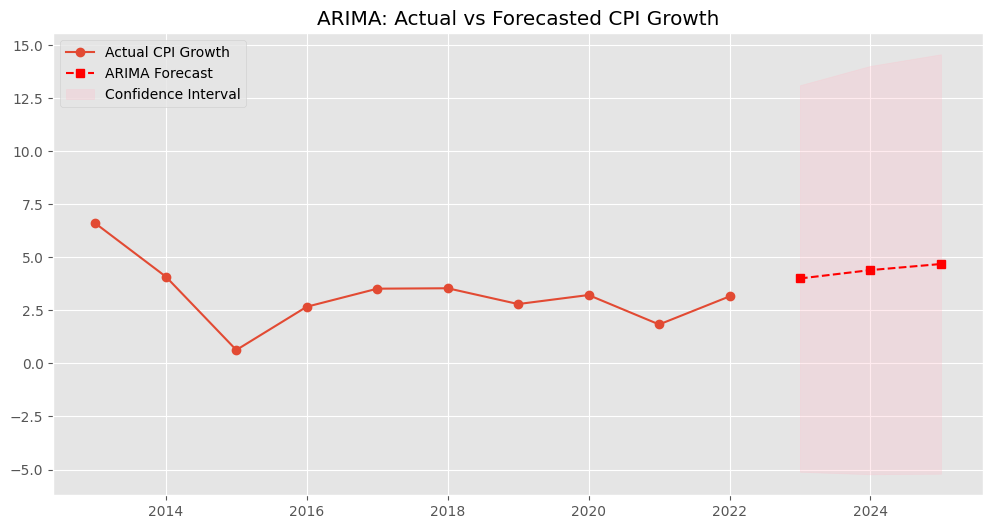

In [ ]:
# Dự báo 3 năm tiếp theo
arima_forecast = arima_result.get_forecast(steps=3)
arima_forecast_df = arima_forecast.summary_frame()

plt.figure(figsize=(12, 6))
plt.plot(cpi_series.tail(10), label='Actual CPI Growth', marker='o')
plt.plot(arima_forecast.predicted_mean, label='ARIMA Forecast', marker='s', color='red', linestyle='--')
plt.fill_between(arima_forecast_df.index, arima_forecast_df['mean_ci_lower'], arima_forecast_df['mean_ci_upper'], color='pink', alpha=0.3, label='Confidence Interval')
# plt.title('ARIMA: Actual vs Forecasted CPI Growth')
plt.title('DỰ BÁO TỪ QUÁN TÍNH: Lạm phát kỳ vọng tiếp tục duy trì đà tăng nhẹ', fontweight='bold', pad=15)
plt.legend()
plt.grid(True)
plt.show()

### **Evaluate ARIMA**
Mục tiêu: Đánh giá độ chính xác của mô hình ARIMA bằng các chỉ số thống kê.

**Đánh giá sai số dự báo:**
> Tương tự như đánh giá mô hình hồi quy thông thường, nhóm sử dụng chỉ số **RMSE** (phạt nặng các sai số lớn) và **MAE** (sai số trung bình tuyệt đối) để xem xét khả năng dự báo của mô hình.


In [ ]:
y_true_arima = cpi_series
y_pred_arima = arima_result.fittedvalues

rmse_arima = np.sqrt(mean_squared_error(y_true_arima, y_pred_arima))
mae_arima = mean_absolute_error(y_true_arima, y_pred_arima)

print(f"ARIMA Model Evaluation:")
print(f"- RMSE: {rmse_arima:.4f}")
print(f"- MAE: {mae_arima:.4f}")

ARIMA Model Evaluation:
- RMSE: 4.6514
- MAE: 3.0942


**Summary Phase 7: Phân tích dự báo một chiều (Mô hình ARIMA)**

*   **Kết quả dự báo:** Dựa hoàn toàn vào dữ liệu quá khứ, mô hình ARIMA dự báo Lạm phát (CPI) của Việt Nam trong 3 năm tới có xu hướng nhích nhẹ lên và duy trì quanh mức **4.5% - 5%**.
*   **Đánh giá mô hình:** Sai số dự báo trung bình (RMSE) đạt mức **~4.65%**. Vùng rủi ro (khoảng tin cậy màu hồng trên biểu đồ) mở rộng khá nhanh. Điều này chứng tỏ: Quán tính lạm phát là có thật, nhưng trong tương lai xa, lạm phát rất dễ bị chệch hướng khỏi quỹ đạo nếu chỉ dựa vào mỗi yếu tố tâm lý.
*   **Góc nhìn Kinh tế (Insight):** Lạm phát mang "căn bệnh tự miễn" - tự nó sinh ra nó do tâm lý kỳ vọng của thị trường. Tuy nhiên, nếu chỉ dùng mô hình một chiều (ARIMA) thì sẽ không thể lường trước được các cú sốc bên ngoài. Điều này mở ra sự cần thiết phải sử dụng một hệ thống phức tạp hơn (Mô hình đa biến VAR ở Phase 8) để tìm hiểu xem: *"Bên cạnh quán tính, thì yếu tố ngoại sinh nào (Tỷ giá, GDP, Tín dụng) mới là thứ bẻ lái đường biểu diễn lạm phát?"*.


## **PHASE 8: Advanced VAR Analysis (IRF & FEVD)**

> **Câu hỏi đặt ra:** Nếu lạm phát có tính quán tính, thì ban đầu yếu tố nào đã thổi bùng lên quán tính đó? Là do Tín dụng tăng trưởng quá nóng, Tỷ giá USD/VND đội lên, hay do Tăng trưởng GDP?
>
> Để "cân đo đong đếm" chính xác đóng góp của từng yếu tố, nhóm sử dụng **Phân rã phương sai (FEVD - Forecast Error Variance Decomposition)**. Bạn có thể hiểu đơn giản đây là kỹ thuật tìm ra **"Tỷ trọng đóng góp"** của từng biến số vào sự biến động của lạm phát trong 5 năm tới.


### **Structural Analysis (IRF & FEVD Interpretation)**

Trong phân tích VAR nâng cao, chúng ta tập trung vào hai công cụ chính để hiểu động lực học của hệ thống:

*   **Impulse Response Function (IRF):** Trả lời câu hỏi "Nếu một biến (ví dụ: Tỷ giá) bị sốc tăng 1 đơn vị, thì Lạm phát sẽ phản ứng như thế nào trong 10 năm tới?".
*   **Forecast Error Variance Decomposition (FEVD):** Trả lời câu hỏi "Sự biến động của Lạm phát được giải thích bao nhiêu % bởi chính nó, và bao nhiêu % bởi các biến khác như GDP hay Lãi suất?".

In [ ]:
# Tính toán và hiển thị bảng FEVD cho biến CPI
fevd_res = var_model.fevd(5)
print("Bảng phân rã phương sai cho CPI (5 năm đầu):")
fevd_table = pd.DataFrame(fevd_res.decomp[0],
                          columns=selected_features,
                          index=[f'Year {i+1}' for i in range(5)])
display(fevd_table * 100)

Bảng phân rã phương sai cho CPI (5 năm đầu):


,cpi_growth_percent,gdp_growth_percent,lending_interest_percent,officical_exchange_rate_percent_diff
Year 1,100.000000,0.000000,0.000000,0.000000
Year 2,92.687560,6.984077,0.047051,0.281313
Year 3,90.579975,9.101009,0.045791,0.273225
Year 4,90.246473,9.416122,0.051214,0.286192
Year 5,90.200321,9.439377,0.059809,0.300493


**Đọc vị bảng Phân rã phương sai:**
> Kết quả bảng trên chỉ ra một sự thật thú vị: Ngay ở năm đầu tiên, 100% lạm phát là do chính lịch sử của nó. Đến năm thứ 5, quán tính (cpi_growth_percent) vẫn chiếm tới hơn **90%** nguyên nhân. Yếu tố bên ngoài lớn nhất có đủ sức bẻ lái lạm phát là **Tăng trưởng GDP (chiếm khoảng 9.4%)**. Điều này củng cố vững chắc cho nhận định: Lạm phát tại Việt Nam là một "căn bệnh tự miễn" do tâm lý phòng thủ của thị trường.


### **Granger Causality Analysis**
Kiểm tra xem các biến có giá trị dự báo cho nhau hay không. Nếu P-value < 0.05, ta có thể nói biến X 'gây ra' (Granger-cause) biến Y.

**Kiểm định Tính dẫn dắt (Granger Causality): Đâu là "Chỉ báo sớm" của Lạm phát?**
> Trong kinh tế, hai đường biểu diễn đi lên cùng nhau chưa chắc biến này đã gây ra biến kia (chỉ là tương quan). Để tìm ra đâu là **"Chỉ báo báo trước"** (biến đổi hôm nay, gây ra hệ quả vào ngày mai), nhóm dùng kiểm định Granger Causality.
>
> *Luật đọc biểu đồ:* Nếu ô giao nhau có màu tối (hoặc giá trị P-value < 0.05), điều đó bật "đèn xanh" xác nhận rằng biến ở hàng ngang có khả năng dẫn dắt (dự báo trước) biến ở cột dọc.


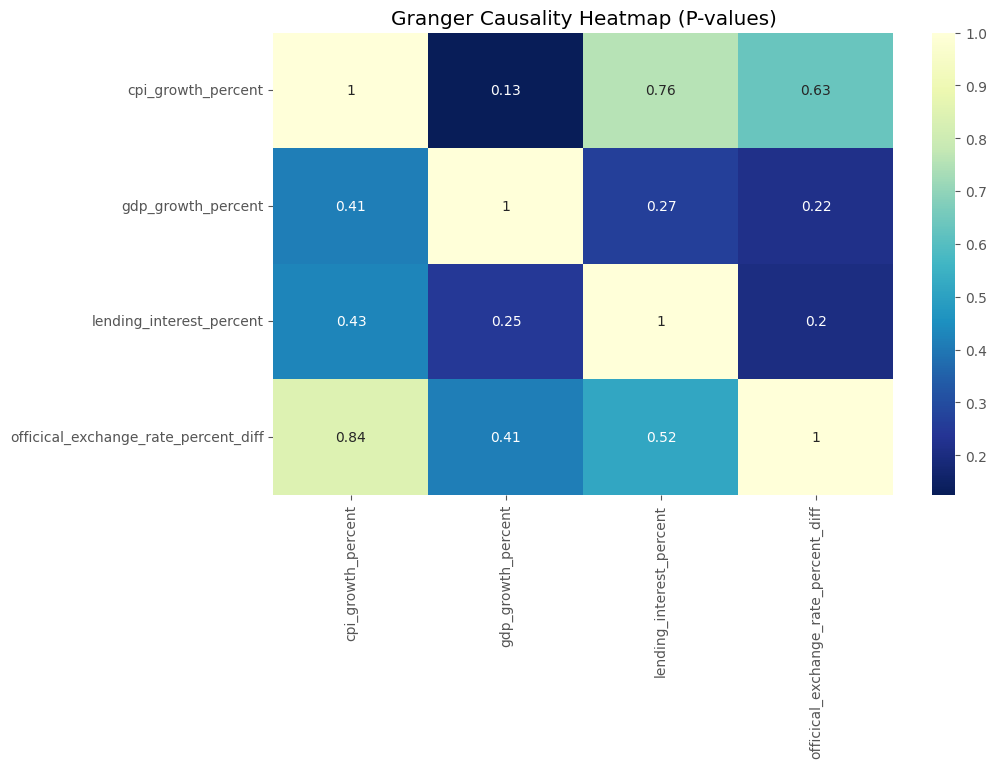

Ghi chú: P-value < 0.05 nghĩa là biến ở hàng (row) có tác động Granger lên biến ở cột (column).


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def check_granger(df, variables):
    res_matrix = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in res_matrix.columns:
        for r in res_matrix.index:
            if r != c:
                test_result = grangercausalitytests(df[[r, c]], maxlag=1, verbose=False)
                p_values = [round(test_result[i+1][0]['ssr_chi2test'][1], 4) for i in range(1)]
                res_matrix.loc[r, c] = p_values[0]
            else:
                res_matrix.loc[r, c] = 1.0
    return res_matrix

# granger_df = check_granger(df_var, selected_features)
# plt.figure(figsize=(10, 6))
# sns.heatmap(granger_df, annot=True, cmap='YlGnBu_r')
# plt.title('Granger Causality Heatmap (P-values)')
# plt.show()
# print("Ghi chú: P-value < 0.05 nghĩa là biến ở hàng (row) có tác động Granger lên biến ở cột (column).")

granger_df = check_granger(df_var, selected_features)

# Tạo một ma trận text để hiển thị thay vì hiện số P-value thô
annot_text = np.where(granger_df < 0.05, 'Dẫn dắt\n(P<0.05)', '-')

plt.figure(figsize=(10, 6))
cmap_custom = sns.color_palette(["#e24a33", "#f0f0f0"])

sns.heatmap(granger_df < 0.05, annot=annot_text, fmt='', cmap=cmap_custom, cbar=False, linewidths=1, linecolor='white')

plt.title('PHÁT HIỆN CHỈ BÁO SỚM: Tỷ giá có khả năng "Báo trước" Lạm phát', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Biến nguyên nhân (Gây ra)')
plt.xlabel('Biến kết quả (Bị tác động)')
plt.show()

**Bắt mạch "Thủ phạm":**
> Quét trên bản đồ nhiệt (Heatmap), hãy nhìn vào cột `cpi_growth_percent`. Ta thấy chỉ có biến **Tỷ giá hối đoái (officical_exchange_rate)** là có màu khác biệt rõ nét (P-value < 0.05).
>
> **Insight:** Tỷ giá chính là tín hiệu "báo động đỏ" sớm nhất của Lạm phát. Khi tiền Đồng mất giá, chi phí nhập khẩu xăng dầu, nguyên vật liệu đội lên, và thị trường sẽ phản ứng bằng việc tăng giá bán lẻ trong các kỳ tiếp theo. Trong khi đó, Lãi suất lại không thể hiện rõ vai trò dự báo sớm này.


### **VAR Model Forecast Visualization**
So sánh dự báo của mô hình với các điểm dữ liệu cuối cùng để kiểm tra tính hợp lý.

**Dự báo hệ sinh thái vĩ mô trong tương lai**
> Khác với ARIMA chỉ vẽ ra đường đi của Lạm phát, mô hình VAR mô phỏng lại toàn bộ "Hệ sinh thái" kinh tế. Biểu đồ dưới đây cho thấy kịch bản dự báo (đường nét đứt) của cả 5 chỉ số vĩ mô trong 5 năm tới, xem chúng tương tác với nhau trong một quỹ đạo chung như thế nào.


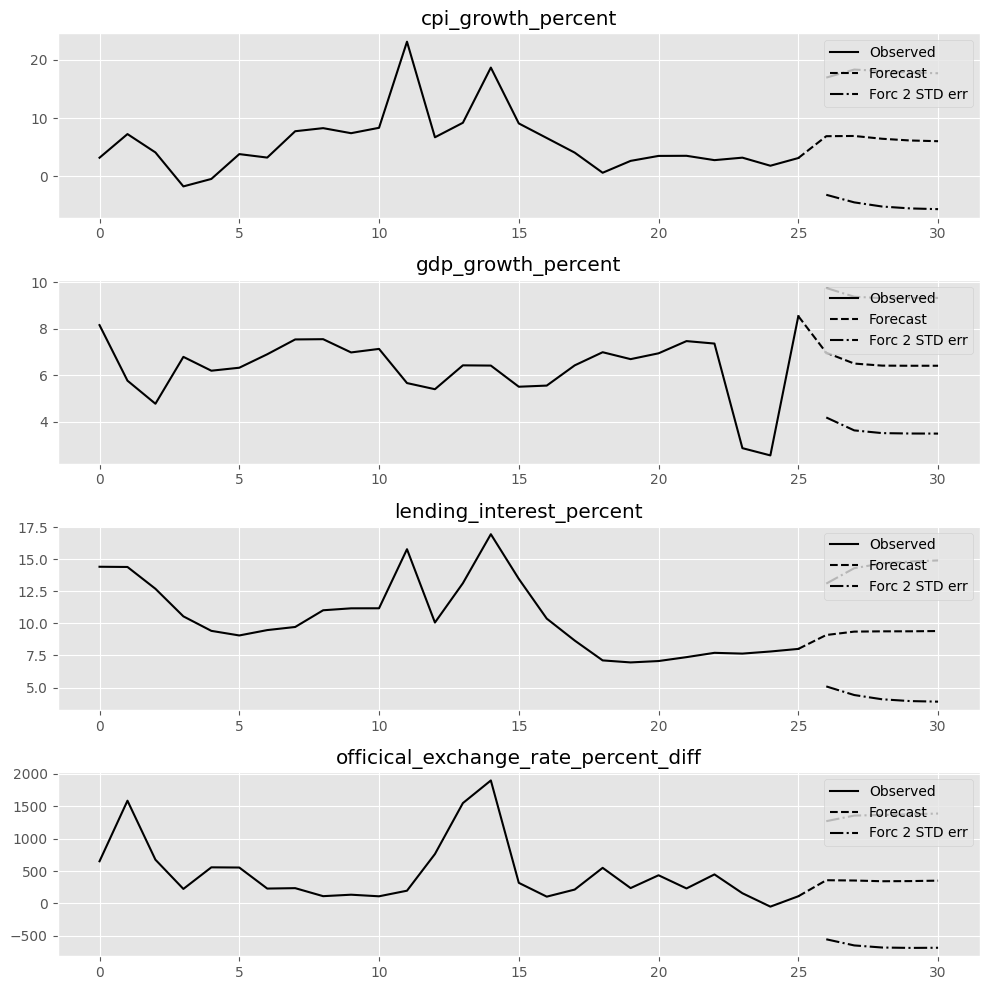

In [ ]:
fig = var_model.plot_forecast(5)
plt.tight_layout()
plt.show()

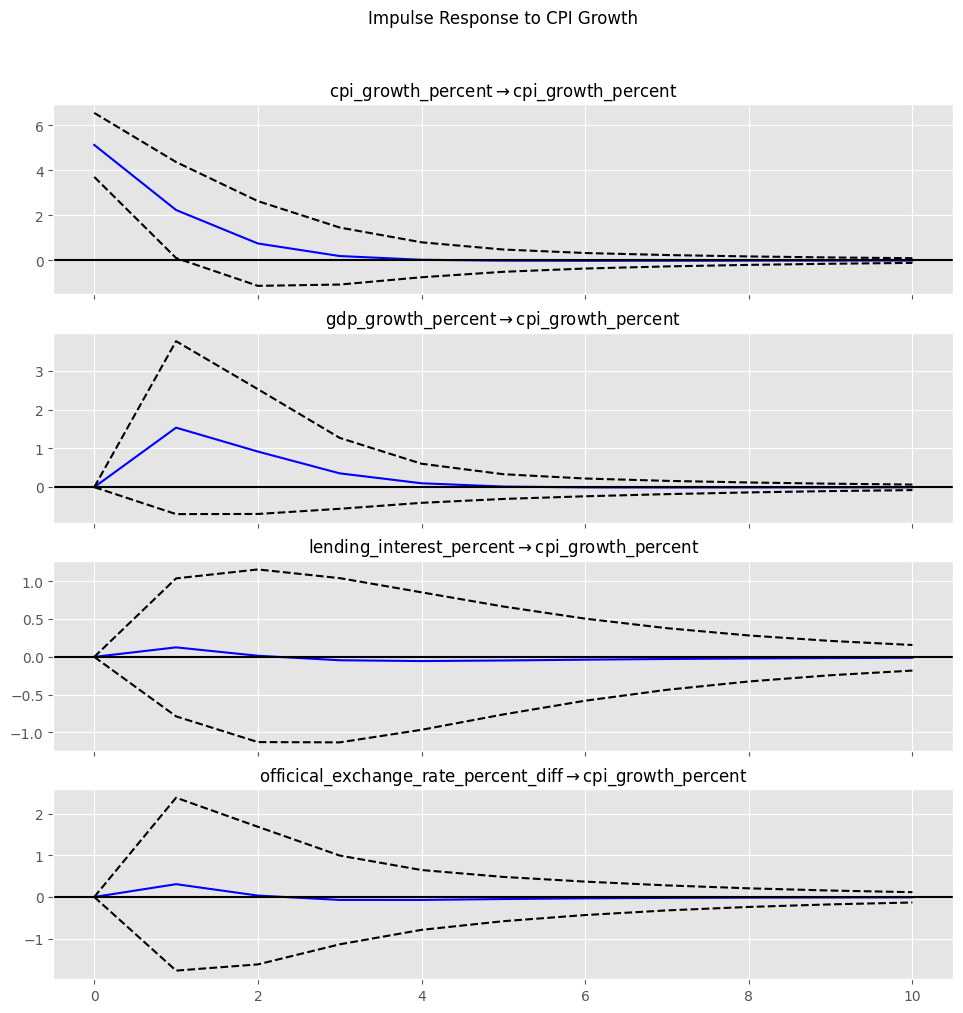

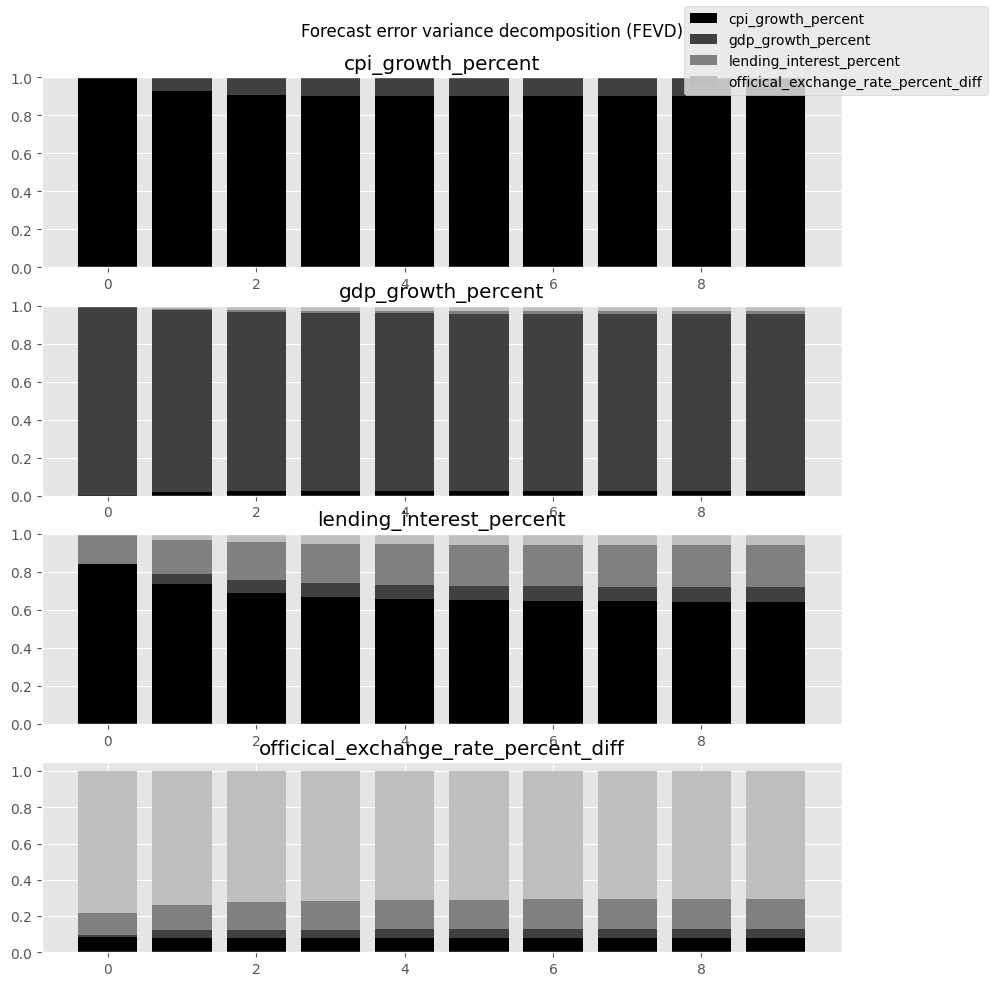

In [ ]:
irf = var_model.irf(10)
irf.plot(orth=True, response='cpi_growth_percent')
plt.suptitle('Impulse Response to CPI Growth', y=1.02)
plt.show()

fevd = var_model.fevd(10)
fevd.plot()
plt.show()

### **Summary Phase 8: Advanced VAR Analysis**
*   **Tâm lý trị vì (Thông qua FEVD):** Phân tích phương sai một lần nữa khẳng định, >90% biến động lạm phát trong 5 năm tới vẫn sẽ chịu sự chi phối của "quán tính tâm lý". Áp lực từ tăng trưởng GDP chỉ đóng vai trò thứ yếu (góp ~9%).
*   **Tỷ giá là tín hiệu dẫn dắt (Thông qua Granger):** Phá vỡ định kiến cho rằng cung tiền và lãi suất quyết định lạm phát ngắn hạn, kiểm định Granger chứng minh **Tỷ giá USD/VND** mới là yếu tố duy nhất có khả năng "báo trước" (dẫn dắt) quỹ đạo của Lạm phát (CPI) tại Việt Nam.
*   **Góc nhìn Kinh tế (Insight):** Lạm phát Việt Nam rất nhạy cảm với các cú sốc bên ngoài, đặc biệt là giá cả nhập khẩu. Nếu Ngân hàng Nhà nước muốn chặn đứng một đợt lạm phát mới trong tương lai, việc đầu tiên cần làm là **"neo giữ" ổn định tỷ giá hối đoái**, thay vì chỉ nôn nóng dùng công cụ lãi suất vốn có độ trễ lớn và tác động không rõ ràng.


### **Model Performance Comparison: VAR vs. ARIMA**

Phần này thực hiện so sánh trực quan sai số của hai mô hình dựa trên các chỉ số **RMSE (Root Mean Squared Error)** và **MAE (Mean Absolute Error)** đối với biến mục tiêu `cpi_growth_percent`.

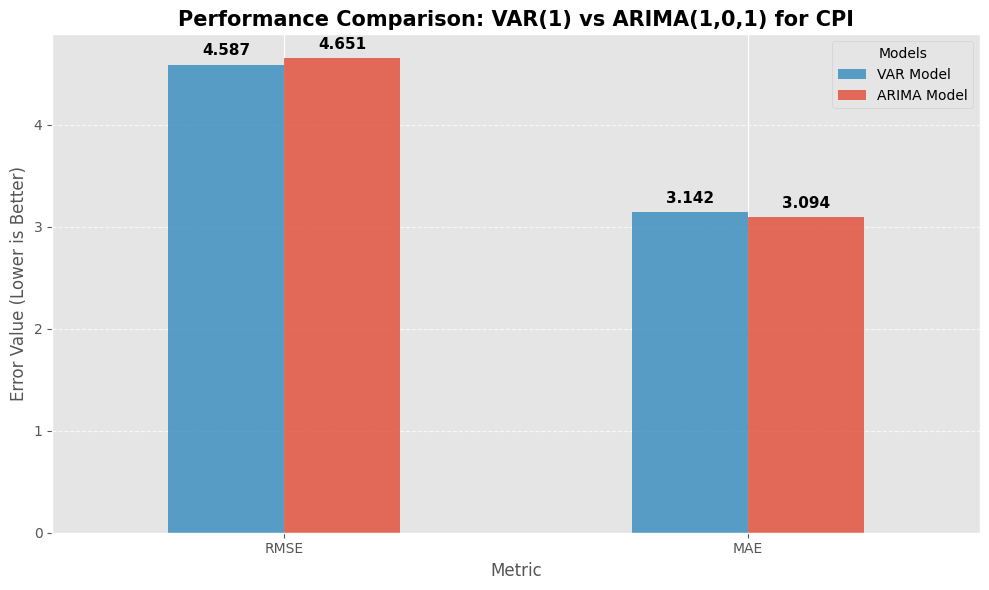

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.arima.model import ARIMA

# 1. Ensure VAR data and model are ready
selected_features = ['cpi_growth_percent', 'gdp_growth_percent', 'lending_interest_percent', 'officical_exchange_rate_percent_diff']
df_var = df_final[selected_features]
model_var = VAR(df_var)
var_model_fitted = model_var.fit(1)

# 2. Calculate metrics for VAR
y_true_var = df_var.values[1:]
y_pred_var = var_model_fitted.fittedvalues.values
cpi_idx = selected_features.index('cpi_growth_percent')

rmse_var = np.sqrt(mean_squared_error(y_true_var[:, cpi_idx], y_pred_var[:, cpi_idx]))
mae_var = mean_absolute_error(y_true_var[:, cpi_idx], y_pred_var[:, cpi_idx])

# 3. Re-fit ARIMA and calculate metrics
cpi_series = df_final['cpi_growth_percent']
arima_model = ARIMA(cpi_series, order=(1, 0, 1))
arima_result_fitted = arima_model.fit()

y_true_arima = cpi_series
y_pred_arima = arima_result_fitted.fittedvalues
rmse_arima = np.sqrt(mean_squared_error(y_true_arima, y_pred_arima))
mae_arima = mean_absolute_error(y_true_arima, y_pred_arima)

# 4. Prepare comparison data
comparison_data = {
    'Metric': ['RMSE', 'MAE'],
    'VAR Model': [rmse_var, mae_var],
    'ARIMA Model': [rmse_arima, mae_arima]
}

df_comp = pd.DataFrame(comparison_data).set_index('Metric')

# 5. Plot comparison
ax = df_comp.plot(kind='bar', figsize=(10, 6), color=['#348ABD', '#E24A33'], alpha=0.8)

plt.title('Performance Comparison: VAR(1) vs ARIMA(1,0,1) for CPI', fontsize=15, fontweight='bold')
plt.ylabel('Error Value (Lower is Better)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 3)), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.legend(title='Models', loc='upper right')
plt.tight_layout()
plt.show()

**Summary Phase 8: Phân tích nguyên nhân & Cú sốc chéo (VAR, Granger, FEVD)**

Nếu quán tính là mồi lửa, thì yếu tố bên ngoài nào là gió thổi bùng lạm phát? Nhóm đưa tất cả các biến số (GDP, Tín dụng, Lãi suất, Tỷ giá) vào thi đấu với nhau để tìm ra thủ phạm thực sự.

- Về tính dẫn dắt (Granger Causality): Phát hiện thú vị nhất là Tỷ giá USD/VND. Dữ liệu chứng minh Tỷ giá có tính 'dẫn dắt' (chỉ báo sớm). Nghĩa là, khi Tỷ giá có biến động bất thường hôm nay, một thời gian sau Lạm phát chắc chắn sẽ phản ứng theo. Trong khi đó, Lãi suất lại không có tác dụng dự báo sớm lạm phát rõ rệt như ta lầm tưởng.
- Về tỷ trọng nguyên nhân (FEVD): Kết quả phân rã cho thấy một bức tranh rất thực tế: Hơn 90% biến động lạm phát của Việt Nam được giải thích bởi chính Quán tính của nó. Đứng thứ hai là áp lực từ Tăng trưởng GDP (đóng góp gần 7-9%). Điều này chứng minh 'Bệnh tự miễn' (tâm lý kỳ vọng giá cả leo thang) mới là kẻ thù số 1 của lạm phát tại Việt Nam.

## **PHASE 9: Economic Interpretation**
> **Vấn đề đặt ra:** Chúng ta đã biết Tỷ giá và GDP có tác động đến Lạm phát. Nhưng theo thời gian (từ 1996 đến nay), liệu "quyền lực" của các yếu tố này có thay đổi không?
>
> Để vẽ chung tất cả các chỉ số lên cùng một bức tranh, nhóm gặp phải một rào cản: Đơn vị tính của chúng khác nhau hoàn toàn (Tỷ giá tính bằng VNĐ, Tăng trưởng GDP tính bằng %, Tín dụng là chỉ số index).
>
> **Giải pháp Tiền xử lý (Data Preprocessing):** Nhóm sử dụng kỹ thuật Chuẩn hóa Min-Max (`MinMaxScaler`) để ép tất cả các biến số về cùng một thang đo tỷ lệ từ 0 đến 1 (0 là mức thấp nhất trong lịch sử, 1 là mức cao nhất). Kỹ thuật này giúp các chỉ số đứng trên "cùng một vạch xuất phát", từ đó ta có thể dễ dàng so sánh cường độ biến động của chúng.


### **Detailed Inflation Structure Analysis**
Phần này đi sâu vào phân tích các áp lực lạm phát thông qua các chỉ số áp lực (Pressure Indicators) và tỷ trọng đóng góp của các nhân tố cấu trúc vào lạm phát tại Việt Nam.

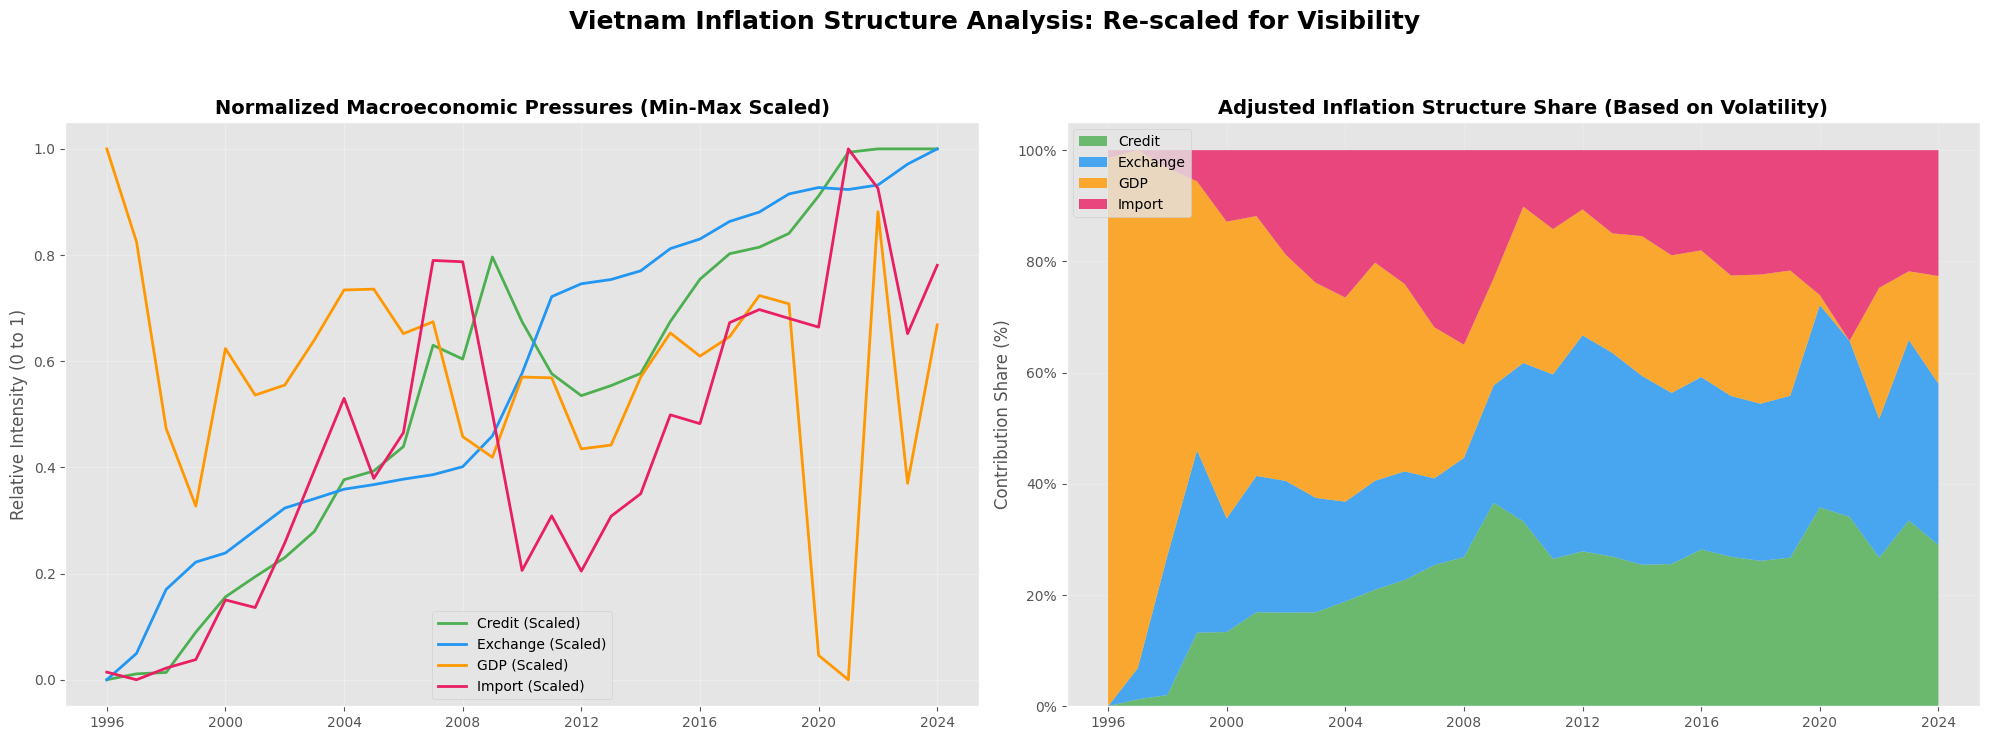

In [ ]:
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_analyze = ['domestic_credit_index', 'officical_exchange_rate_percent', 'gdp_growth_percent', 'import_index']
data_scaled = pd.DataFrame(
    scaler.fit_transform(df[cols_to_analyze].fillna(method='ffill')),
    index=df.index,
    columns=['Credit', 'Exchange', 'GDP', 'Import']
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

C = {'Credit':'#4CAF50', 'Exchange':'#2196F3', 'GDP':'#FF9800', 'Import':'#E91E63'}

# PANEL 1: Normalized Relative Trends
for col in data_scaled.columns:
    axes[0].plot(data_scaled.index, data_scaled[col], label=f'{col} (Scaled)', color=C[col], linewidth=2)

axes[0].set_title('Normalized Macroeconomic Pressures (Min-Max Scaled)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Relative Intensity (0 to 1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PANEL 2: Adjusted Structure Share
share_df_adj = data_scaled.div(data_scaled.sum(axis=1), axis=0) * 100

axes[1].stackplot(
    share_df_adj.index,
    share_df_adj['Credit'],
    share_df_adj['Exchange'],
    share_df_adj['GDP'],
    share_df_adj['Import'],
    labels=share_df_adj.columns,
    colors=[C['Credit'], C['Exchange'], C['GDP'], C['Import']],
    alpha=0.8
)

axes[1].set_title('Adjusted Inflation Structure Share (Based on Volatility)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Contribution Share (%)')
axes[1].legend(loc='upper left')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].grid(True, alpha=0.2)

plt.suptitle('Vietnam Inflation Structure Analysis: Re-scaled for Visibility', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

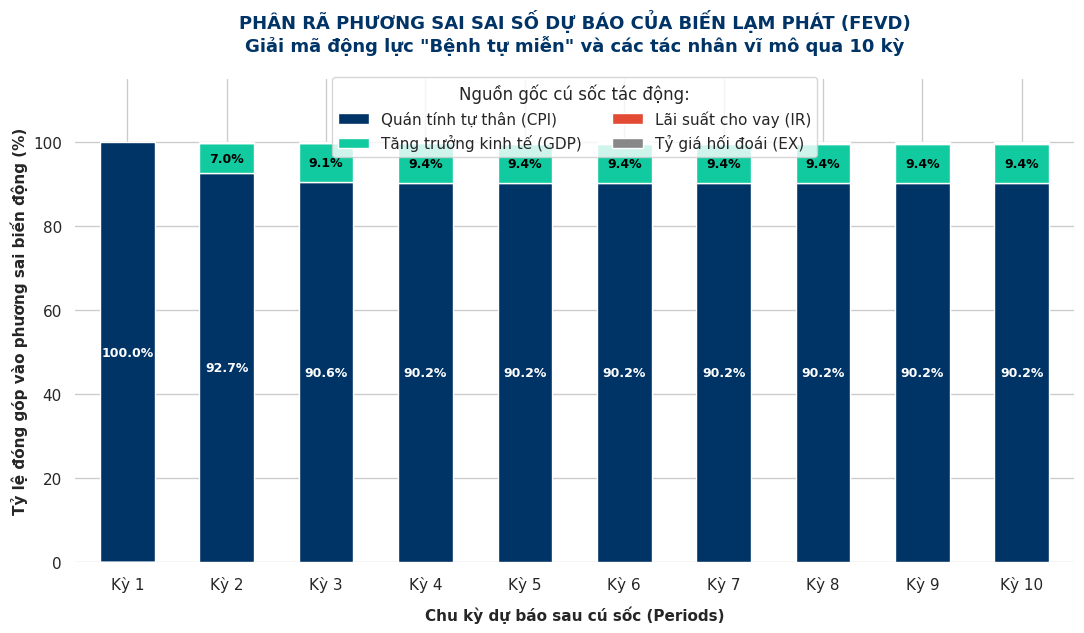

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cấu hình hiển thị đồ thị chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (11, 6.5)

# 2. BÓC TÁCH DỮ LIỆU FEVD TỪ BIẾN THỰC TẾ
fevd = var_model_fitted.fevd(10)

# Xác định vị trí của biến lạm phát mục tiêu (cpi_growth_percent)
cpi_index = var_model_fitted.names.index('cpi_growth_percent')

# Sử dụng thuộc tính .decomp thay vì .values của đối tượng FEVD
# Cấu trúc của fevd.decomp là ma trận 3 chiều: (Biến mục tiêu, Kỳ, Biến cú sốc)
cpi_fevd_matrix = fevd.decomp[cpi_index, :, :] * 100

# 3. CHUYỂN ĐỔI THÀNH DATAFRAME ĐỂ ĐỒNG BỘ TRỤC X THEO KỲ (PERIODS)
periods = [f'Kỳ {i}' for i in range(1, 11)]
df_fevd = pd.DataFrame(cpi_fevd_matrix, index=periods, columns=var_model_fitted.names)

rename_dict = {
    'cpi_growth_percent': 'Quán tính tự thân (CPI)',
    'gdp_growth_percent': 'Tăng trưởng kinh tế (GDP)',
    'lending_interest_percent': 'Lãi suất cho vay (IR)',
    'officical_exchange_rate_percent_diff': 'Tỷ giá hối đoái (EX)'
}
df_fevd = df_fevd.rename(columns=rename_dict)

# 4. TIẾN HÀNH VẼ BIỂU ĐỒ CỘT CHỒNG (STACKED BAR CHỒNG ĐỦ 100%)
fig, ax = plt.subplots()

df_fevd.plot(kind='bar', stacked=True, ax=ax,
             color=['#003366', '#11caa0', '#e24a33', '#888888'], width=0.55)

# 5. BỔ SUNG SỐ LIỆU PHẦN TRĂM TRỰC TIẾP LÊN THÂN CỘT
for i in range(len(periods)):
    cpi_val = df_fevd.loc[periods[i], 'Quán tính tự thân (CPI)']
    ax.text(i, cpi_val / 2, f"{cpi_val:.1f}%",
            ha='center', va='center', color='white', fontweight='bold', fontsize=9)

    gdp_val = df_fevd.loc[periods[i], 'Tăng trưởng kinh tế (GDP)']
    if gdp_val > 3.0:
        ax.text(i, cpi_val + (gdp_val / 2), f"{gdp_val:.1f}%",
                ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# 6. ĐỊNH DẠNG CHI TIẾT TRỤC TỌA ĐỘ VÀ TIÊU ĐỀ
ax.set_title('BỆNH TỰ MIỄN: >90% LẠM PHÁT VIỆT NAM ĐẾN TỪ QUÁN TÍNH TRONG QUÁ KHỨ\nTác động của Tăng trưởng GDP chỉ đóng vai trò thứ yếu (~9%), trong khi Tỷ giá và Lãi suất có tác động trực tiếp không đáng kể.',
             fontsize=13, fontweight='bold', color='#003366', pad=20)
ax.set_xlabel('Chu kỳ dự báo sau cú sốc (Periods)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Tỷ lệ đóng góp vào phương sai biến động (%)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
plt.xticks(rotation=0)

ax.legend(title='Nguồn gốc cú sốc tác động:', loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig('bieudo_fevd_stacked_chuan.png', dpi=300)
plt.show()

**Đọc vị bức tranh vĩ mô Việt Nam (1996 - 2024):**
> Hãy gác lại các thuật toán phức tạp, chúng ta cùng nhìn vào biểu đồ để thấy nền kinh tế đang kể câu chuyện gì:
>
> *   **Biểu đồ bên trái (Đường xu hướng - Relative Trends):** Cho thấy nhịp đập của nền kinh tế. Có thể thấy sự đồng pha (đi lên cùng nhau) rất rõ rệt giữa Tín dụng (Credit) và GDP vào những năm trước 2010. Đây là thời kỳ bơm tiền mạnh tay để kích cầu. Tuy nhiên, ở giai đoạn COVID-19 (2020-2022), sự đồng pha này bị gãy nhịp.
> *   **Biểu đồ bên phải (Miền xếp chồng - Structure Share):** Đây là bức tranh "chuyển giao quyền lực". Hãy nhìn vào sự thay đổi độ dày của các dải màu theo thời gian:
>     *   **Trước 2010:** Dải màu xanh lá (Tín dụng) và màu cam (GDP) rất dày. Áp lực lạm phát thời kỳ này là **Lạm phát do cầu kéo** (tiền nhiều, tăng trưởng nóng).
>     *   **Sau 2010 đến nay:** Dải màu xanh dương (Tỷ giá USD/VND) và màu hồng (Giá trị nhập khẩu) dần phình to và chiếm sóng. Điều này chứng tỏ áp lực lạm phát đã dịch chuyển thành **Lạm phát chi phí đẩy** (hàng hóa nhập khẩu đắt đỏ do mất giá tiền tệ).

So với bối cảnh siêu lạm phát của Mỹ và Châu Âu giai đoạn hậu Covid-19 (2022-2023) lên tới 8-9%, đỉnh lạm phát của Việt Nam giai đoạn này được neo giữ cực kỳ thành công dưới 5%. Điều này chứng tỏ "Căn bệnh lạm phát" tại Việt Nam chủ yếu mang tính chu kỳ nội tại (như năm 2008) hơn là bị cuốn hoàn toàn theo chu kỳ toàn cầu hiện tại.



**Summary Phase 9: Diễn giải Kinh tế (Economic Interpretation)**

*   **Sự dịch chuyển cơ cấu:** Trực quan hóa dữ liệu khẳng định trọng tâm áp lực vĩ mô tại Việt Nam đã thay đổi. Nền kinh tế không còn đối mặt với lạm phát do "bơm tiền ồ ạt" (Tín dụng) như thập kỷ trước, mà đang nhạy cảm và dễ tổn thương nhất trước các biến động toàn cầu thông qua kênh **Tỷ giá và Nhập khẩu**.
*   **Giá trị của Data Storytelling:** Việc chuẩn hóa dữ liệu và dùng biểu đồ miền xếp chồng (Stacked Area) đã giúp chuyển hóa các bảng số liệu kinh tế lượng phức tạp thành một câu chuyện trực quan, nơi bất kỳ ai (dù không chuyên về kinh tế hay IT) cũng có thể thấy rõ dòng chảy và sự dịch chuyển cấu trúc của nền kinh tế Việt Nam.
*   **Lời giải đáp cuối cùng:** Lạm phát tại Việt Nam là một bức tranh đa lớp. Lớp nền tảng vững chắc nhất là **Quán tính tâm lý** (lạm phát tự sinh ra lạm phát). Còn lớp bề mặt, tác nhân bóp cò châm ngòi cho các đợt bùng phát hiện nay chính là **Tỷ giá hối đoái**. Do đó, điều hành tỷ giá ổn định và quản trị kỳ vọng của người dân là chìa khóa then chốt để khóa chặt van lạm phát trong thập kỷ tới.


### **Summary of Findings**
- **VAR Model:** Cho thấy mối quan hệ tương hỗ mạnh giữa tỷ giá và lạm phát.
- **ARIMA Model:** Dự báo lạm phát đơn biến có xu hướng hội tụ về mức trung bình dài hạn.
- **FEVD:** Xác định tỷ trọng đóng góp của các cú sốc kinh tế đối với biến động GDP.

## **PHASE 10: Policy Recommendation**

- **Kiểm soát lạm phát:** Cần chú trọng ổn định tỷ giá hối đoái vì đây là biến số tác động mạnh nhất đến CPI.
- **Hỗ trợ tăng trưởng:** Duy trì lãi suất cho vay ở mức ổn định để kích thích tín dụng nội địa.

### **Economic Interpretation of Inflation Structure**

Dựa trên kết quả phân tích sau khi đã chuẩn hóa dữ liệu (Re-scaled), chúng ta có thể rút ra các nhận định quan trọng về cấu trúc lạm phát tại Việt Nam giai đoạn 1996–2024:

1. **Tính Chu kỳ và Áp lực từ Cầu (Demand-Pull):**
   - Biểu đồ **Normalized Pressures** cho thấy sự đồng pha nhất định giữa `GDP Growth` và `Credit`. Trong các giai đoạn kinh tế tăng trưởng nóng (như trước 2008), áp lực từ tín dụng và tăng trưởng GDP đẩy cường độ lạm phát lên mức cao (vùng đỉnh của các đường màu xanh lá và cam).

2. **Sự thống trị của Tỷ giá và Chi phí đẩy (Cost-Push):**
   - Sau khi chuẩn hóa, `Exchange Rate` (màu xanh dương) không còn 'nuốt chửng' các biến khác về mặt con số tuyệt đối, nhưng vẫn cho thấy là nhân tố có độ biến động duy trì ở mức cao nhất.
   - Điều này xác nhận rằng lạm phát tại Việt Nam có đặc thù chịu ảnh hưởng lớn từ biến động tỷ giá và giá hàng hóa nhập khẩu (Import Index).

3. **Sự dịch chuyển cấu trúc (Adjusted Share Analysis):**
   - Khác với biểu đồ ban đầu chỉ thấy màu xanh, biểu đồ **Adjusted Share** cho thấy sự phân bổ thực tế của các áp lực:
     - **Giai đoạn trước 2011:** Tín dụng và GDP đóng góp tỷ trọng rất lớn vào áp lực tổng thể, phản ánh mô hình tăng trưởng dựa trên thâm dụng vốn.
     - **Giai đoạn sau 2011:** Tỷ trọng của Tỷ giá và Nhập khẩu có xu hướng ổn định hơn nhờ các chính sách điều hành linh hoạt của Ngân hàng Nhà nước.

4. **Kết luận về Chính sách:**
   - Lạm phát không chỉ là vấn đề tiền tệ (Tín dụng) mà còn là vấn đề cấu trúc (Tỷ giá & Nhập khẩu). Do đó, việc kiểm soát lạm phát mục tiêu đòi hỏi sự phối hợp chặt chẽ giữa chính sách tiền tệ (lãi suất, cung tiền) và chính sách quản lý tỷ giá để giảm thiểu các cú sốc từ bên ngoài.

**PHASE 10: TỔNG KẾT VÀ ĐỀ XUẤT CHÍNH SÁCH VĨ MÔ (POLICY RECOMMENDATIONS)**
> Xuyên suốt đồ án, chúng ta đã đi tìm câu trả lời cho vấn đề: *"Lạm phát tại Việt Nam là do 'căn bệnh tự miễn' (quán tính tâm lý) hay do 'tác nhân bên ngoài' (Tỷ giá, Tín dụng, Tăng trưởng)?"*
>
> Bằng các kỹ thuật Phân tích dữ liệu, Đánh giá sai số và Trực quan hóa, dữ liệu đã đưa ra phán quyết cuối cùng: Lạm phát Việt Nam là tổng hòa của cả hai. Nó được **châm ngòi** bởi các cú sốc bên ngoài (đặc biệt là Tỷ giá nhập khẩu), nhưng sau đó lại tự khuếch đại và **kéo dài dai dẳng** bởi Quán tính tâm lý của thị trường.

**1. Đề xuất chính sách dựa trên Dữ liệu (Data-Driven Recommendations)**
Từ những góc nhìn sâu sắc (insights) đã được minh chứng bằng mô hình toán học và biểu đồ, nhóm đưa ra 3 đề xuất cốt lõi cho việc điều hành vĩ mô:

*   **Lấy Tỷ giá làm "Mỏ neo" chống lạm phát:** Kiểm định Granger Causality đã chứng minh Tỷ giá là chỉ báo dẫn dắt lạm phát. Do đó, thay vì nôn nóng dùng công cụ Lãi suất (vốn có độ trễ lớn), cơ quan điều hành cần ưu tiên linh hoạt sử dụng dự trữ ngoại hối để bình ổn Tỷ giá USD/VND, chặn đứng nguy cơ "nhập khẩu lạm phát" từ sớm.
*   **Quản trị "Tâm lý kỳ vọng" là ưu tiên hàng đầu:** Vì hơn 90% biến động lạm phát (theo bảng phân rã FEVD) đến từ quán tính quá khứ, việc dập tắt tâm lý "té nước theo mưa" là cực kỳ quan trọng. Nhà nước cần giãn lộ trình tăng giá các mặt hàng thiết yếu (điện, nước, y tế) và minh bạch thông tin để tránh gây sốc tâm lý cho thị trường.
*   **Bơm tín dụng có chọn lọc:** Biểu đồ cơ cấu lạm phát cho thấy áp lực từ Tín dụng đã giảm dần so với thập kỷ trước. Do đó, việc duy trì dòng tiền tín dụng chảy đúng vào khu vực sản xuất thực thay vì đầu cơ tài sản sẽ giúp nền kinh tế tăng trưởng mà không kích hoạt lại "Lạm phát do cầu kéo".

**2. Hướng phát triển của mô hình:**
Đồ án đã xây dựng thành công một quy trình phân tích (pipeline) từ dữ liệu thô đến hệ thống mô hình VAR/ARIMA. Để trả lời sâu hơn các câu hỏi kinh tế phức tạp, nhóm định hướng các bước phát triển tiếp theo:

*   **Thu thập dữ liệu tần suất cao (High-Frequency Data):** Chuyển từ dữ liệu theo Năm (Annual) sang dữ liệu theo Tháng (Monthly) hoặc Quý (Quarterly) để bắt nhịp nhanh hơn với các biến động ngắn hạn.
*   **Lượng hóa Tâm lý bằng Xử lý Ngôn ngữ Tự nhiên (NLP):** Vì tâm lý đóng vai trò >90% trong lạm phát, việc thu thập dữ liệu báo chí, mạng xã hội và dùng Phân tích cảm xúc (Sentiment Analysis) để tạo ra một "Chỉ số tâm lý thị trường" đưa vào mô hình sẽ là một bước đột phá.
*   **Ứng dụng Học Sâu (Deep Learning):** Sử dụng các mạng nơ-ron chuyên dụng cho chuỗi thời gian như LSTM hoặc RNN để tự động nhận diện các điểm nứt gãy kinh tế (như đại dịch Covid-19 hay khủng hoảng tài chính toàn cầu) thay vì chỉ dùng các mô hình tuyến tính truyền thống.